In [1]:
# Cell 1: Import all required libraries and dependencies
%load_ext autoreload
%autoreload 2
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
import torchdiffeq

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

Generating trajectories...
10% of trajectories generated (10/100)
20% of trajectories generated (20/100)
30% of trajectories generated (30/100)
40% of trajectories generated (40/100)
50% of trajectories generated (50/100)
60% of trajectories generated (60/100)
70% of trajectories generated (70/100)
80% of trajectories generated (80/100)
90% of trajectories generated (90/100)
100% of trajectories generated (100/100)
Trajectories generation completed and saved to Car_trajectories_dataset.npy


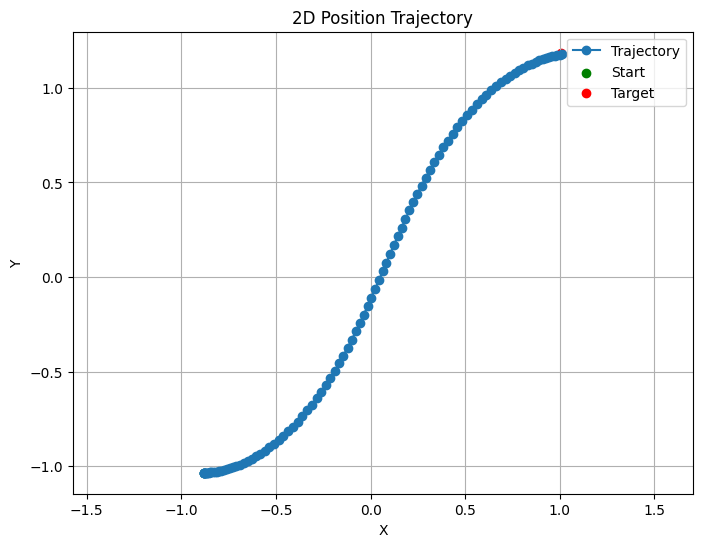

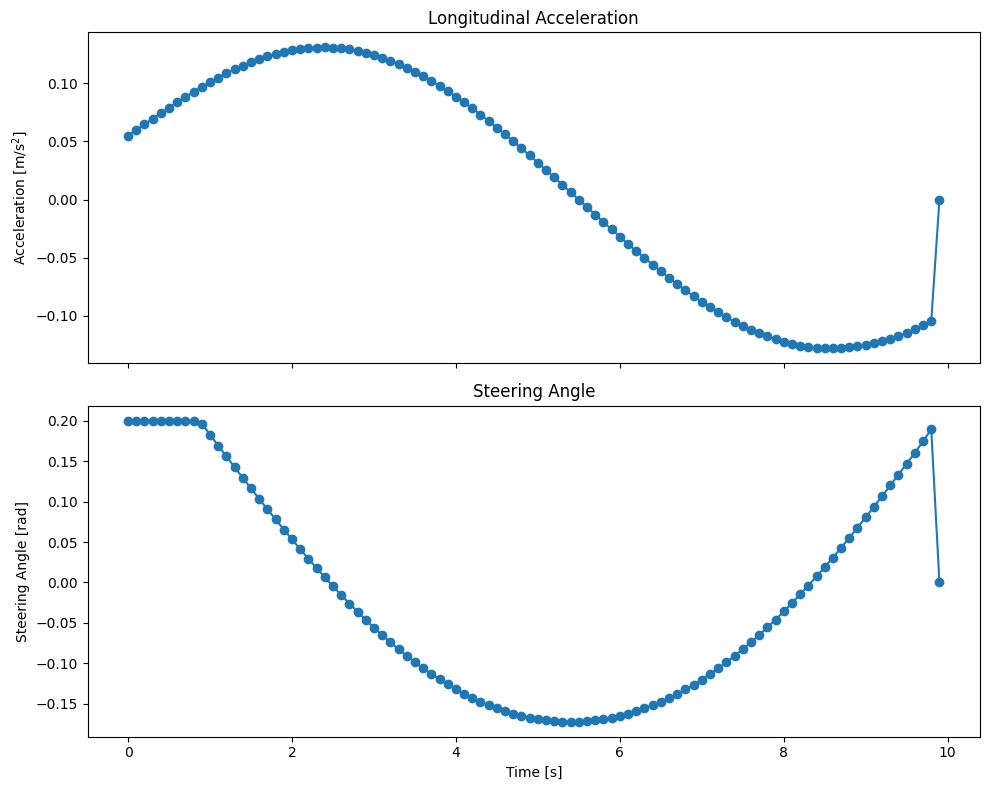

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

# ----------------------------
# Parameters
# ----------------------------
state_steps = 100                  # total number of states (includes initial state)
control_steps = state_steps - 1    # number of control steps to simulate state updates
dt = 0.1                           # time step (seconds)
a_max = 0.25                       # maximum longitudinal acceleration [m/s^2]
delta_max = 0.2                    # maximum steering angle [rad]

# Weights in the cost function
w_p = 10.0      # weight for terminal position error
w_theta = 1.0   # weight for terminal heading error
w_v = 1.0       # weight for terminal speed and yaw rate error (both desired 0)
lambda_reg = 0.1  # regularization for control effort

# ----------------------------
# Configuration for data generation
# ----------------------------
num_trajectories = 100
save_filename = 'Car_trajectories_dataset.npy'
LOAD_SAVED_DATA = False 
progress_step = max(num_trajectories // 10, 1)

# ----------------------------
# Utility Functions
# ----------------------------
def sample_point_in_circle(center, radius):
    """
    Sample a random point inside a circle with specified center and radius.
    """
    angle = np.random.uniform(0, 2*np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def simulate_vehicle(x0, u_seq, dt=0.1):
    """
    Simulate the vehicle dynamics.
    
    x0: initial state [x, y, theta, v, r]
    u_seq: control sequence of shape (control_steps, 2), for each step: [a, delta]
    
    The vehicle dynamics (using Euler discretization):
      x_{k+1} = x_k + dt * v_k * cos(theta_k)
      y_{k+1} = y_k + dt * v_k * sin(theta_k)
      theta_{k+1} = theta_k + dt * r_k
      v_{k+1} = v_k + dt * a_k
      r_{k+1} = r_k + dt * delta_k
      
    Returns:
      states: NumPy array of shape (state_steps, 5)
    """
    states = np.zeros((state_steps, 5))
    states[0] = x0
    # For k=0,...,control_steps-1, apply optimized control
    for k in range(control_steps):
        x, y, theta, v, r = states[k]
        a, delta = u_seq[k]
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
    return states


def cost_function(u_flat, x0, target, dt, control_steps, 
                  lambda_reg=lambda_reg, w_p=w_p, w_theta=w_theta, w_v=w_v):
    """
    Cost function for optimal control.
    
    The cost includes:
      1. Terminal state error: 
         - Position error: ||[x_N, y_N] - target||^2 
         - Heading error: (theta_N - 0)^2 (target heading fixed at 0 rad)
         - Speed error: (v_N - 0)^2
         - Yaw rate error: (r_N - 0)^2
      2. Control effort penalty: lambda_reg * sum(a_k^2 + delta_k^2) over all steps
    """
    u_seq = u_flat.reshape((control_steps, 2))
    states = simulate_vehicle(x0, u_seq, dt)
    final_state = states[-1]
    pos_error = np.linalg.norm(final_state[:2] - target)**2
    theta_error = (final_state[2] - 0)**2   # desired heading 0 rad
    v_error = (final_state[3] - 0)**2         # desired speed 0
    r_error = (final_state[4] - 0)**2         # desired yaw rate 0
    control_penalty = lambda_reg * np.sum(u_seq**2)
    J = w_p * pos_error + w_theta * theta_error + w_v * (v_error + r_error) + control_penalty
    return J

# ----------------------------
# Optimization Bounds and Setup
# ----------------------------
# Since we optimize for control_steps steps, total decision variables: control_steps * 2
bounds = []
for _ in range(control_steps):
    bounds.append((-a_max, a_max))       # for a_k
    bounds.append((-delta_max, delta_max)) # for delta_k

#----------------------------
#Data Generation or Loading
#----------------------------

if LOAD_SAVED_DATA and os.path.exists(save_filename):
    print("Loading trajectories dataset from file:", save_filename)
    trajectories = np.load(save_filename, allow_pickle=True)
else:
    trajectories = []
    print("Generating trajectories...")
    for i in range(num_trajectories):
        # Sample start and target positions from defined circles:
        start = sample_point_in_circle(np.array([-1, -1]), 0.2)
        target = sample_point_in_circle(np.array([1, 1]), 0.2)
    
        # Fixed initial state: heading = 0, speed = 0, yaw rate = 0.
        x0 = np.array([start[0], start[1], 0.0, 0.0, 0.0])
    
        # Initial guess for control sequence: zeros (length = control_steps * 2)
        u0 = np.zeros(control_steps * 2)
    
        # Solve the optimal control problem using SciPy's SLSQP
        res = minimize(cost_function, u0, args=(x0, target, dt, control_steps),
                       method='SLSQP', bounds=bounds,
                       options={'maxiter': 1000, 'ftol': 1e-6, 'disp': False})
    
        # Reshape optimized control sequence to (control_steps, 2)
        u_opt = res.x.reshape((control_steps, 2))
        # Pad the final control with [0,0] so that controls have shape (state_steps,2)
        controls_padded = np.vstack([u_opt, [0, 0]])
    
        states = simulate_vehicle(x0, u_opt, dt)
    
        trajectories.append({'states': states, 'controls': controls_padded, 
                             'start': start, 'target': target})

        if (i + 1) % progress_step == 0:
            percent_done = ((i + 1) / num_trajectories) * 100
            print(f"{percent_done:.0f}% of trajectories generated ({i + 1}/{num_trajectories})")
            np.save(save_filename, trajectories, allow_pickle=True)
    np.save(save_filename, trajectories, allow_pickle=True)
    print("Trajectories generation completed and saved to", save_filename)

# ----------------------------
# Visualization
# ----------------------------
idx = np.random.choice(len(trajectories))
traj = trajectories[idx]
states = traj['states']
u_seq = traj['controls']

time_states = np.linspace(0, (state_steps-1)*dt, state_steps)
time_controls = np.linspace(0, (state_steps-1)*dt, state_steps)

plt.figure(figsize=(8,6))
plt.plot(states[:,0], states[:,1], marker='o', linestyle='-', label='Trajectory')
plt.scatter(traj['start'][0], traj['start'][1], color='green', label='Start')
plt.scatter(traj['target'][0], traj['target'][1], color='red', label='Target')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Position Trajectory')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(10,8), sharex=True)
axs[0].plot(time_controls, u_seq[:,0], marker='o', linestyle='-')
axs[0].set_ylabel('Acceleration [m/s$^2$]')
axs[0].set_title('Longitudinal Acceleration')
axs[1].plot(time_controls, u_seq[:,1], marker='o', linestyle='-')
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Steering Angle [rad]')
axs[1].set_title('Steering Angle')
plt.tight_layout()
plt.show()


In [5]:
# Load from store
# ==== Cell 0: Load saved trajectories ====
import os
import numpy as np

filename = 'Car_trajectories_dataset.npy'
assert os.path.exists(filename), f"{filename} not found!"

trajectories = np.load(filename, allow_pickle=True)

print(f"Loaded {len(trajectories)} trajectories from '{filename}'")
print("Example traj keys:", trajectories[0].keys())
print("states.shape =", trajectories[0]['states'].shape,
      "controls.shape =", trajectories[0]['controls'].shape)
from torch.utils.data import Dataset, DataLoader
import torch
batch_size=64
traj_arr = np.stack([
    np.concatenate([traj['states'][:, :3].T,
                    traj['controls'][:100].T], axis=0)
    for traj in trajectories
], axis=0).astype(np.float32)  # shape (N,5,100)

class TrajectoryDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx])  # FloatTensor

train_loader = DataLoader(
    TrajectoryDataset(traj_arr),
    batch_size=batch_size, shuffle=True, num_workers=0
)

print("Train loader ready, #batches =", len(train_loader))


Loaded 100 trajectories from 'Car_trajectories_dataset.npy'
Example traj keys: dict_keys(['states', 'controls', 'start', 'target'])
states.shape = (100, 5) controls.shape = (100, 2)
Train loader ready, #batches = 2


In [7]:
# ==== 用 Bezier 曲线生成训练轨迹 ====
import numpy as np
import math

dt = 0.1           # 和后面 simulate_vehicle 里的 dt 保持一致
state_steps = 100  # 每条轨迹 100 个点

obstacle_center = np.array([0.0, 0.0])  # 障碍物圆心
obstacle_r      = 0.25                  # 障碍物半径（和后面 CBF 里 r 对齐）

def sample_cubic_bezier(P0, P1, P2, P3, T=100):
    """
    给定 4 个控制点 P0..P3 (2D)，生成一条二维 Bezier 曲线，长度 T。
    返回 shape = (T, 2)
    """
    t = np.linspace(0.0, 1.0, T).reshape(-1, 1)  # (T,1)
    B = ((1 - t)**3) * P0 \
        + 3 * ((1 - t)**2) * t * P1 \
        + 3 * (1 - t) * (t**2) * P2 \
        + (t**3) * P3
    return B  # (T,2)

def generate_bezier_dataset(num_traj=300, T=100, dt=0.1,
                            obstacle_center=np.array([0.0, 0.0]),
                            obstacle_r=0.25, seed=0):
    """
    生成若干条绕着障碍物走的 Bezier 轨迹。
    每条轨迹：
        states  : (T,5) = [x, y, θ, v, r]
        controls: (T,2) = [a, δ]
    其中 a 类似线加速度，δ 简单用 yaw rate r 来代替（为了适配原代码结构）。
    """
    rng = np.random.RandomState(seed)
    trajs = []

    for i in range(num_traj):
        # 1. 随机生成起点终点：在障碍物外一圈
        R = obstacle_r * 3.0 + rng.rand() * 0.5   # 半径比障碍物大很多
        ang0 = rng.rand() * 2 * np.pi
        # 让终点在角度上绕一圈右边 / 左边
        ang1 = ang0 + (rng.rand() * 0.5 + 0.5) * np.pi * np.sign(rng.randn())

        P0 = obstacle_center + R * np.array([math.cos(ang0), math.sin(ang0)])
        P3 = obstacle_center + R * np.array([math.cos(ang1), math.sin(ang1)])

        # 2. 两个中间控制点：绕着障碍物一边 “拱” 过去
        mid_angle  = (ang0 + ang1) / 2.0
        mid_radius = obstacle_r * 1.5
        mid = obstacle_center + mid_radius * np.array([math.cos(mid_angle),
                                                       math.sin(mid_angle)])
        # 切向方向（保证是绕着走而不是直接穿过）
        tang   = np.array([-math.sin(mid_angle), math.cos(mid_angle)])
        offset = tang * obstacle_r * 1.5 * np.sign(rng.randn())

        P1 = (P0 + mid) / 2.0 + offset
        P2 = (P3 + mid) / 2.0 + offset

        # 3. 生成 Bezier 位置曲线
        pos = sample_cubic_bezier(P0, P1, P2, P3, T)  # (T,2)  [x,y]

        # 4. 用差分近似速度、航向角、角速度、加速度
        vel   = np.vstack([np.diff(pos, axis=0),
                           np.zeros((1, 2))]) / dt        # (T,2)
        speed = np.linalg.norm(vel, axis=1, keepdims=True)  # (T,1)
        eps   = 1e-3
        speed_clipped = np.clip(speed, eps, None)

        theta = np.arctan2(vel[:, 1], vel[:, 0]).reshape(-1, 1)  # (T,1)
        dtheta = np.vstack([np.diff(theta, axis=0),
                            np.zeros((1, 1))]) / dt              # (T,1)

        a = np.vstack([np.diff(speed_clipped, axis=0),
                       np.zeros((1, 1))]) / dt                  # (T,1)
        r = dtheta                                              # (T,1)

        # 5. 拼成 states / controls，格式跟原小车数据保持一致
        states   = np.concatenate([pos, theta, speed_clipped, r], axis=1)  # (T,5)
        controls = np.concatenate([a, r], axis=1)                          # (T,2)

        trajs.append({
            'states': states,
            'controls': controls
        })

    return trajs

# ===== 生成 Bezier 轨迹数据集 =====
trajectories = generate_bezier_dataset(
    num_traj=300,
    T=state_steps,
    dt=dt,
    obstacle_center=obstacle_center,
    obstacle_r=obstacle_r,
    seed=0
)

print(f"✅ Generated {len(trajectories)} Bezier trajectories")
print("Example keys       :", trajectories[0].keys())
print("states.shape  =", trajectories[0]['states'].shape)
print("controls.shape=", trajectories[0]['controls'].shape)


✅ Generated 300 Bezier trajectories
Example keys       : dict_keys(['states', 'controls'])
states.shape  = (100, 5)
controls.shape= (100, 2)


Trajectory 0 removed: max position error = 2.4579 m


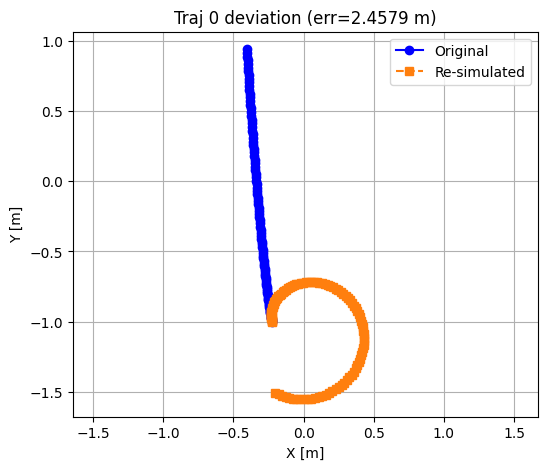

Trajectory 1 removed: max position error = 2.2691 m


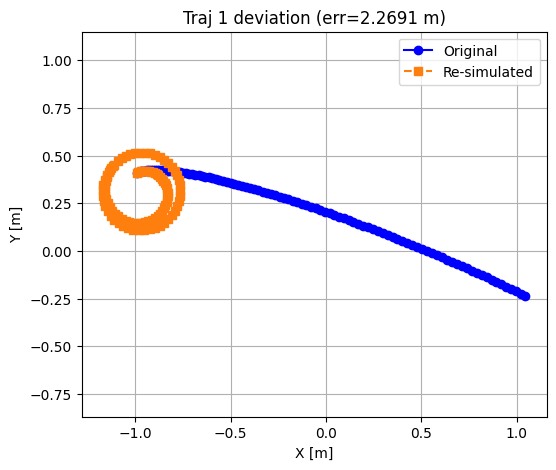

Trajectory 2 removed: max position error = 0.0179 m


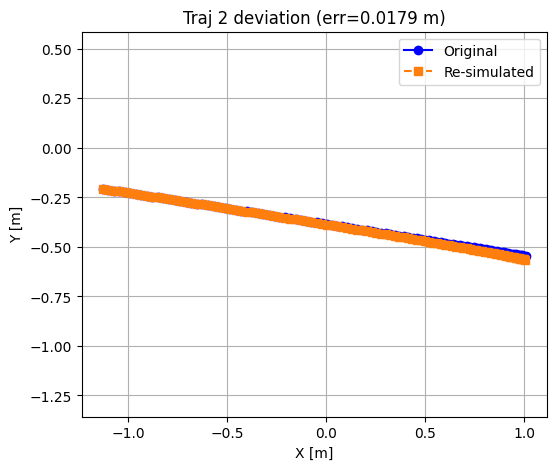

Trajectory 3 removed: max position error = 2.1851 m


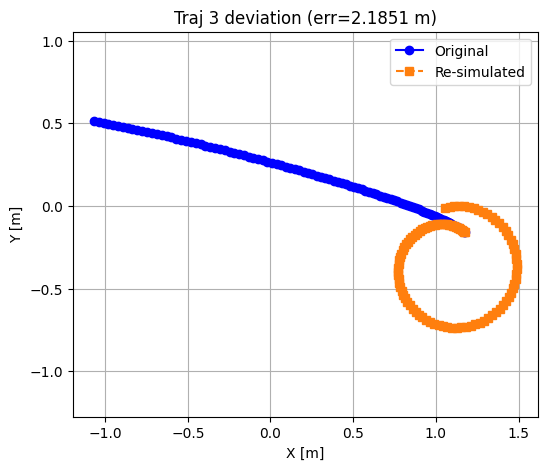

Trajectory 4 removed: max position error = 0.1747 m


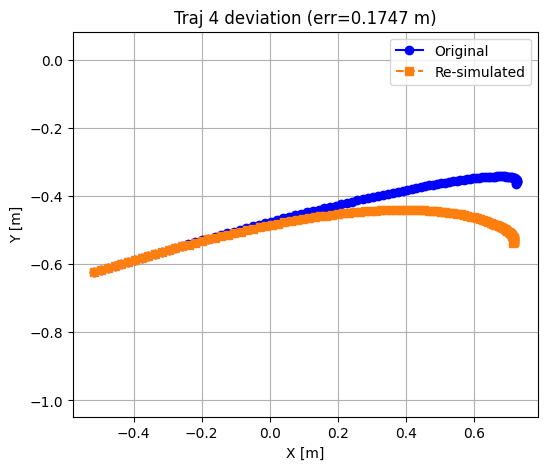

Trajectory 5 removed: max position error = 1.7260 m


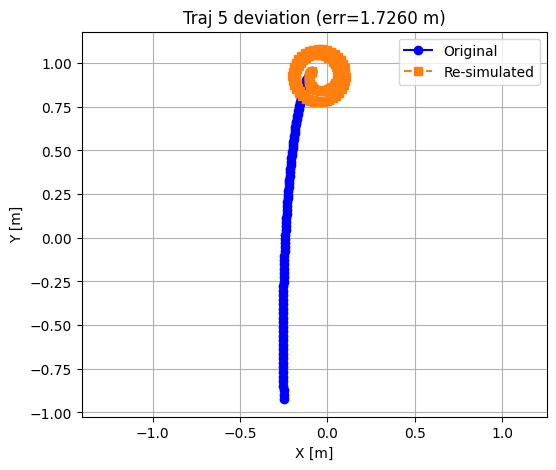

Trajectory 6 removed: max position error = 0.2445 m


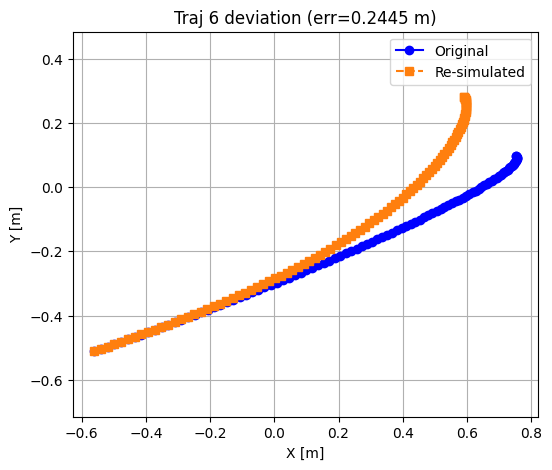

Trajectory 7 removed: max position error = 1.7680 m


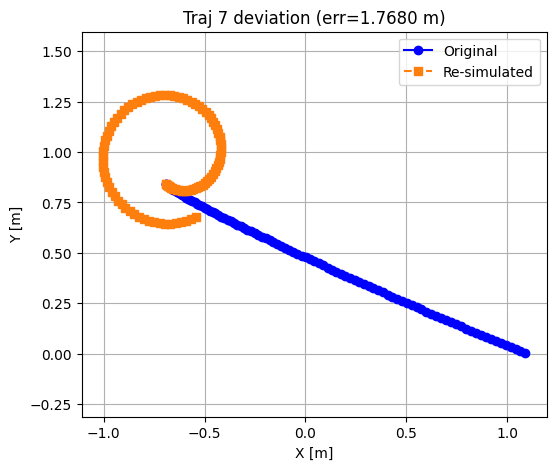

Trajectory 8 removed: max position error = 0.5286 m


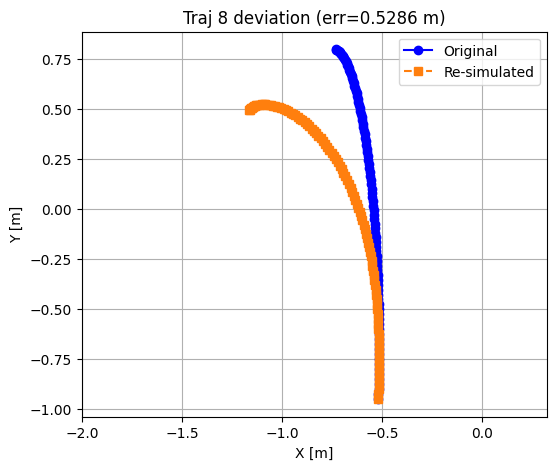

Trajectory 9 removed: max position error = 0.0477 m


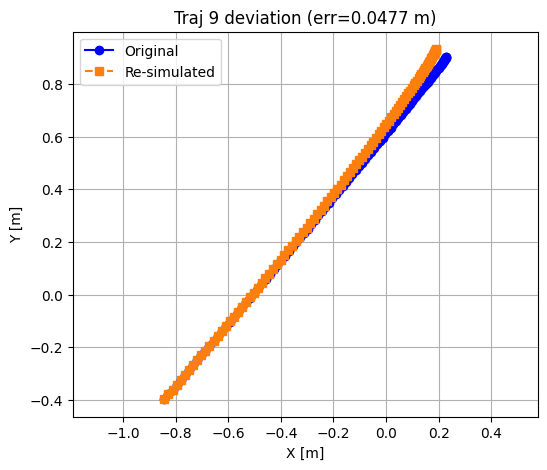

Trajectory 10 removed: max position error = 0.1607 m


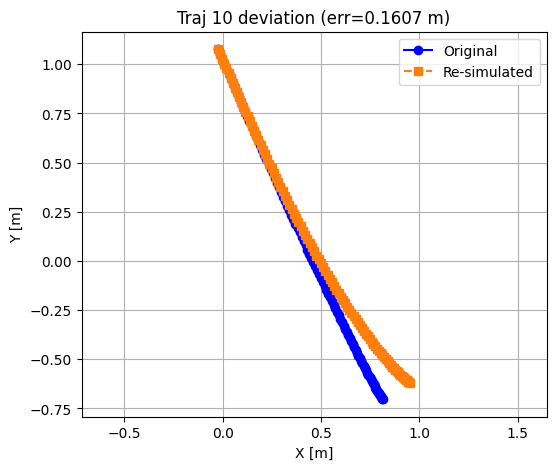

Trajectory 11 removed: max position error = 0.1725 m


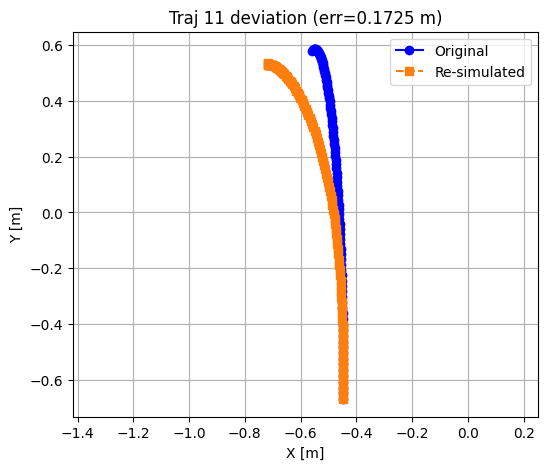

Trajectory 12 removed: max position error = 2.2798 m


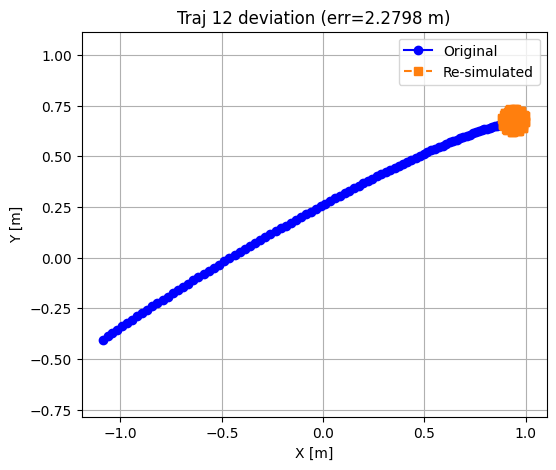

Trajectory 13 removed: max position error = 0.5478 m


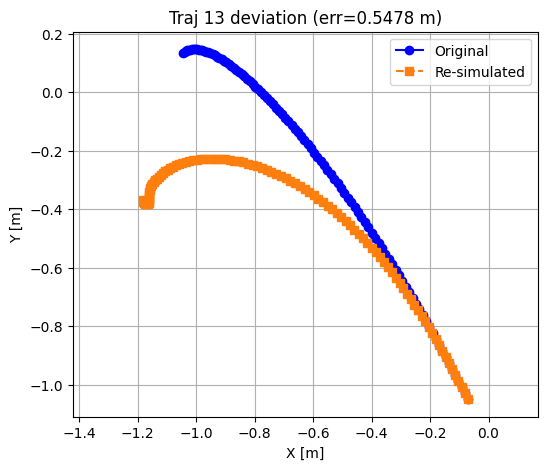

Trajectory 14 removed: max position error = 0.1540 m


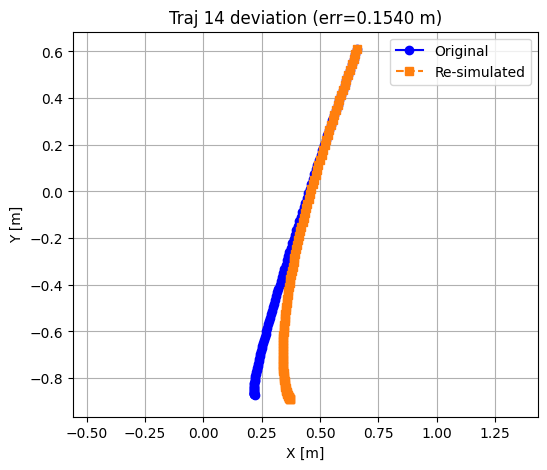

Trajectory 15 removed: max position error = 1.8711 m


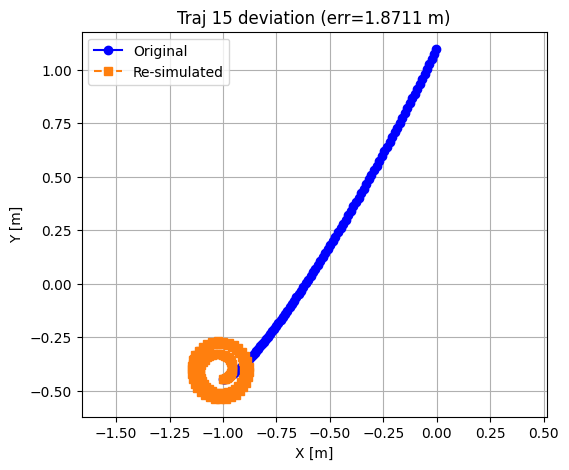

Trajectory 16 removed: max position error = 1.8308 m


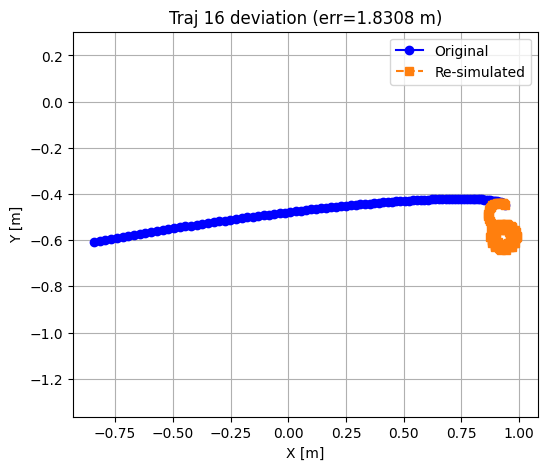

Trajectory 17 removed: max position error = 1.8392 m


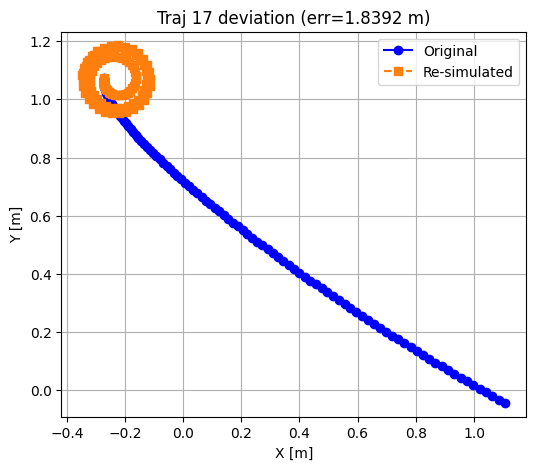

Trajectory 18 removed: max position error = 2.9503 m


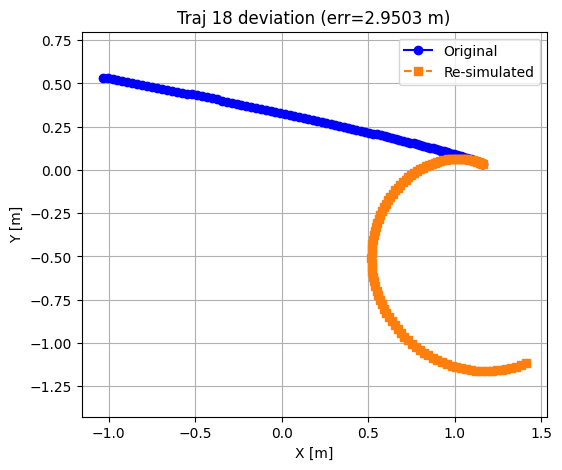

Trajectory 19 removed: max position error = 0.0830 m


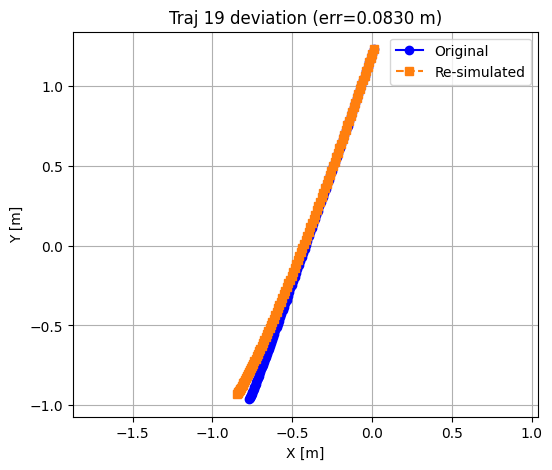

Trajectory 20 removed: max position error = 0.0237 m


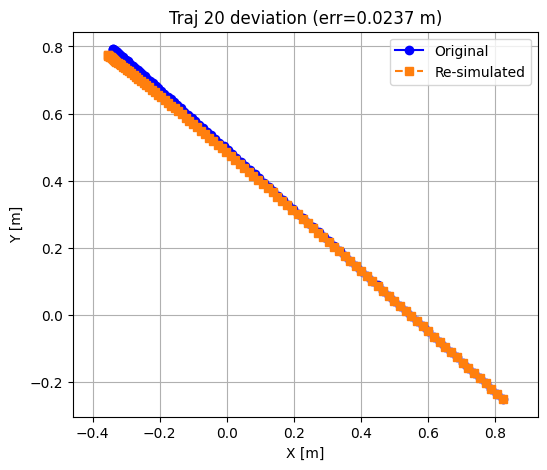

Trajectory 21 removed: max position error = 0.0687 m


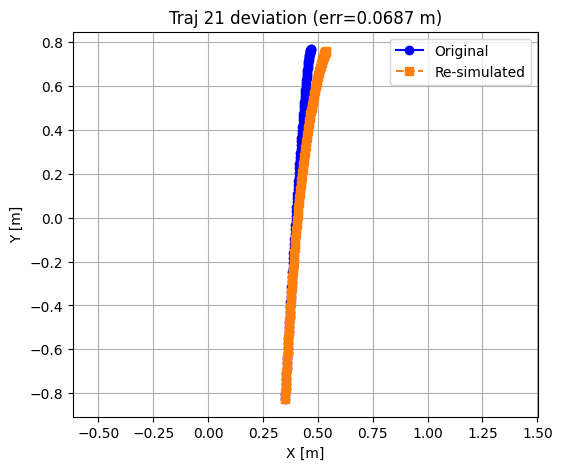

Trajectory 22 removed: max position error = 0.3602 m


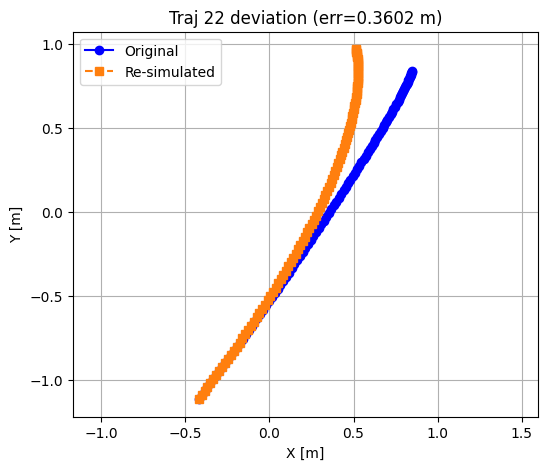

Trajectory 23 removed: max position error = 2.6989 m


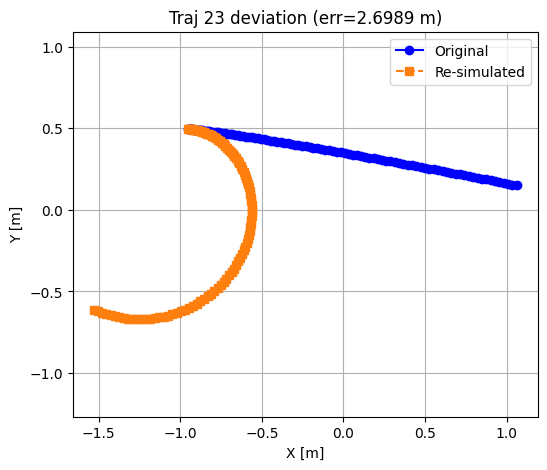

Trajectory 24 removed: max position error = 1.5197 m


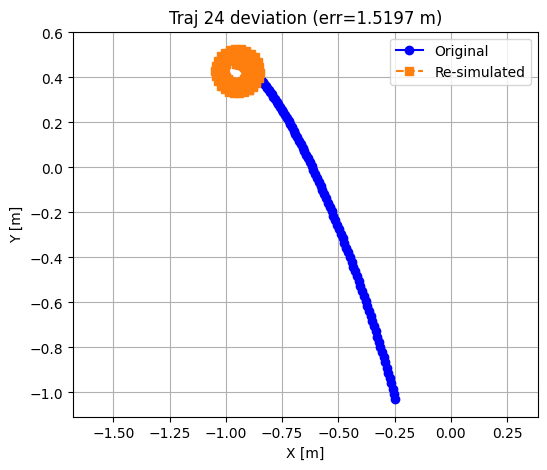

Trajectory 25 removed: max position error = 1.9713 m


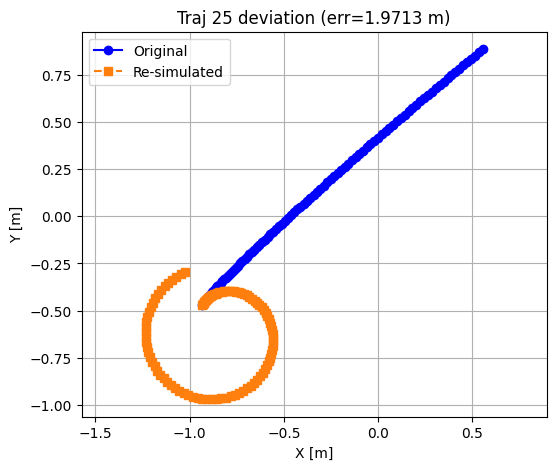

Trajectory 26 removed: max position error = 0.3855 m


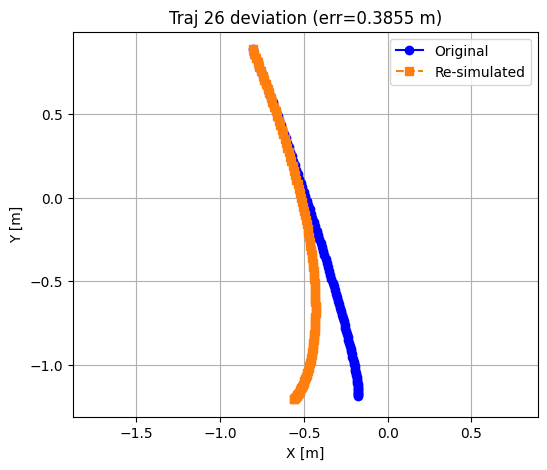

Trajectory 27 removed: max position error = 2.2429 m


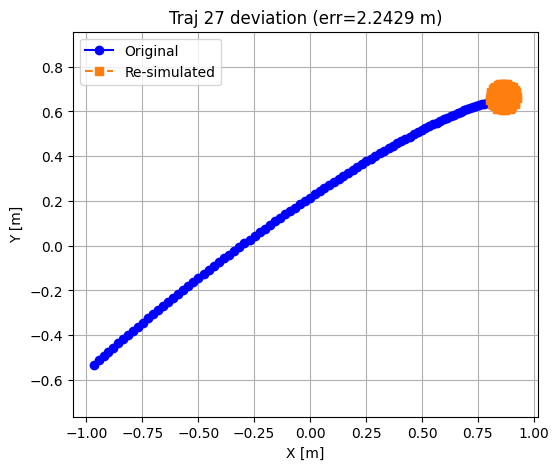

Trajectory 28 removed: max position error = 1.6581 m


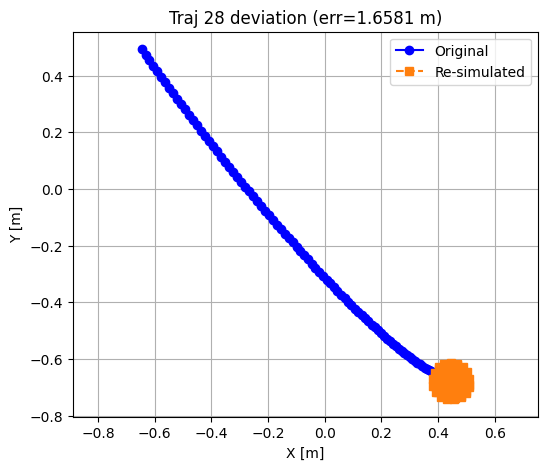

Trajectory 29 removed: max position error = 0.0798 m


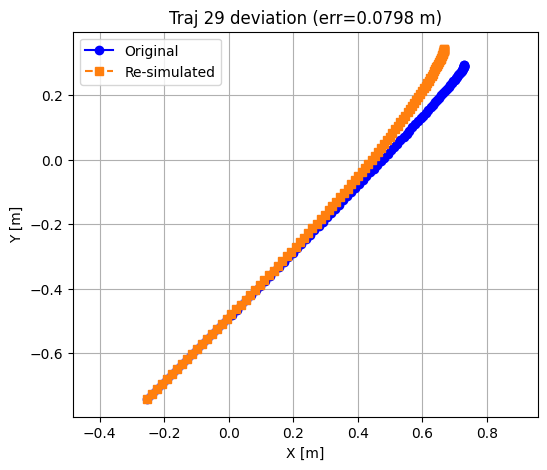

Trajectory 30 removed: max position error = 1.7840 m


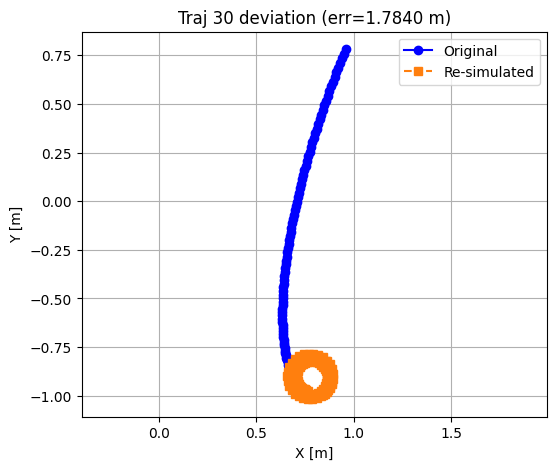

Trajectory 31 removed: max position error = 1.1635 m


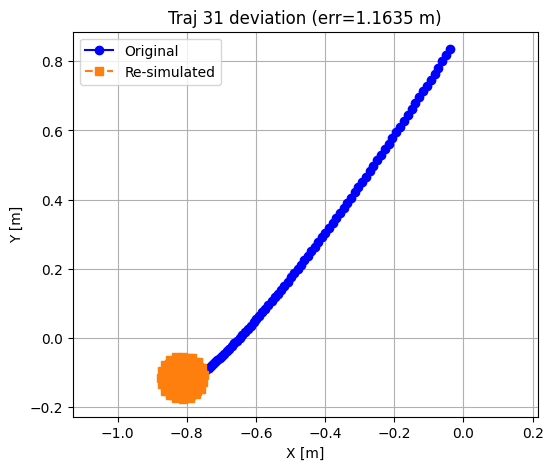

Trajectory 32 removed: max position error = 0.3622 m


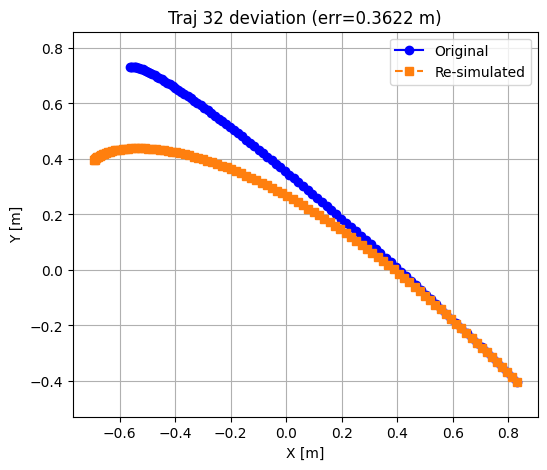

Trajectory 33 removed: max position error = 0.2345 m


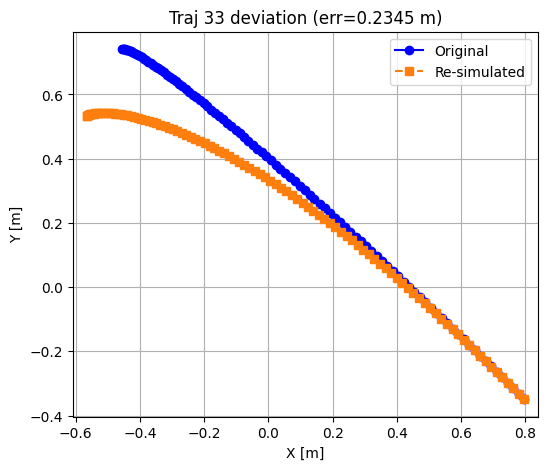

Trajectory 34 removed: max position error = 0.3361 m


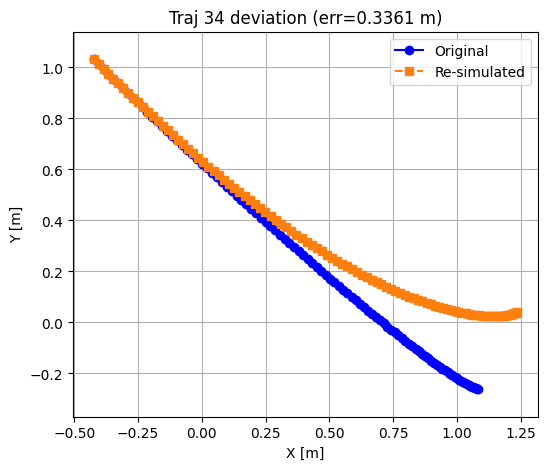

Trajectory 35 removed: max position error = 0.2952 m


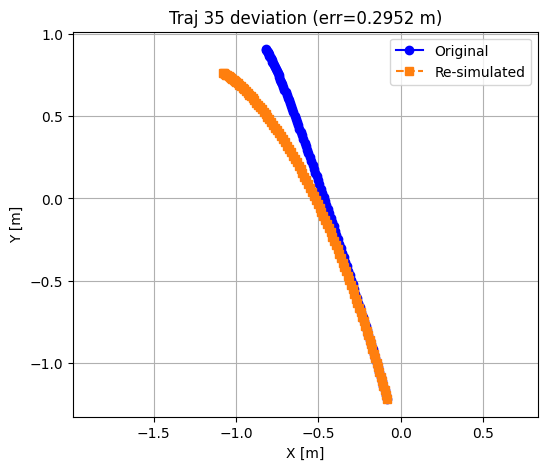

Trajectory 36 removed: max position error = 1.3430 m


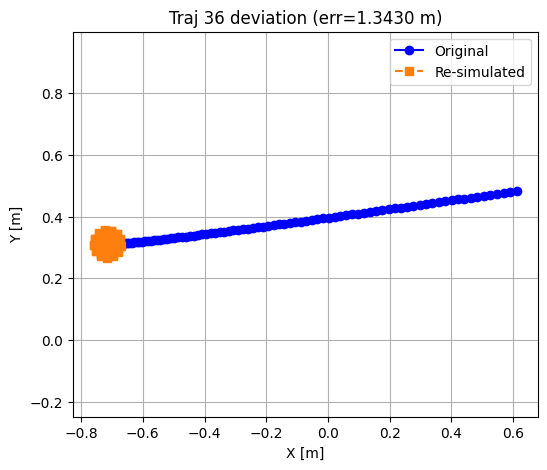

Trajectory 37 removed: max position error = 1.2921 m


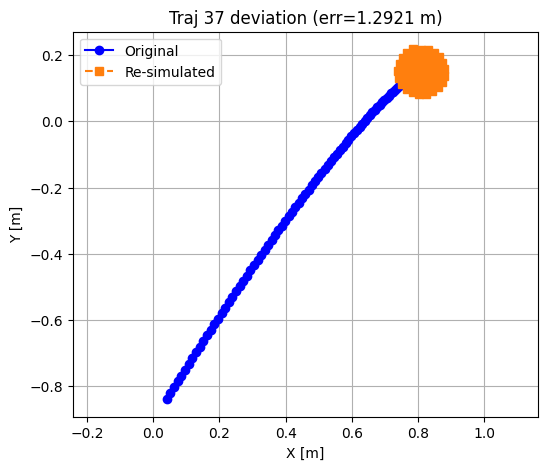

Trajectory 38 removed: max position error = 1.8266 m


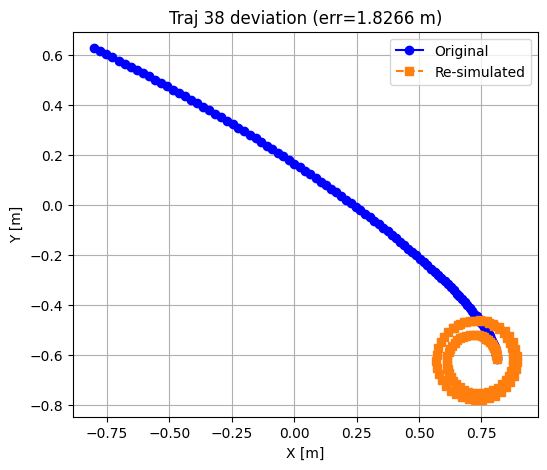

Trajectory 39 removed: max position error = 0.3950 m


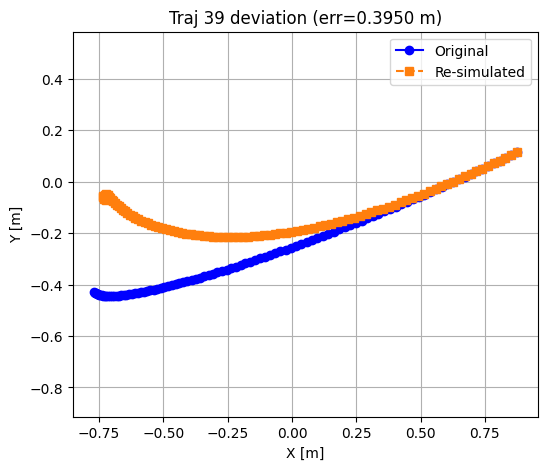

Trajectory 40 removed: max position error = 2.3717 m


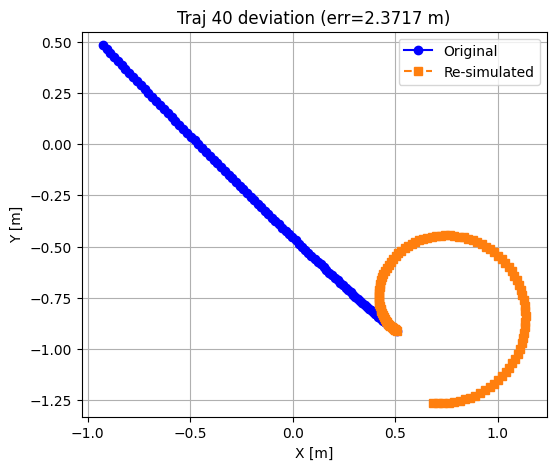

Trajectory 41 removed: max position error = 2.4208 m


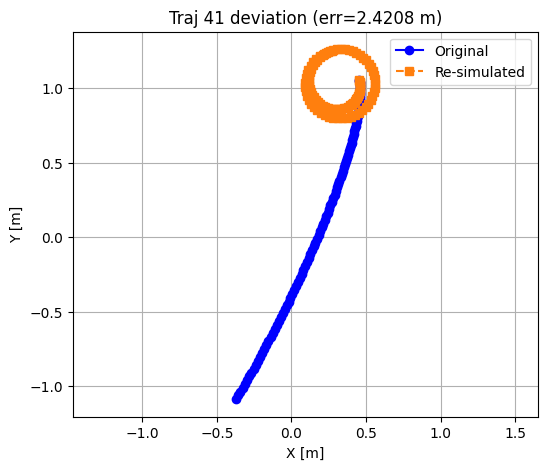

Trajectory 42 removed: max position error = 1.9023 m


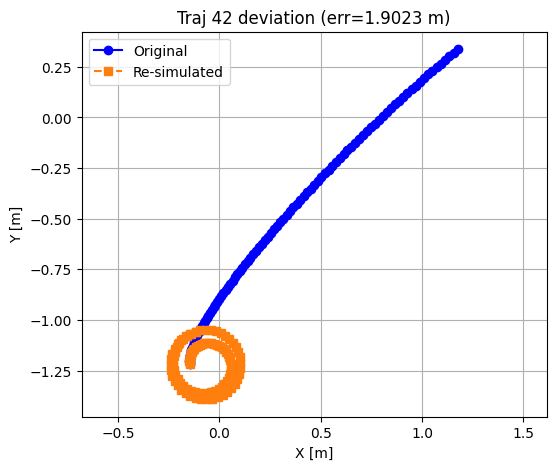

Trajectory 43 removed: max position error = 0.0650 m


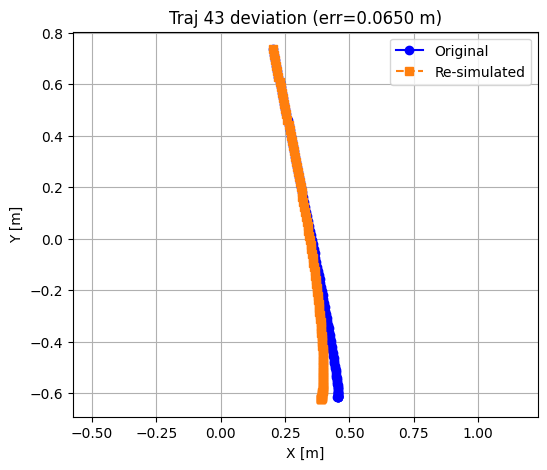

Trajectory 44 removed: max position error = 1.8175 m


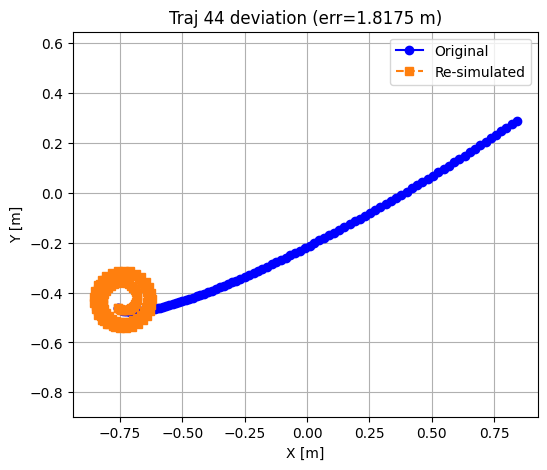

Trajectory 45 removed: max position error = 1.4473 m


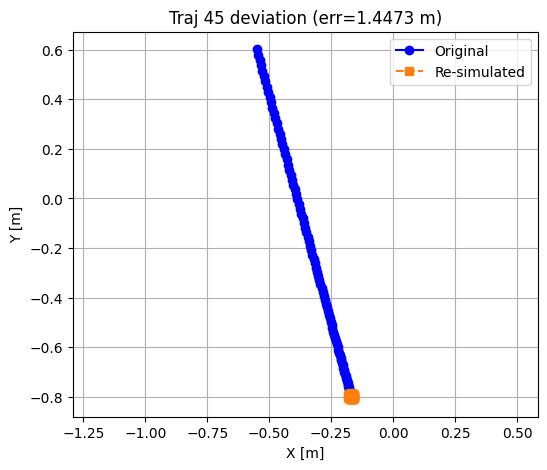

Trajectory 46 removed: max position error = 0.0395 m


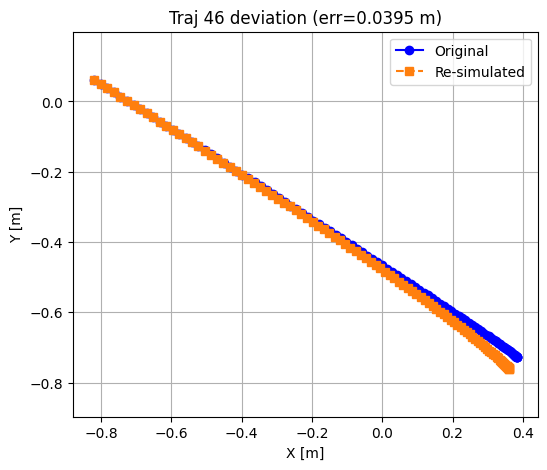

Trajectory 47 removed: max position error = 0.2133 m


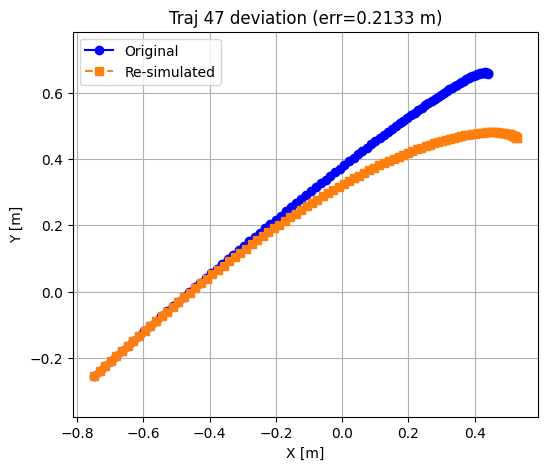

Trajectory 48 removed: max position error = 1.4600 m


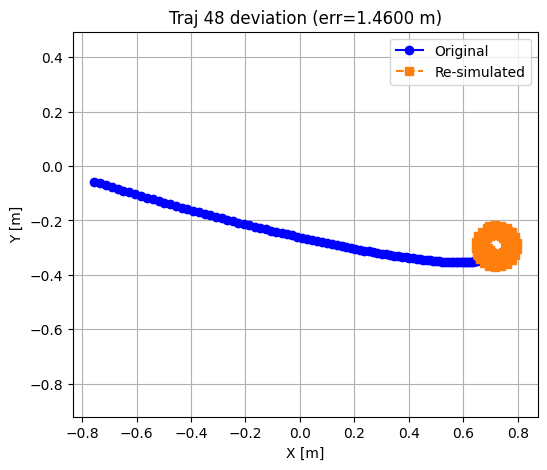

Trajectory 49 removed: max position error = 1.5752 m


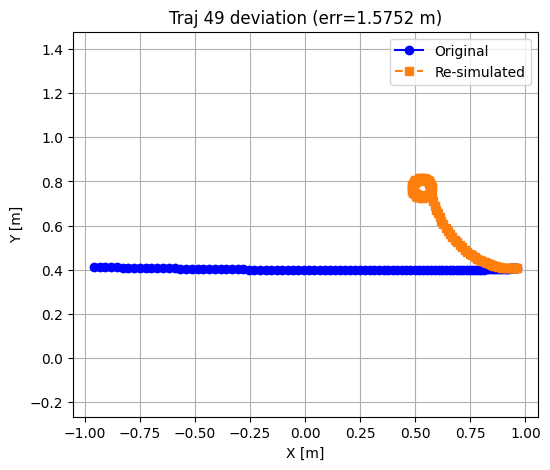

Trajectory 50 removed: max position error = 0.5641 m


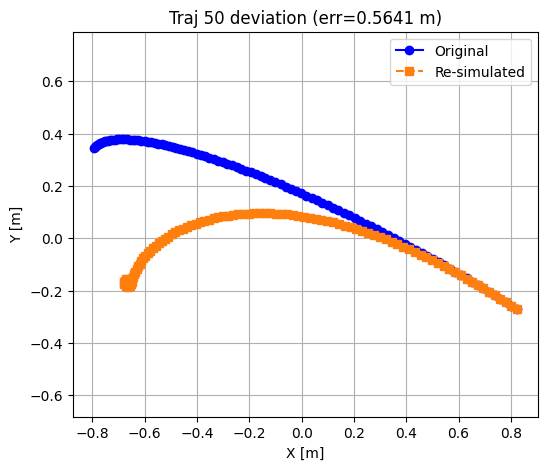

Trajectory 51 removed: max position error = 0.6855 m


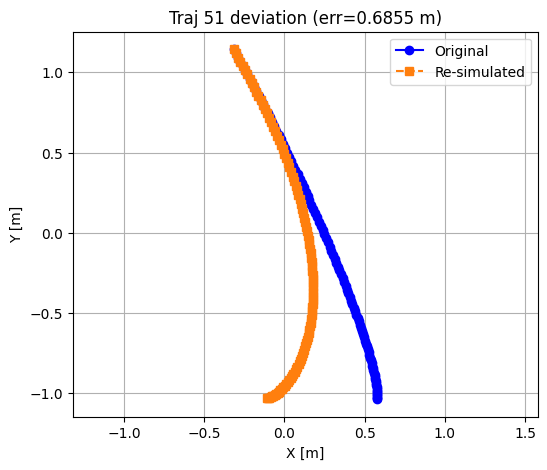

Trajectory 52 removed: max position error = 2.9976 m


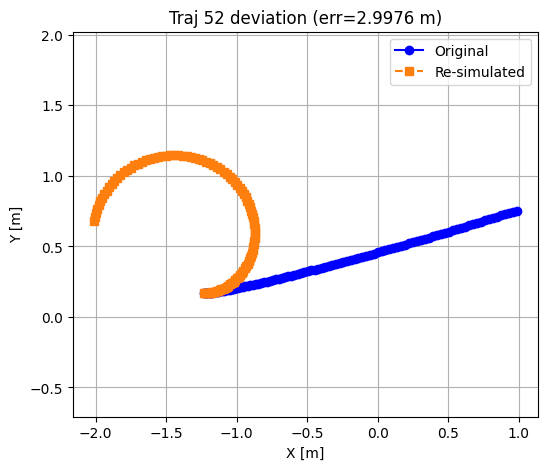

Trajectory 53 removed: max position error = 1.3667 m


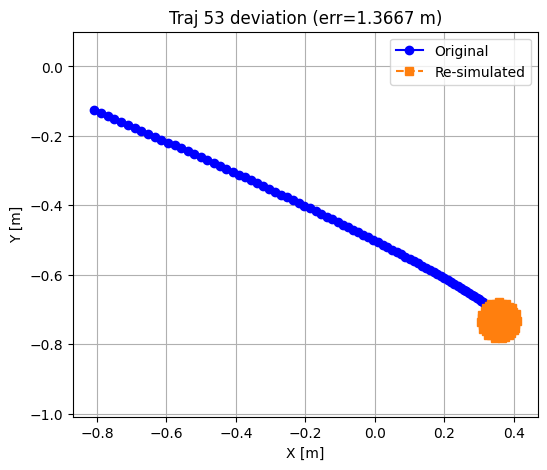

Trajectory 54 removed: max position error = 1.5780 m


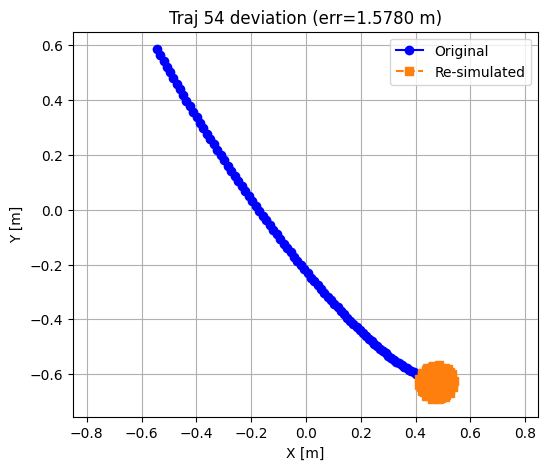

Trajectory 55 removed: max position error = 1.2591 m


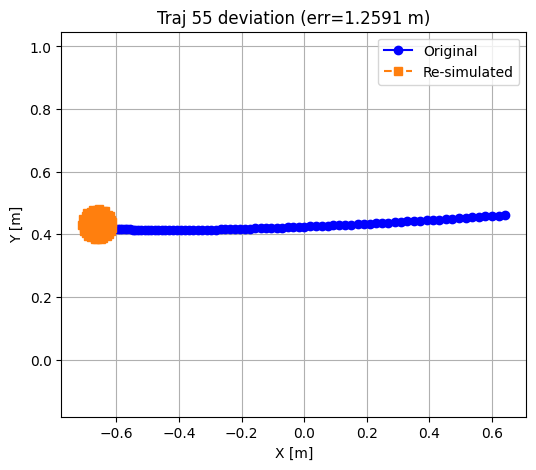

Trajectory 56 removed: max position error = 0.3077 m


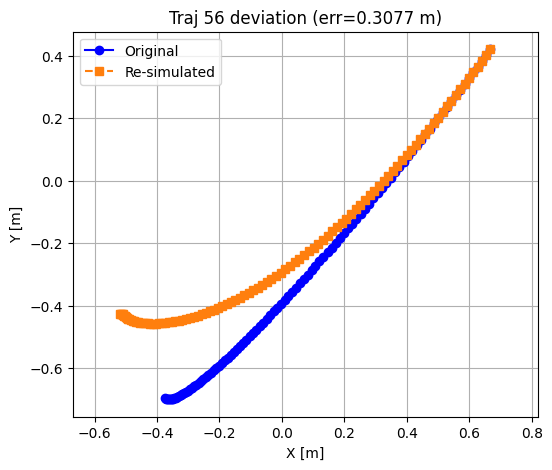

Trajectory 57 removed: max position error = 0.3984 m


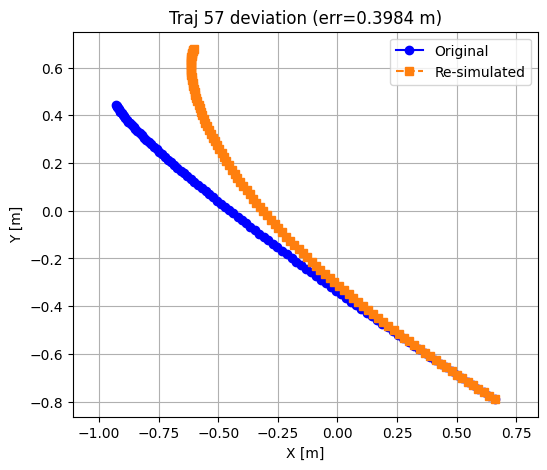

Trajectory 58 removed: max position error = 1.2537 m


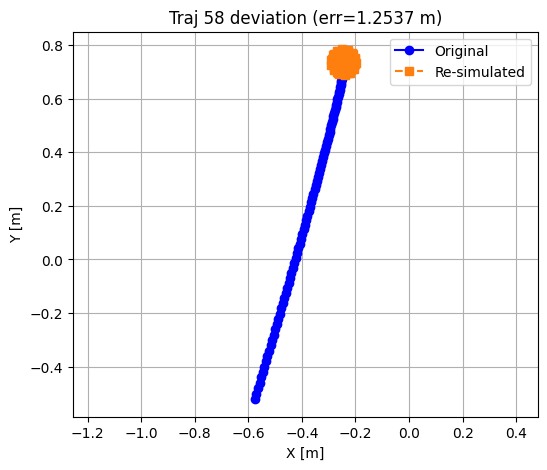

Trajectory 59 removed: max position error = 2.1375 m


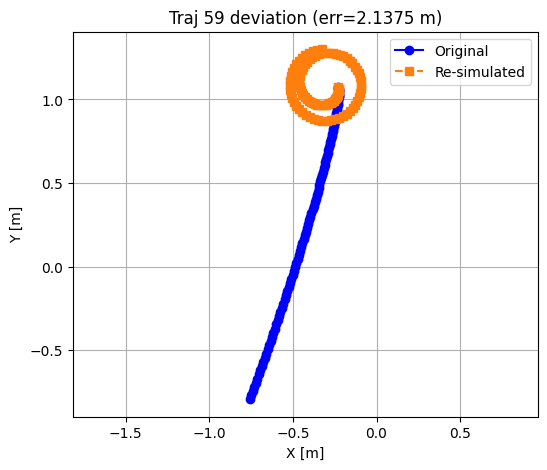

Trajectory 60 removed: max position error = 1.5851 m


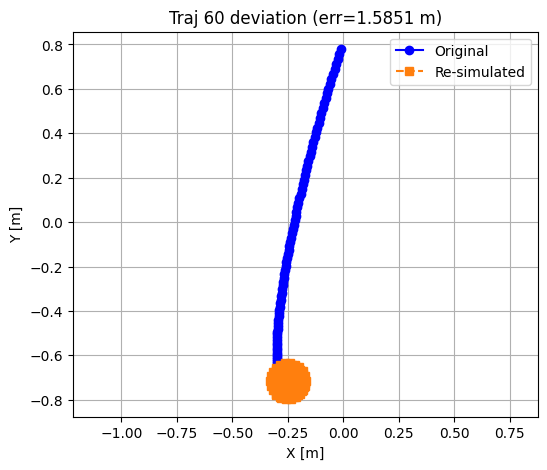

Trajectory 61 removed: max position error = 0.2482 m


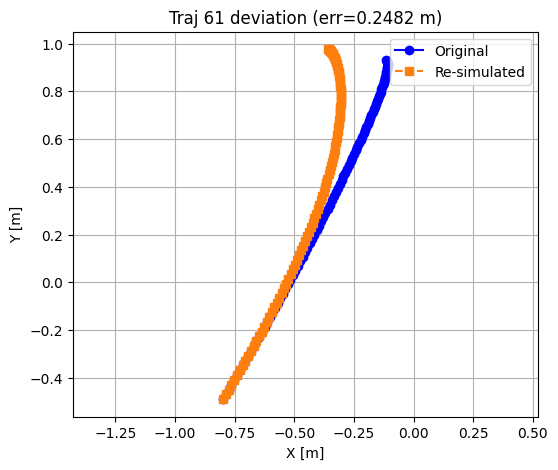

Trajectory 62 removed: max position error = 1.7489 m


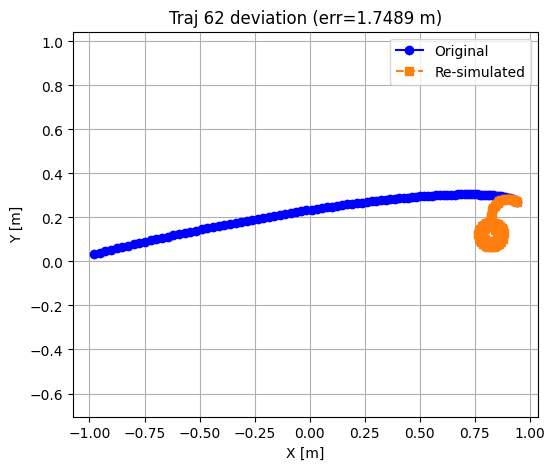

Trajectory 63 removed: max position error = 1.8766 m


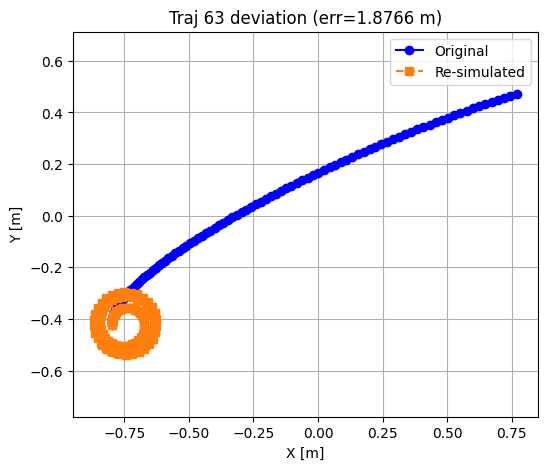

Trajectory 64 removed: max position error = 2.4963 m


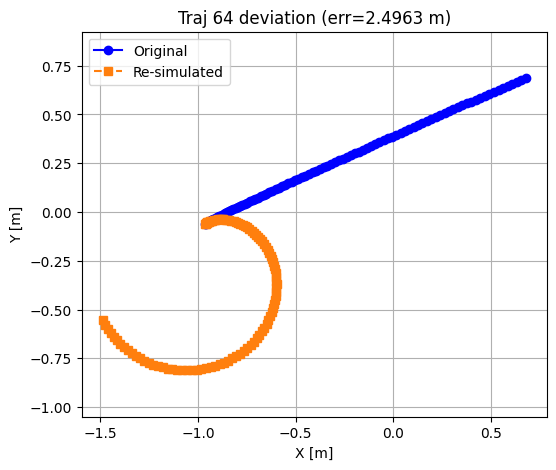

Trajectory 65 removed: max position error = 1.5270 m


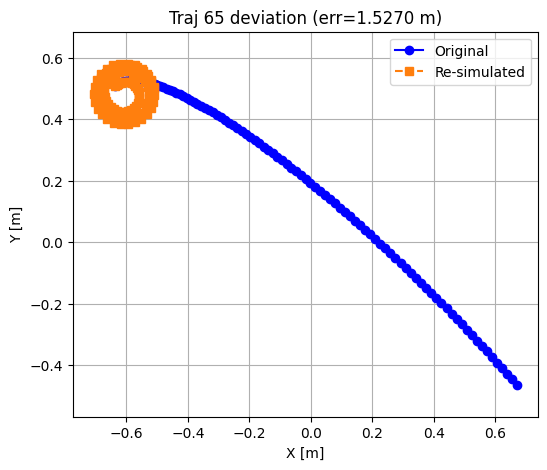

Trajectory 66 removed: max position error = 2.9753 m


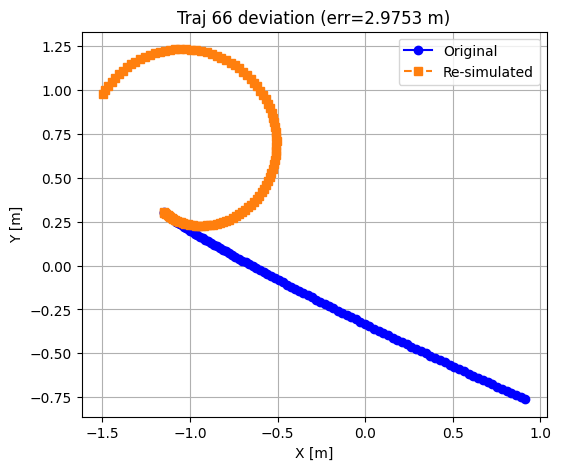

Trajectory 67 removed: max position error = 0.4169 m


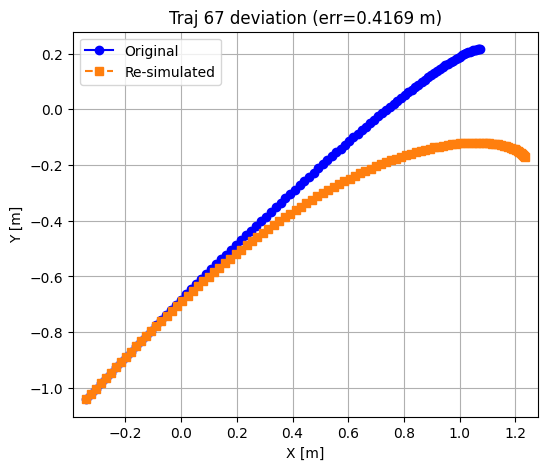

Trajectory 68 removed: max position error = 1.6268 m


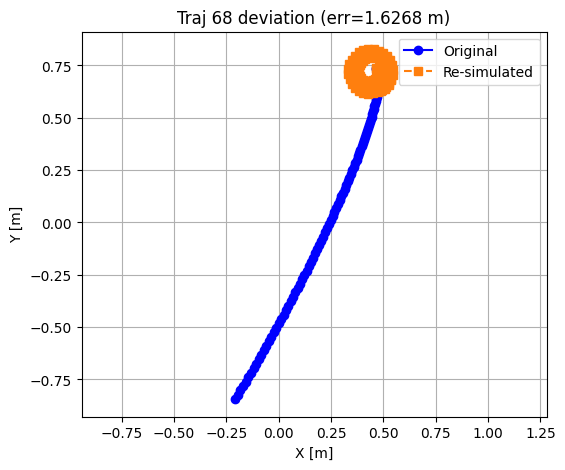

Trajectory 69 removed: max position error = 0.1405 m


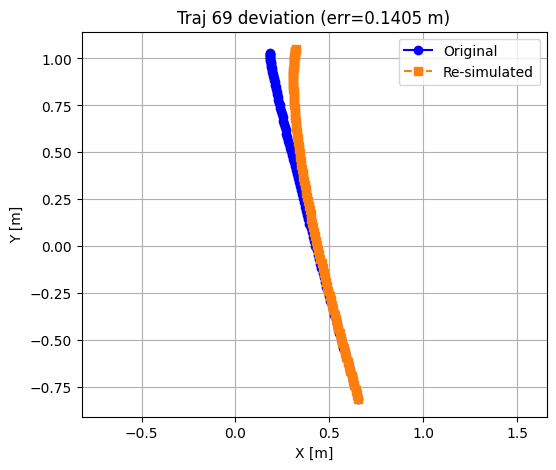

Trajectory 70 removed: max position error = 1.9783 m


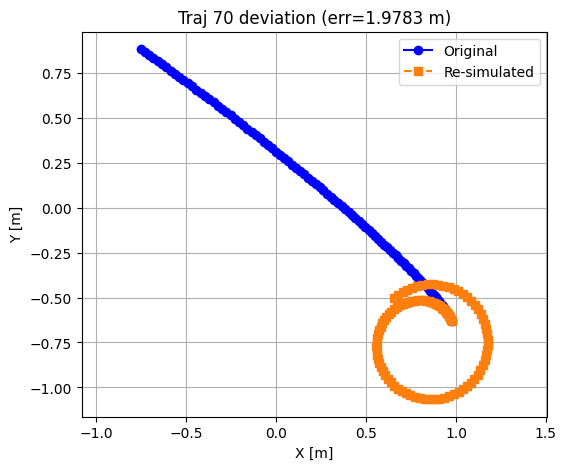

Trajectory 71 removed: max position error = 1.6264 m


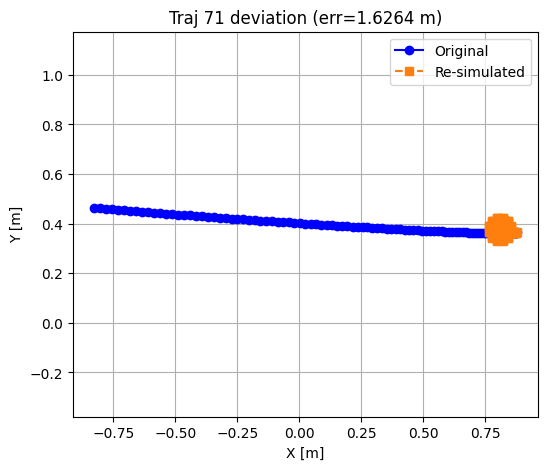

Trajectory 73 removed: max position error = 2.2876 m


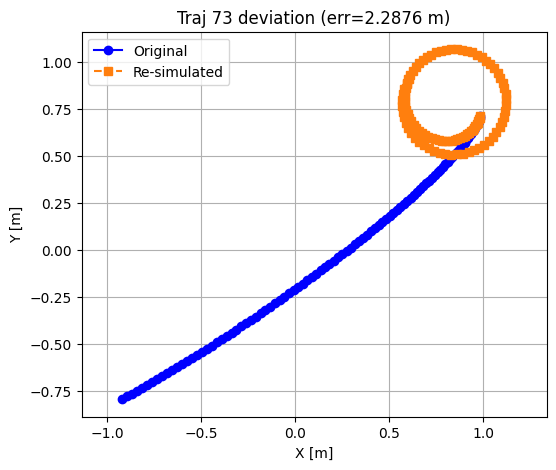

Trajectory 74 removed: max position error = 0.2239 m


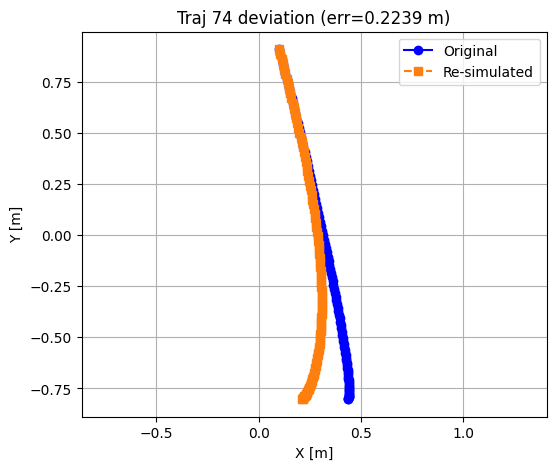

Trajectory 75 removed: max position error = 1.4291 m


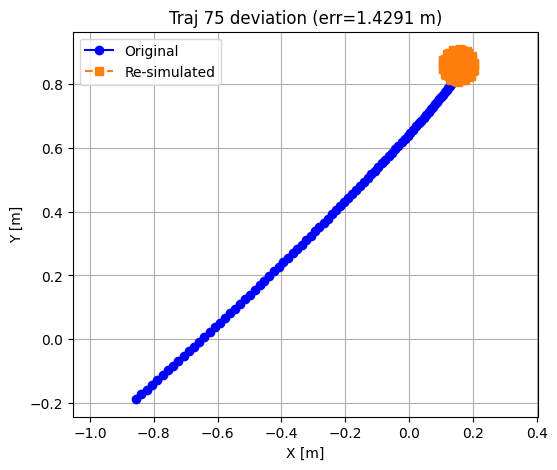

Trajectory 76 removed: max position error = 1.9087 m


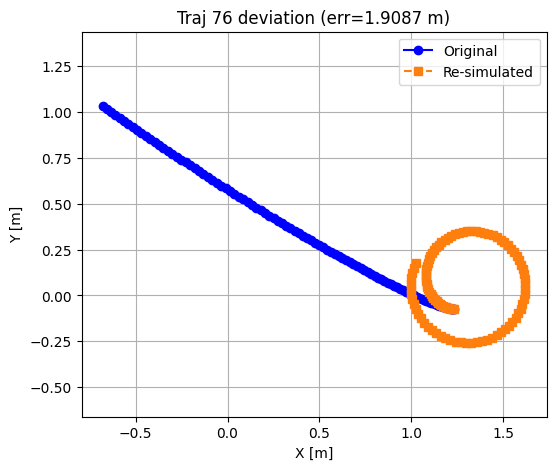

Trajectory 77 removed: max position error = 1.3927 m


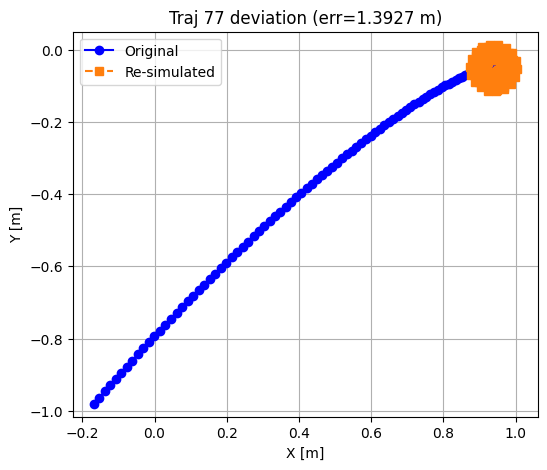

Trajectory 78 removed: max position error = 0.1850 m


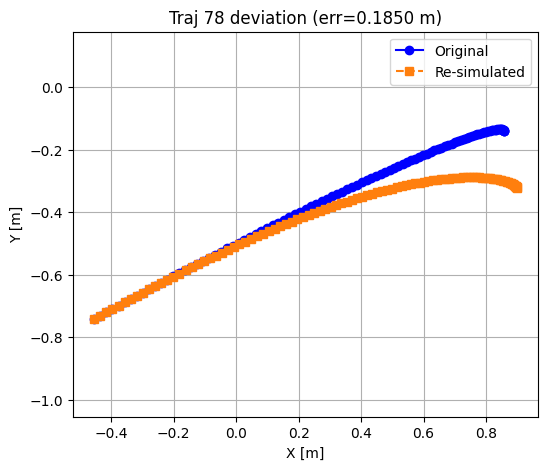

Trajectory 79 removed: max position error = 1.6702 m


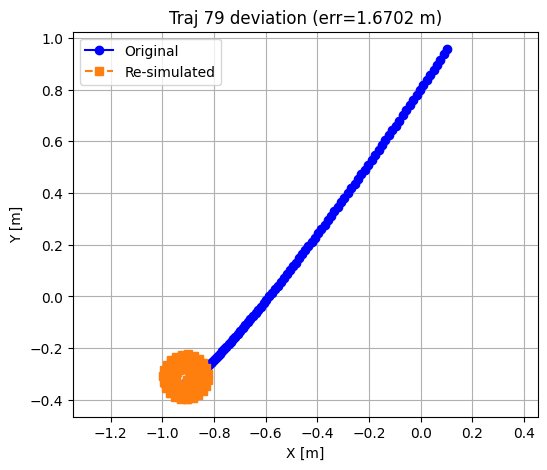

Trajectory 80 removed: max position error = 1.8872 m


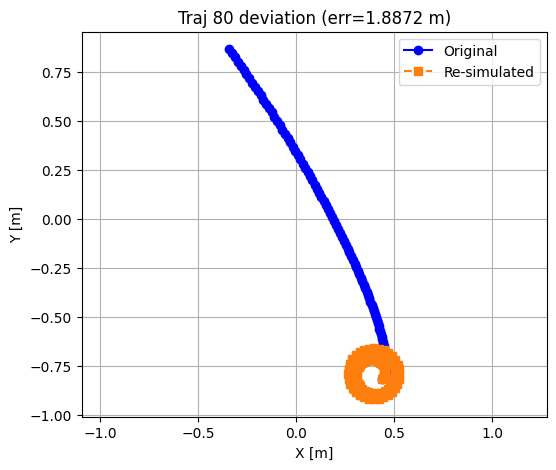

Trajectory 81 removed: max position error = 2.2931 m


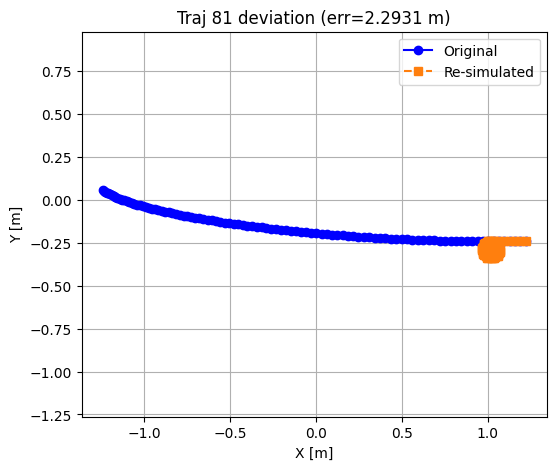

Trajectory 82 removed: max position error = 2.8221 m


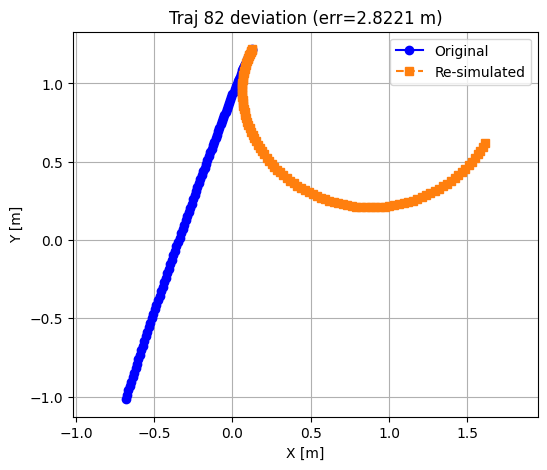

Trajectory 83 removed: max position error = 2.0859 m


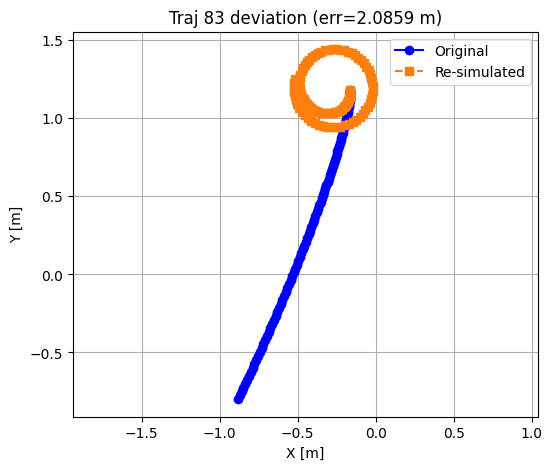

Trajectory 84 removed: max position error = 1.4710 m


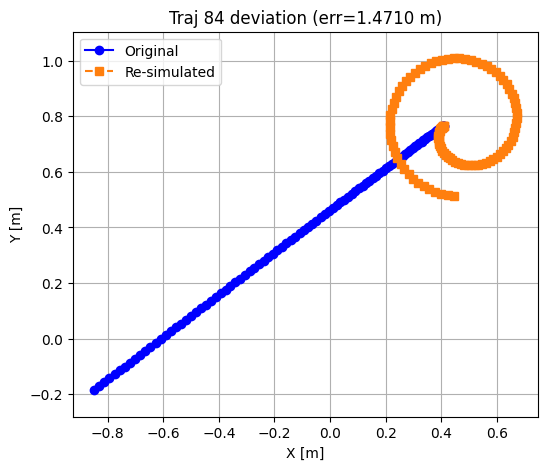

Trajectory 85 removed: max position error = 0.6411 m


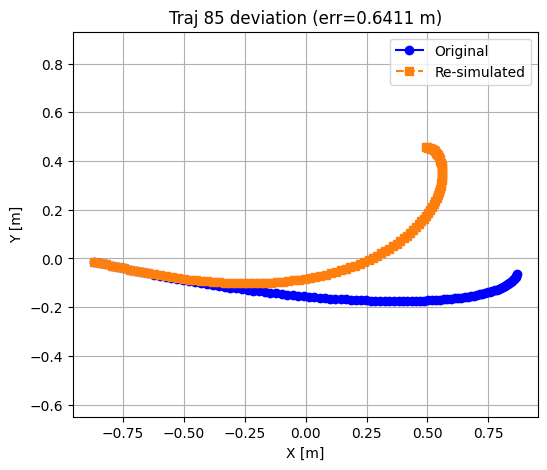

Trajectory 86 removed: max position error = 0.2762 m


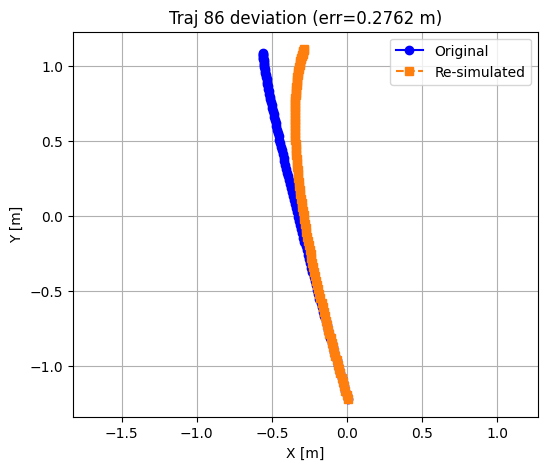

Trajectory 87 removed: max position error = 1.8277 m


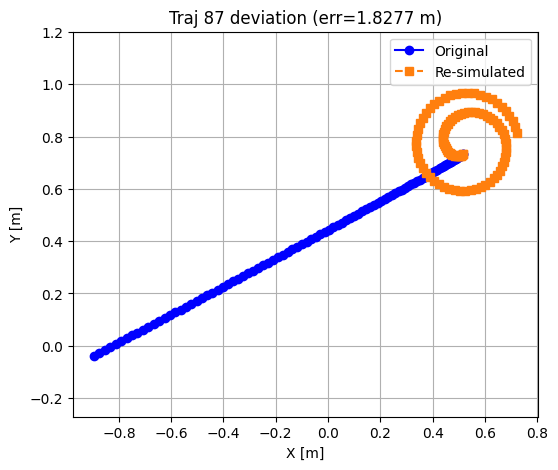

Trajectory 88 removed: max position error = 1.8939 m


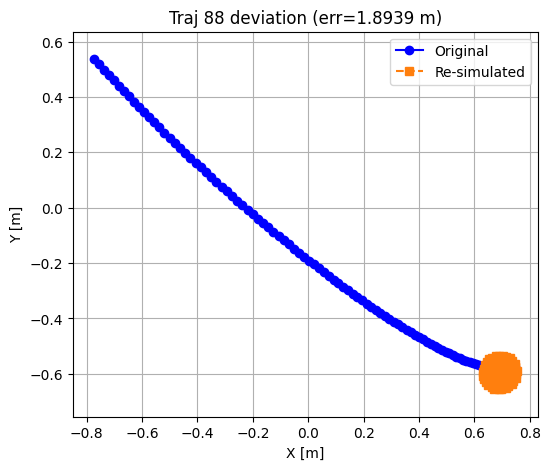

Trajectory 89 removed: max position error = 1.9789 m


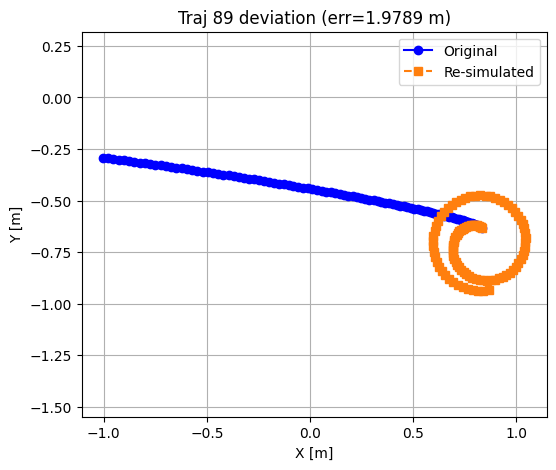

Trajectory 90 removed: max position error = 1.6849 m


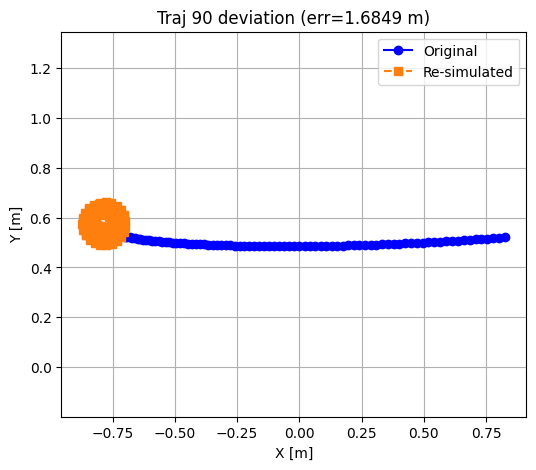

Trajectory 91 removed: max position error = 1.8063 m


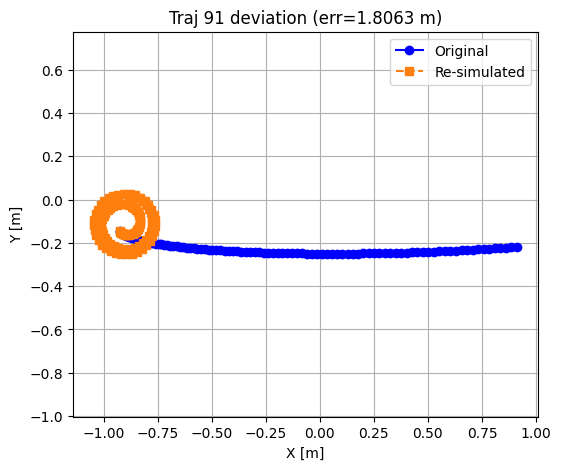

Trajectory 92 removed: max position error = 0.6529 m


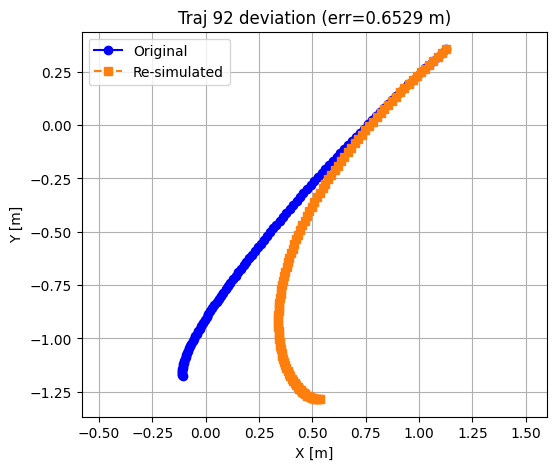

Trajectory 93 removed: max position error = 0.3247 m


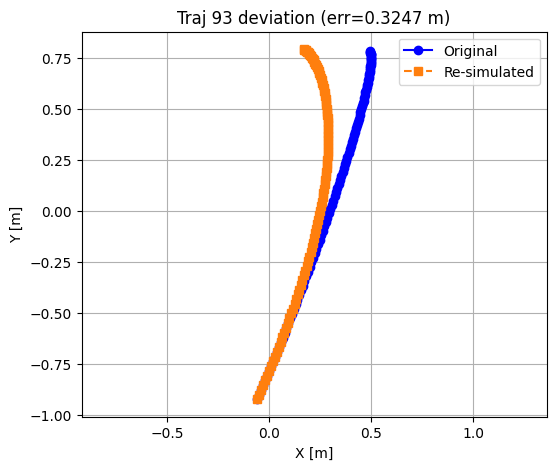

Trajectory 94 removed: max position error = 0.3202 m


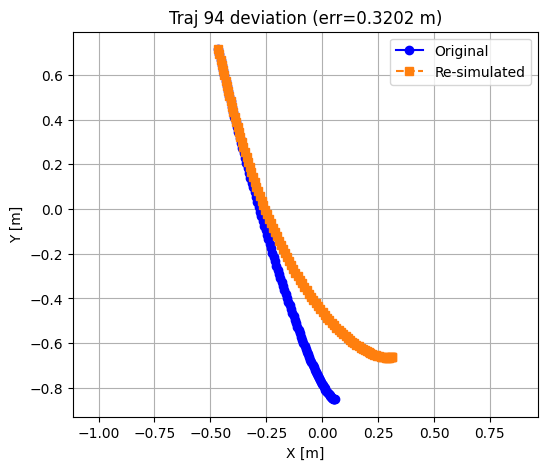

Trajectory 95 removed: max position error = 0.3776 m


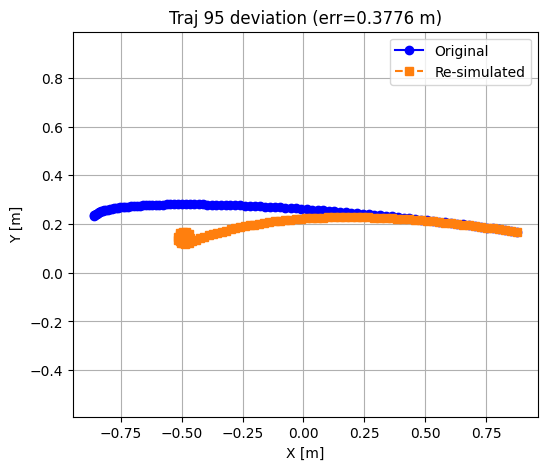

Trajectory 96 removed: max position error = 1.1083 m


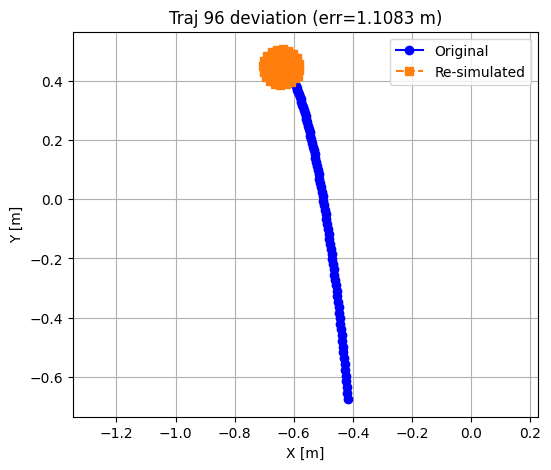

Trajectory 97 removed: max position error = 0.2837 m


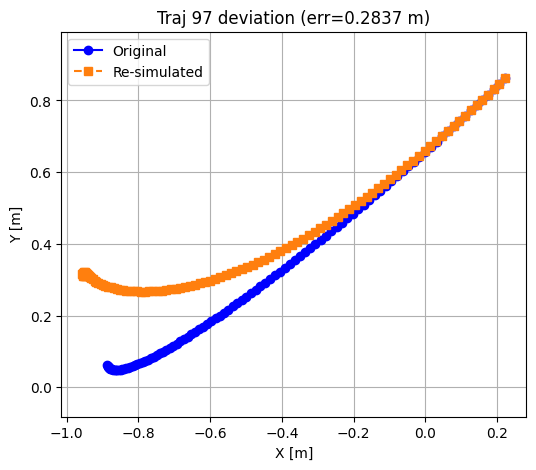

Trajectory 98 removed: max position error = 0.5954 m


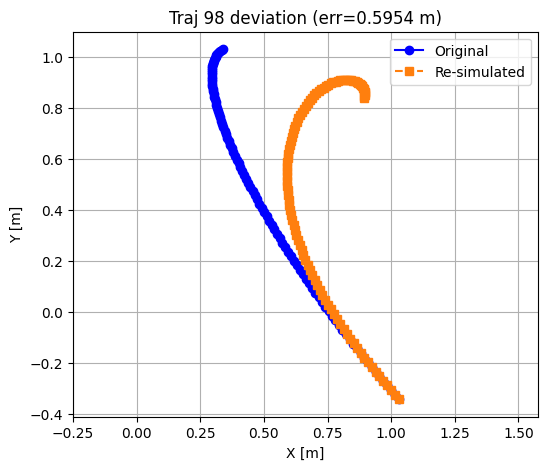

Trajectory 99 removed: max position error = 0.5357 m


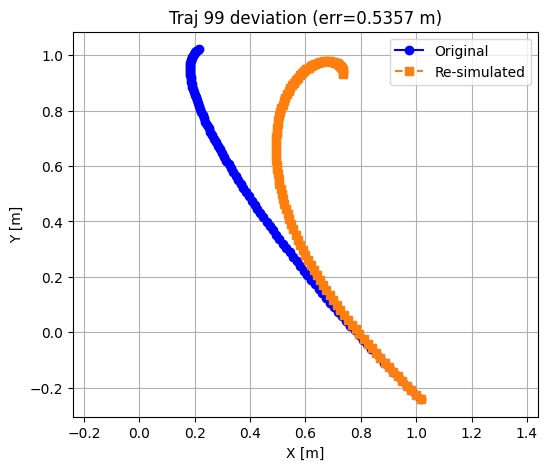

Trajectory 100 removed: max position error = 0.5176 m


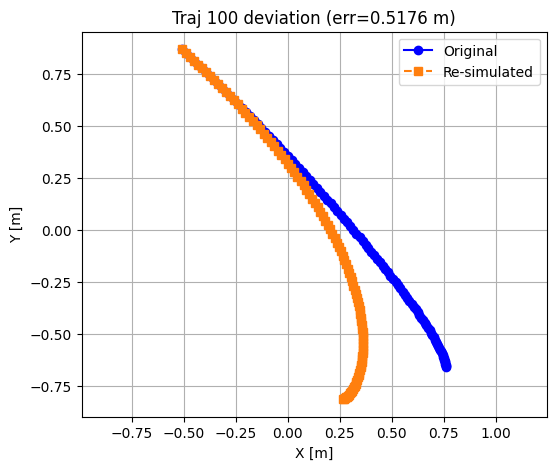

Trajectory 101 removed: max position error = 0.4762 m


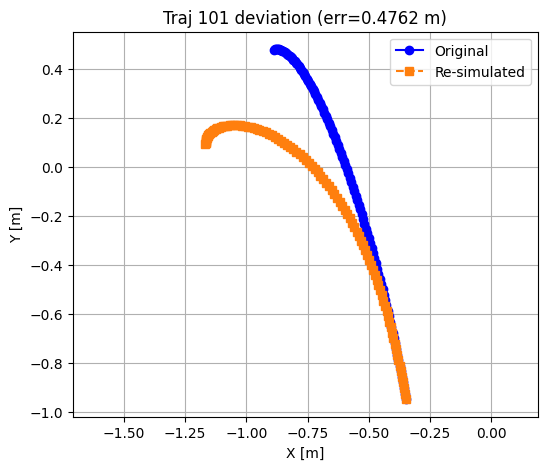

Trajectory 102 removed: max position error = 0.1631 m


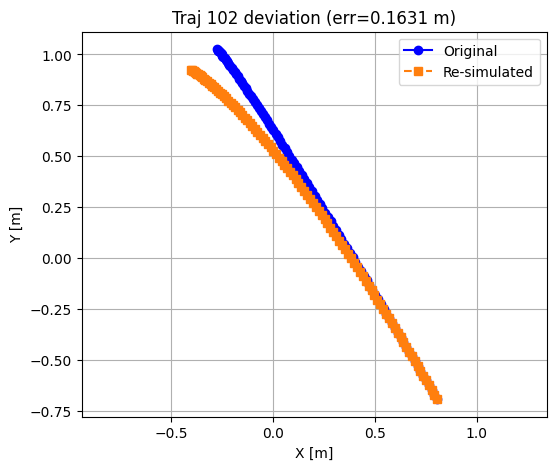

Trajectory 103 removed: max position error = 0.8750 m


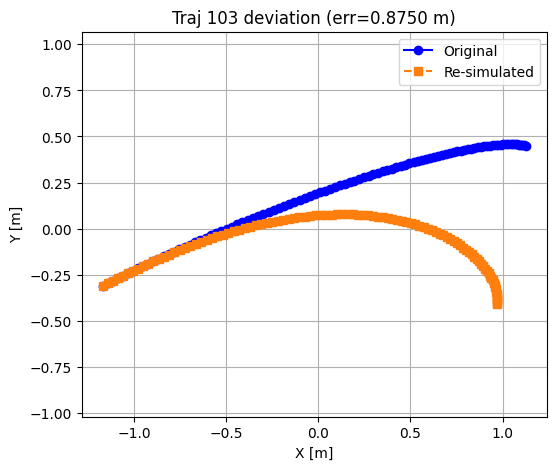

Trajectory 104 removed: max position error = 1.8147 m


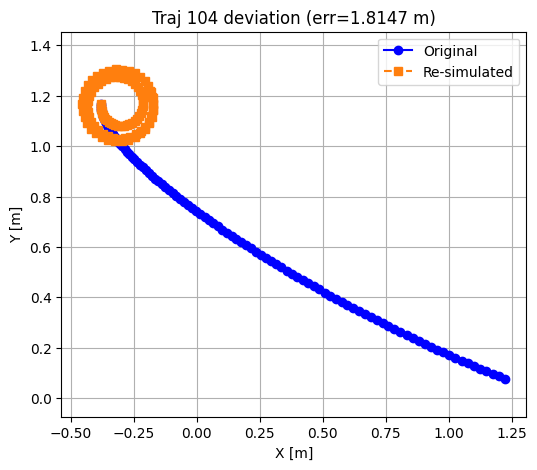

Trajectory 105 removed: max position error = 0.1767 m


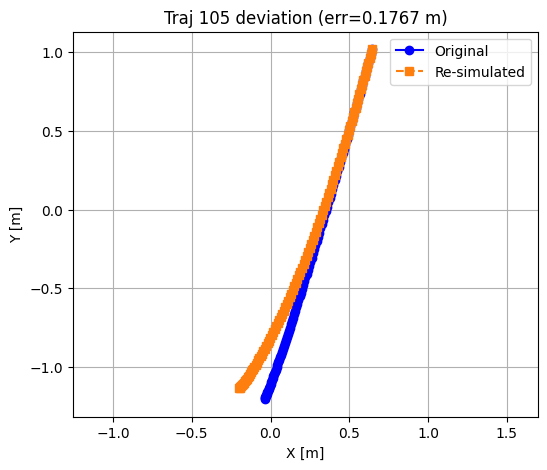

Trajectory 106 removed: max position error = 0.6181 m


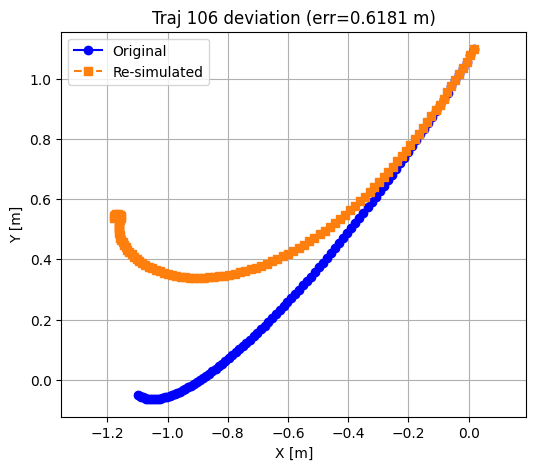

Trajectory 107 removed: max position error = 0.1709 m


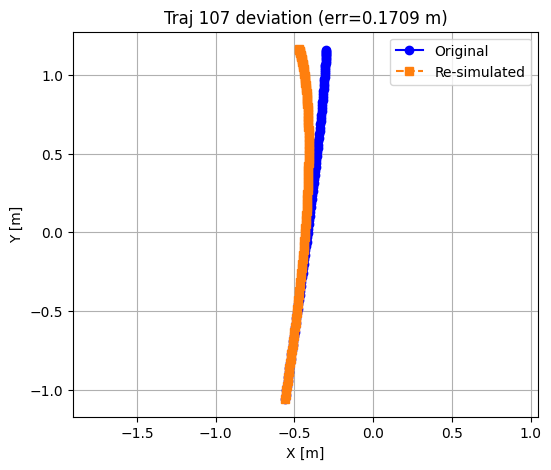

Trajectory 108 removed: max position error = 1.5551 m


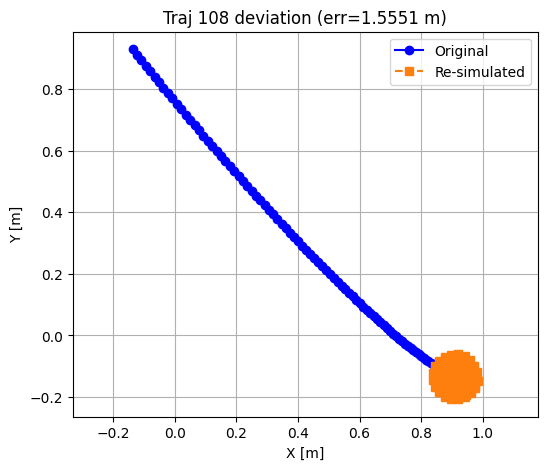

Trajectory 109 removed: max position error = 0.1047 m


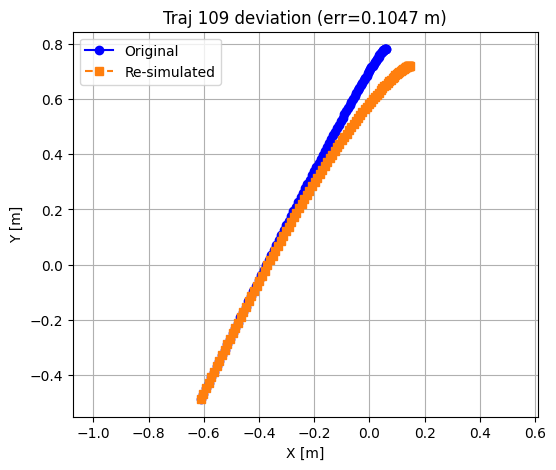

Trajectory 110 removed: max position error = 2.2762 m


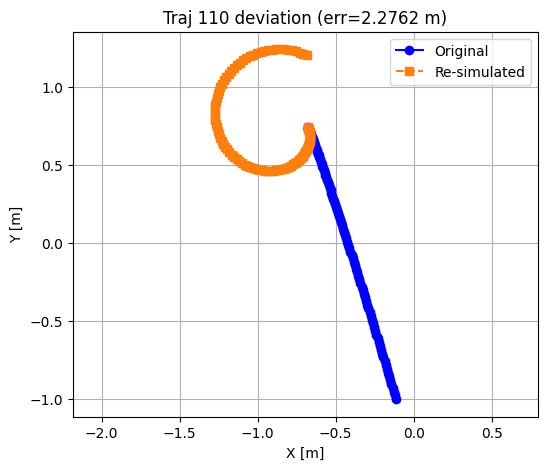

Trajectory 111 removed: max position error = 0.0443 m


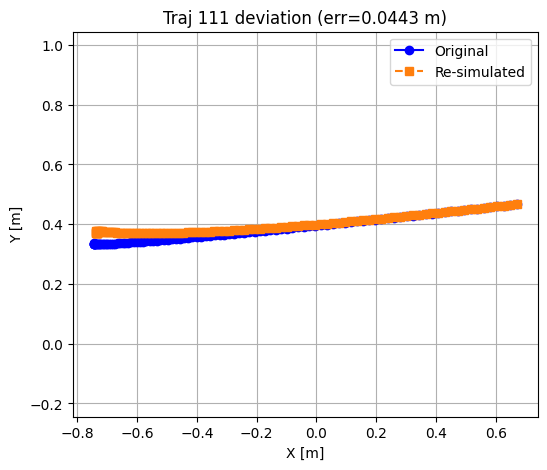

Trajectory 112 removed: max position error = 0.1782 m


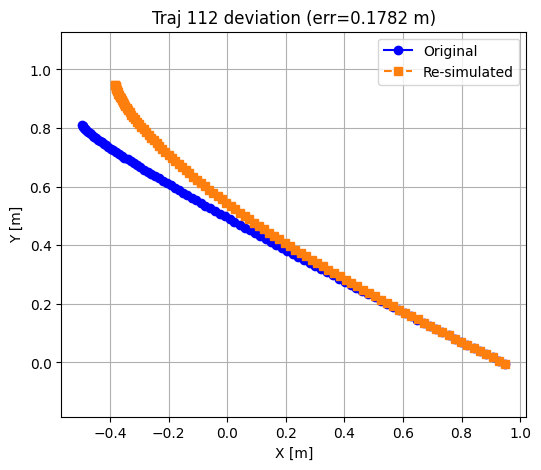

Trajectory 113 removed: max position error = 0.6589 m


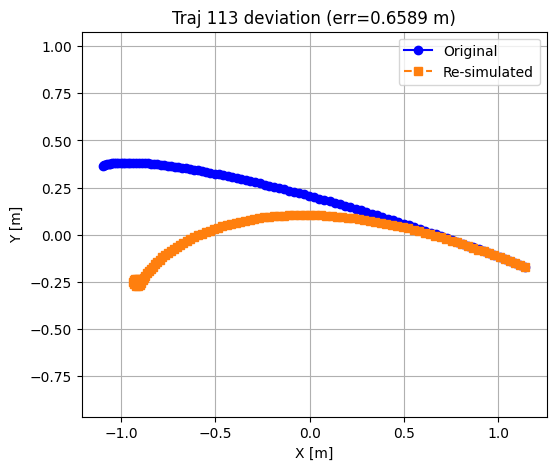

Trajectory 114 removed: max position error = 0.3472 m


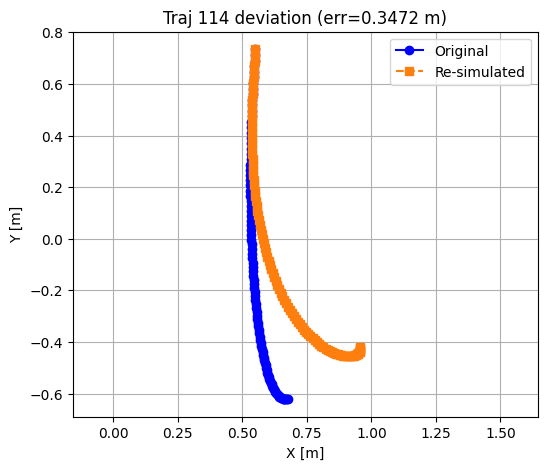

Trajectory 115 removed: max position error = 0.7919 m


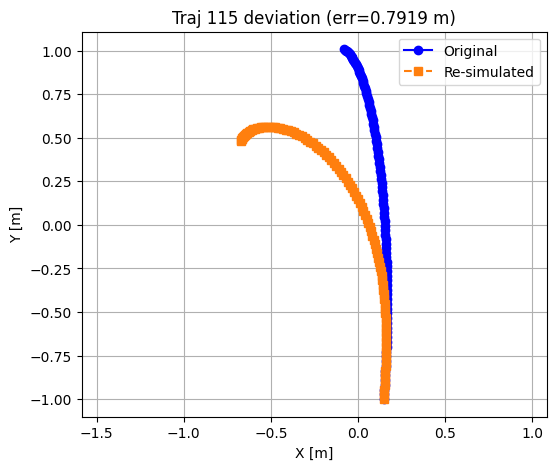

Trajectory 116 removed: max position error = 0.9748 m


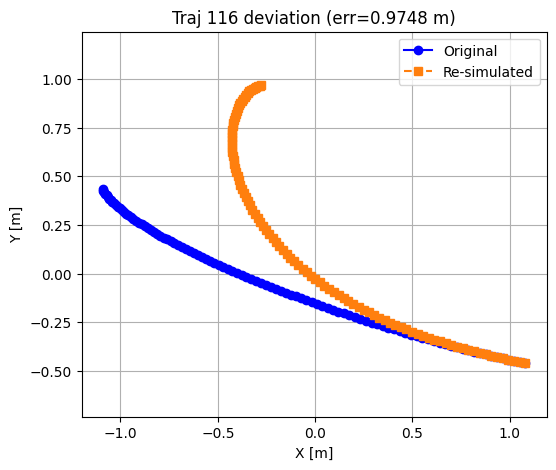

Trajectory 117 removed: max position error = 1.4996 m


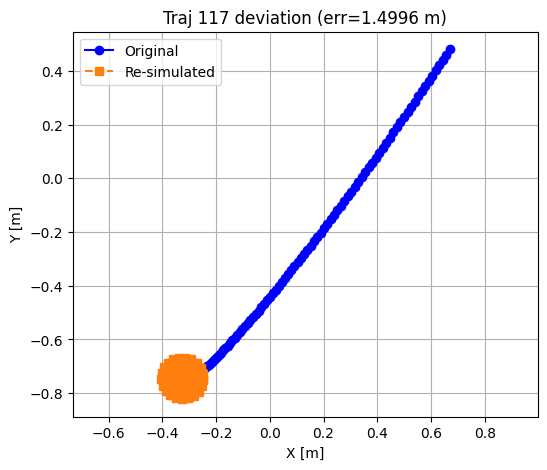

Trajectory 118 removed: max position error = 0.5560 m


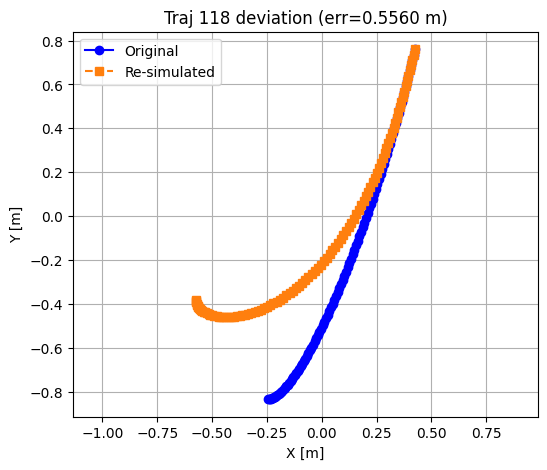

Trajectory 119 removed: max position error = 1.5238 m


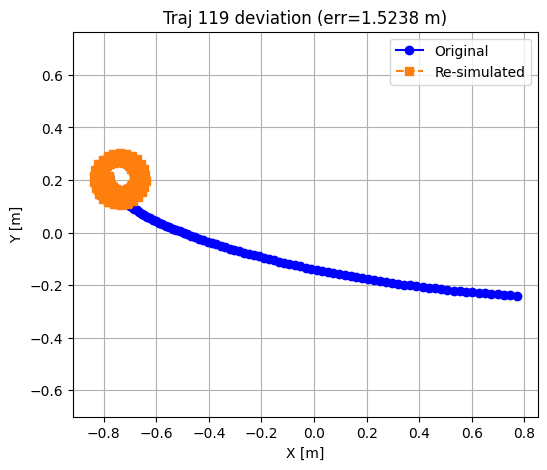

Trajectory 120 removed: max position error = 1.4394 m


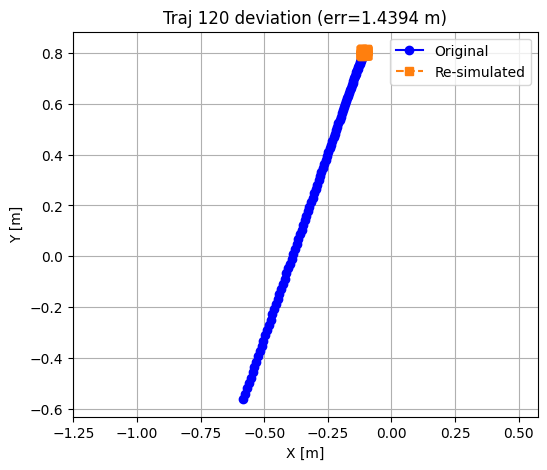

Trajectory 121 removed: max position error = 0.2598 m


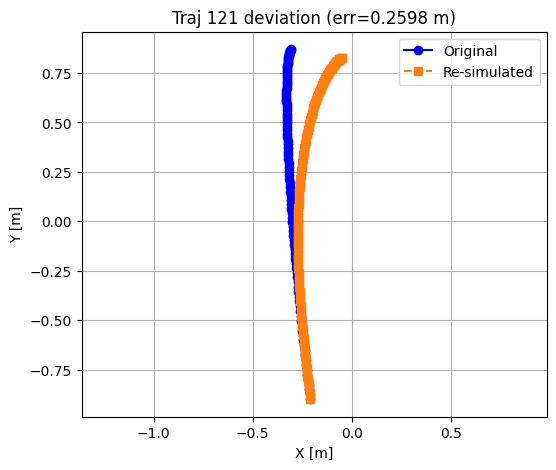

Trajectory 122 removed: max position error = 0.5907 m


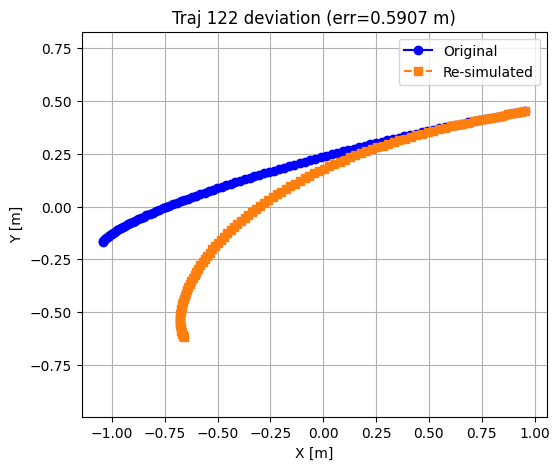

Trajectory 123 removed: max position error = 0.1935 m


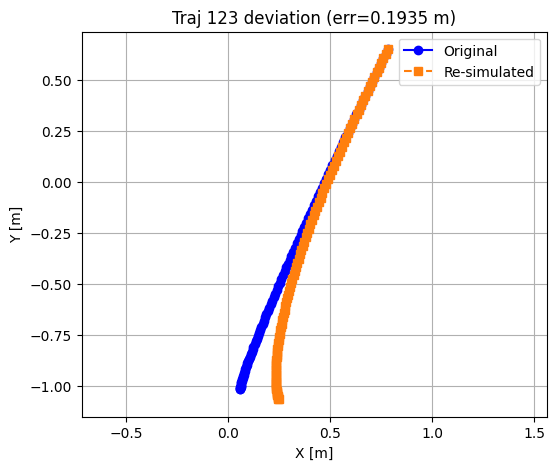

Trajectory 124 removed: max position error = 0.1400 m


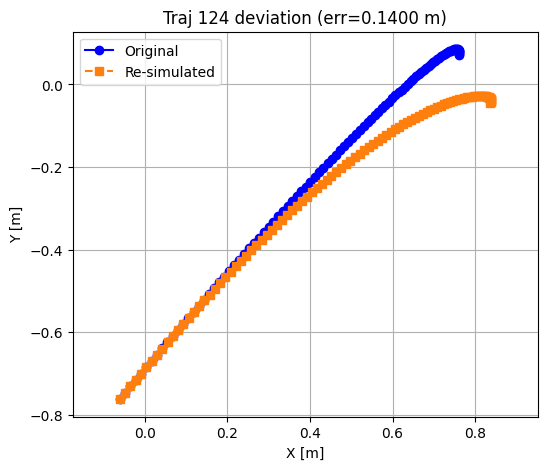

Trajectory 125 removed: max position error = 1.4840 m


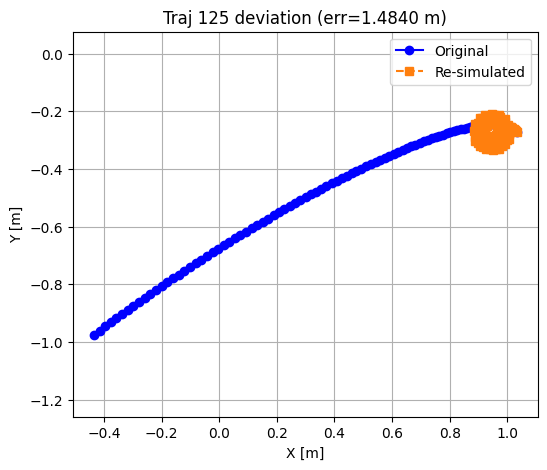

Trajectory 126 removed: max position error = 1.6403 m


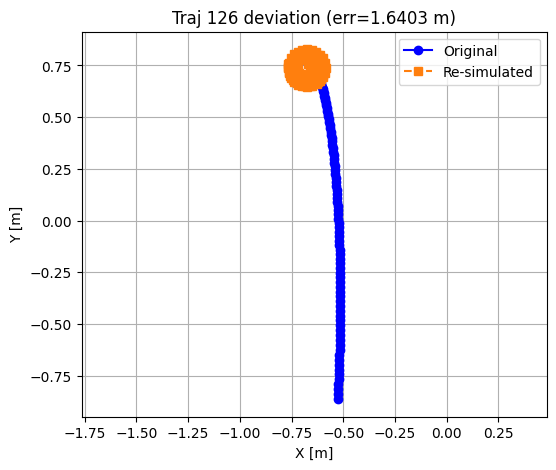

Trajectory 127 removed: max position error = 0.6664 m


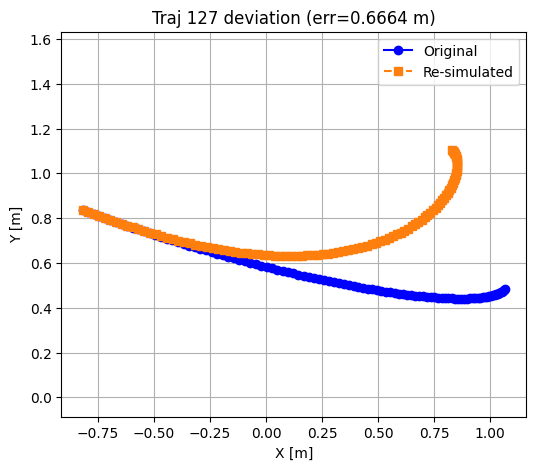

Trajectory 128 removed: max position error = 1.3134 m


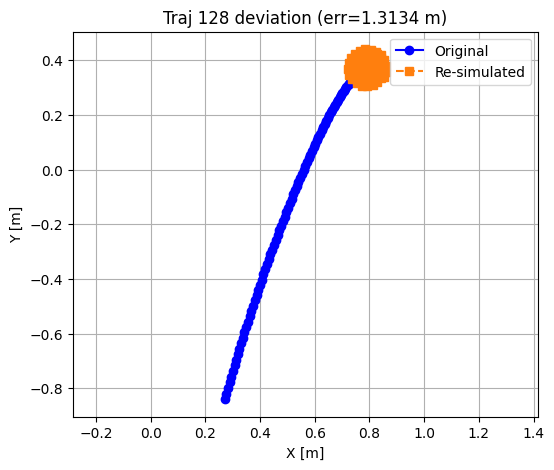

Trajectory 129 removed: max position error = 0.1239 m


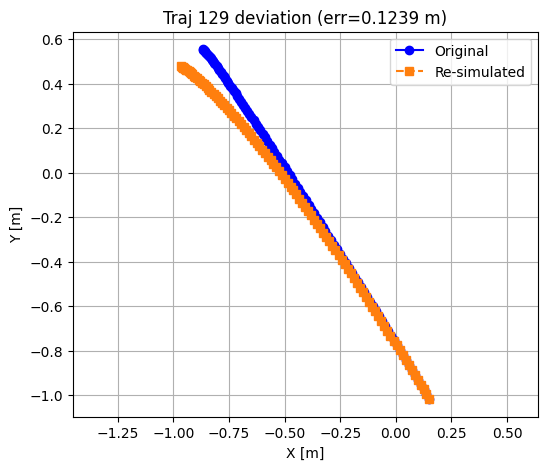

Trajectory 130 removed: max position error = 0.2038 m


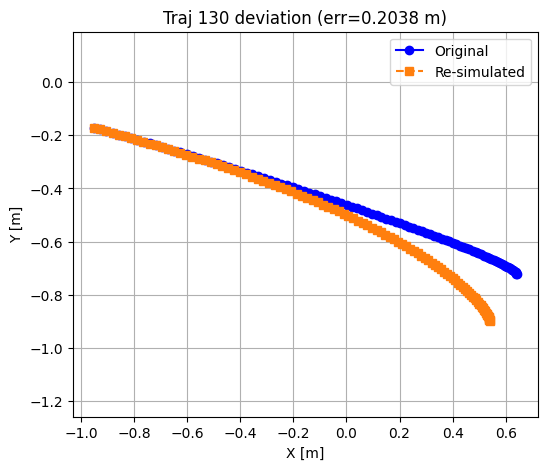

Trajectory 131 removed: max position error = 2.1097 m


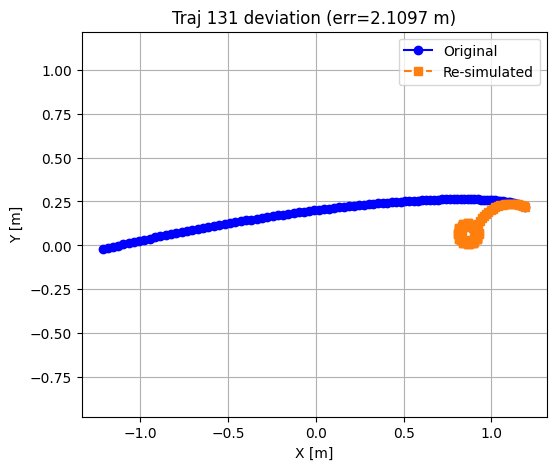

Trajectory 132 removed: max position error = 1.8827 m


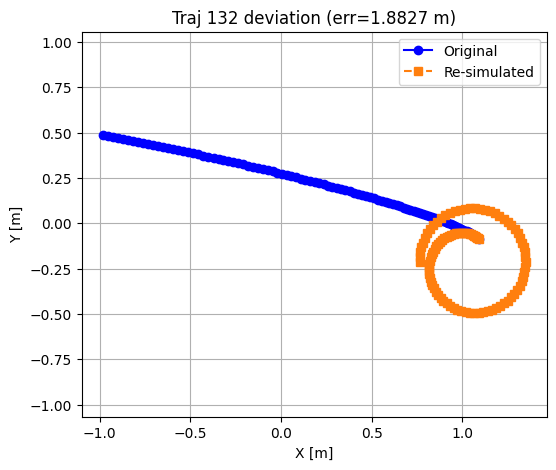

Trajectory 133 removed: max position error = 1.5969 m


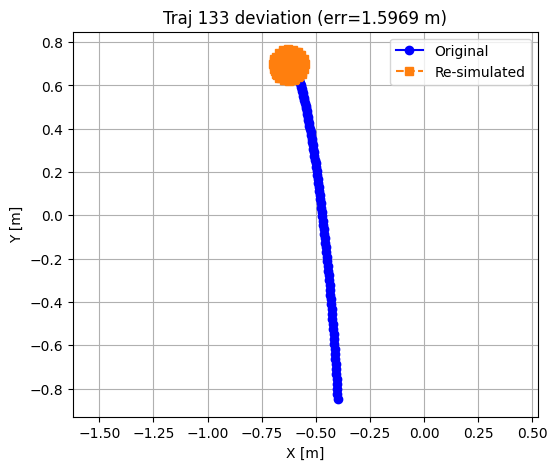

Trajectory 134 removed: max position error = 1.3855 m


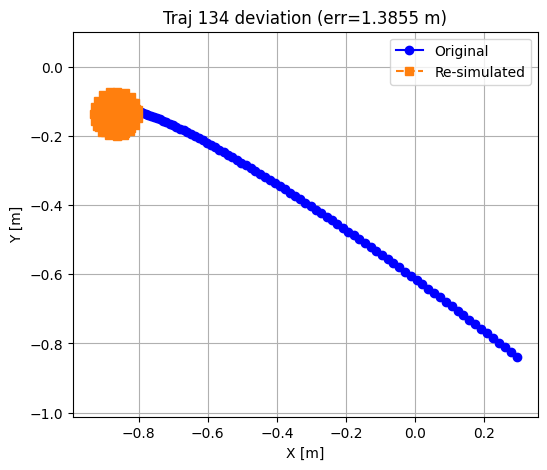

Trajectory 135 removed: max position error = 0.3590 m


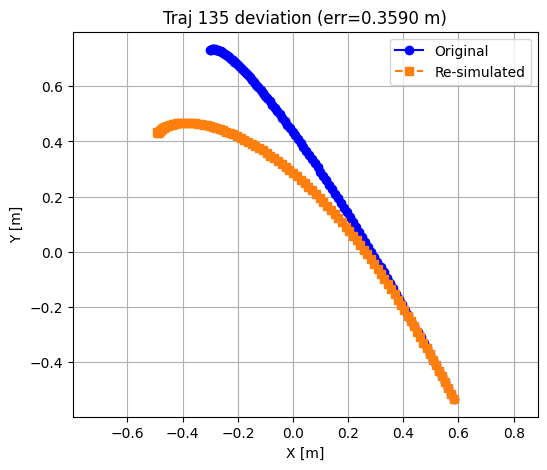

Trajectory 136 removed: max position error = 1.8740 m


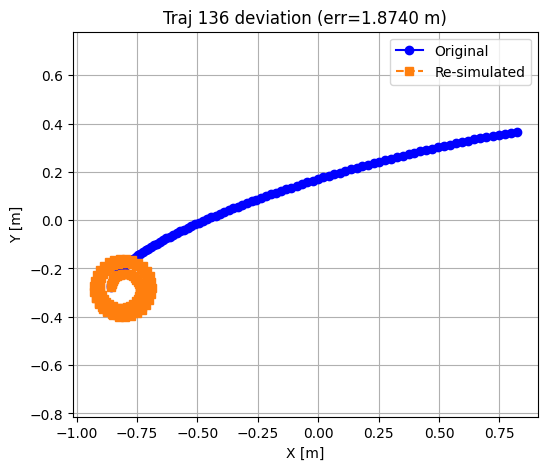

Trajectory 137 removed: max position error = 0.7454 m


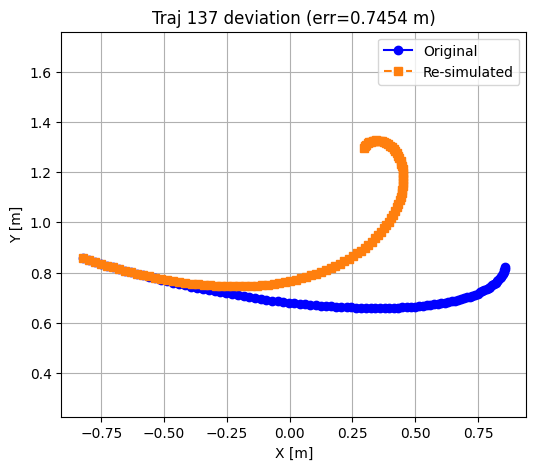

Trajectory 138 removed: max position error = 2.1239 m


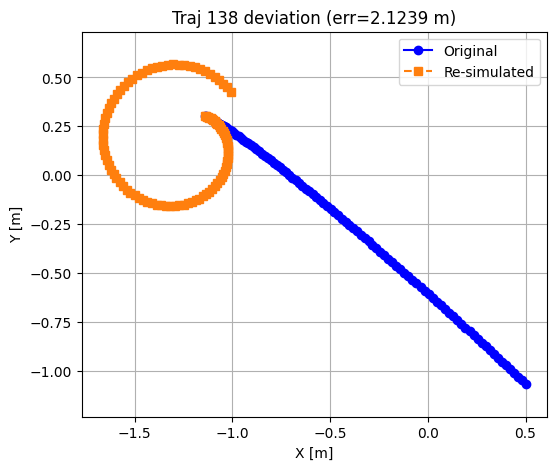

Trajectory 139 removed: max position error = 2.0981 m


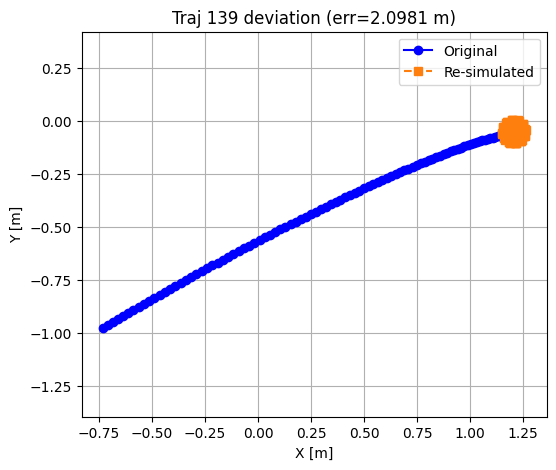

Trajectory 140 removed: max position error = 0.6139 m


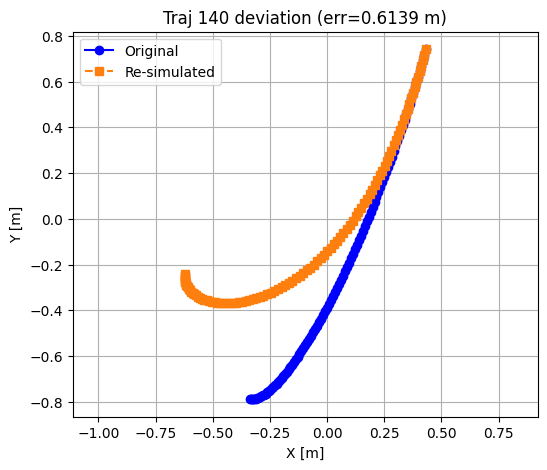

Trajectory 141 removed: max position error = 0.6073 m


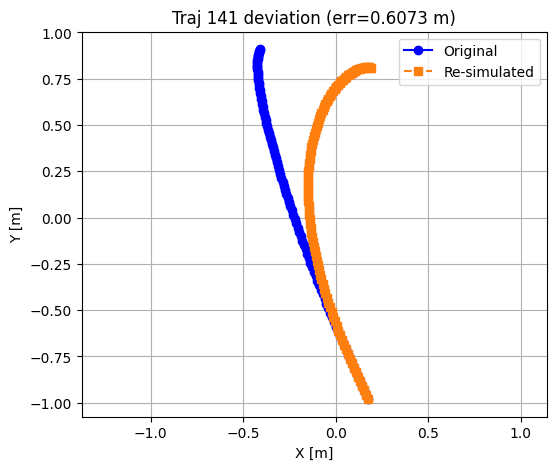

Trajectory 142 removed: max position error = 0.6727 m


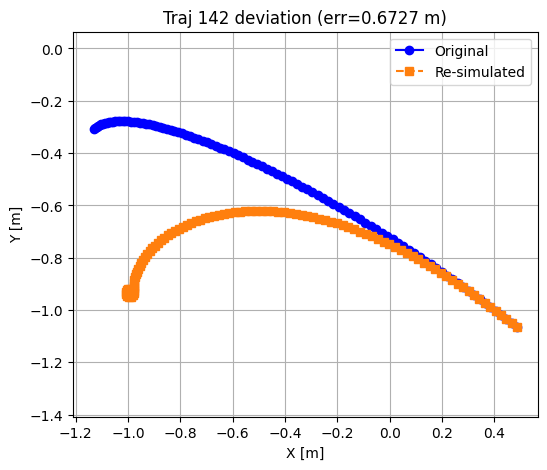

Trajectory 143 removed: max position error = 1.2414 m


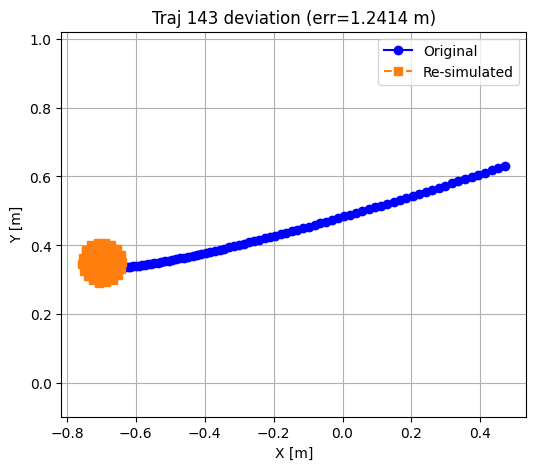

Trajectory 144 removed: max position error = 1.9683 m


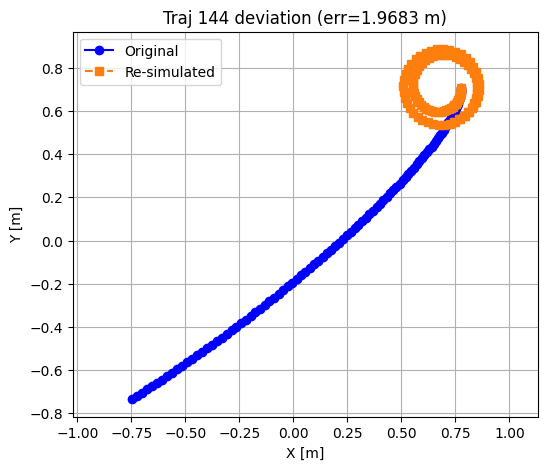

Trajectory 145 removed: max position error = 1.7360 m


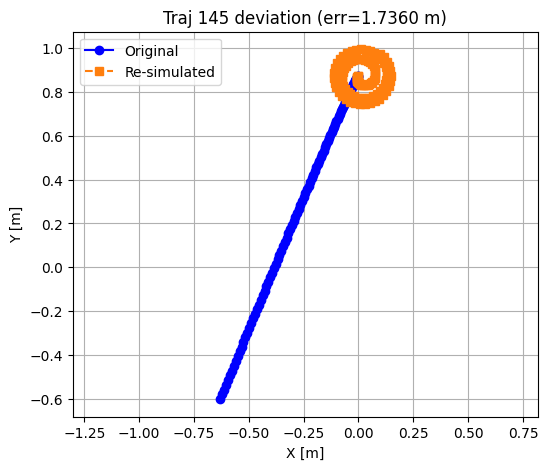

Trajectory 146 removed: max position error = 1.7715 m


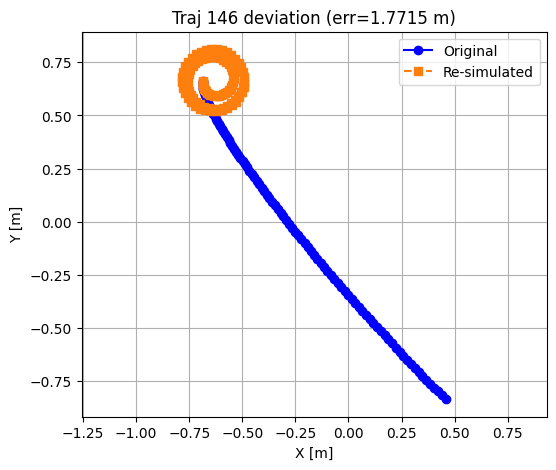

Trajectory 147 removed: max position error = 2.2602 m


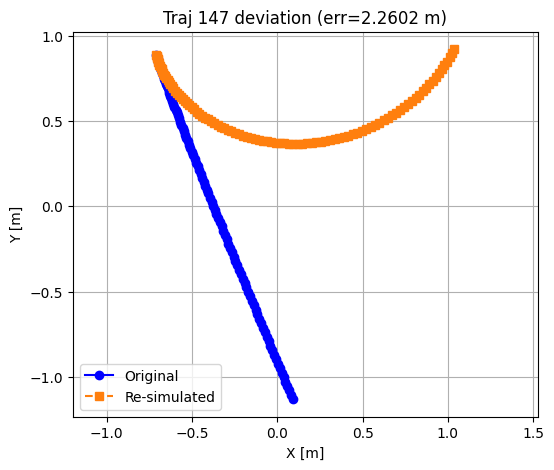

Trajectory 148 removed: max position error = 1.3044 m


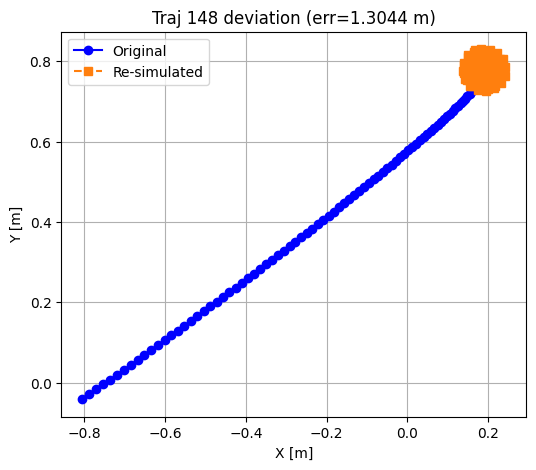

Trajectory 149 removed: max position error = 0.4906 m


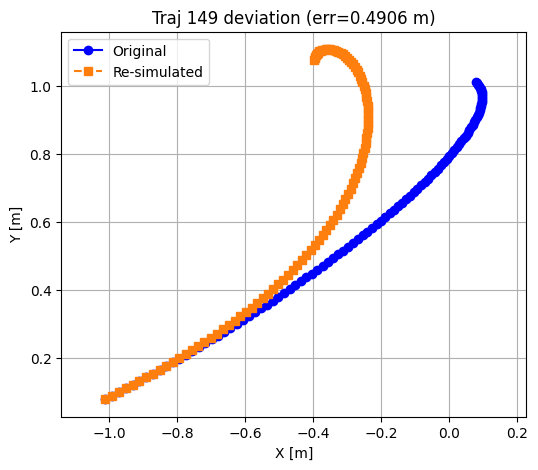

Trajectory 150 removed: max position error = 0.1870 m


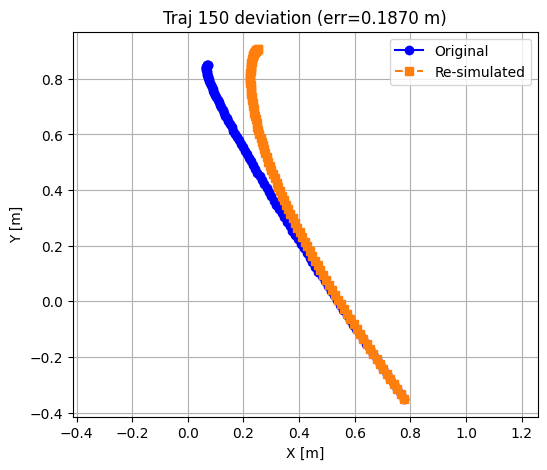

Trajectory 151 removed: max position error = 0.2118 m


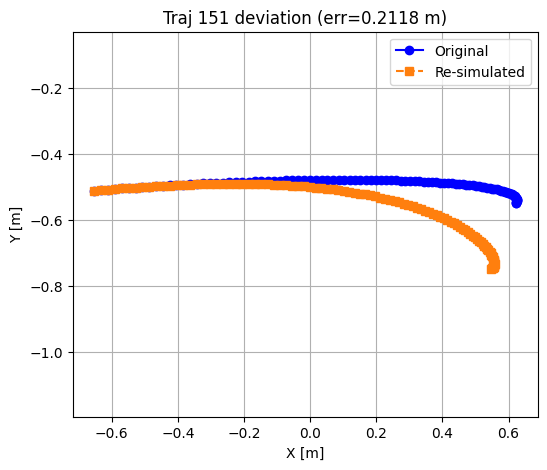

Trajectory 152 removed: max position error = 0.8240 m


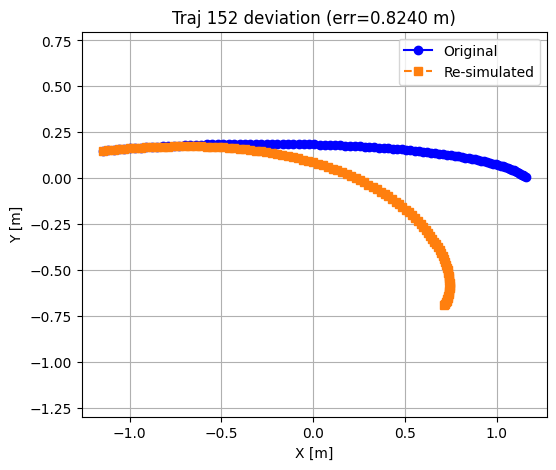

Trajectory 153 removed: max position error = 1.8115 m


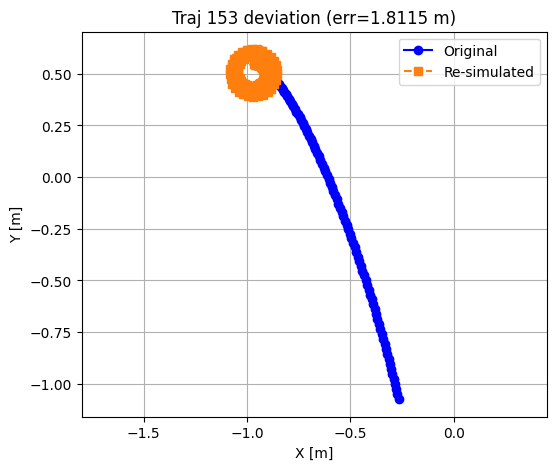

Trajectory 154 removed: max position error = 0.3804 m


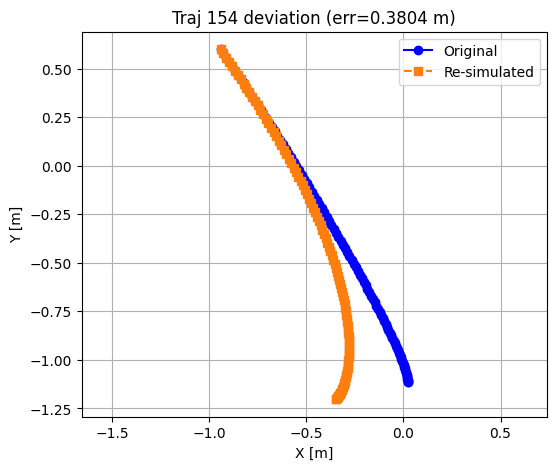

Trajectory 155 removed: max position error = 0.2967 m


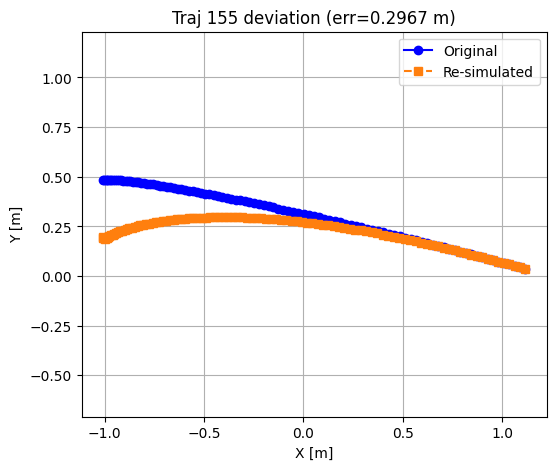

Trajectory 156 removed: max position error = 1.2940 m


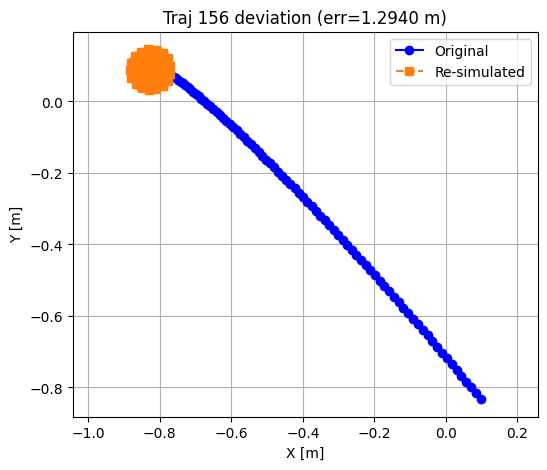

Trajectory 157 removed: max position error = 0.5885 m


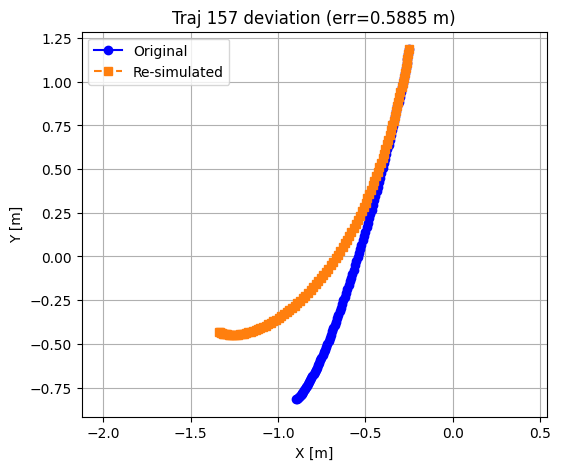

Trajectory 158 removed: max position error = 1.5114 m


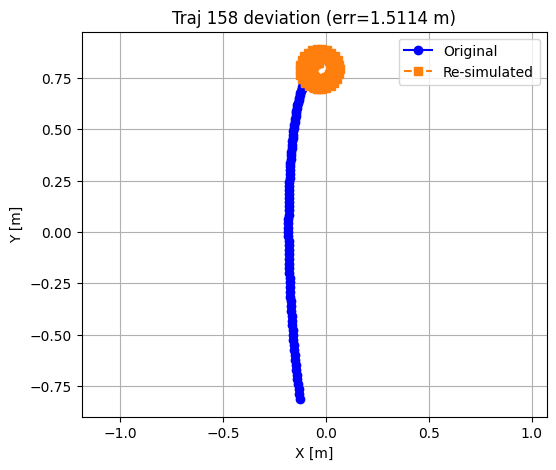

Trajectory 159 removed: max position error = 0.0854 m


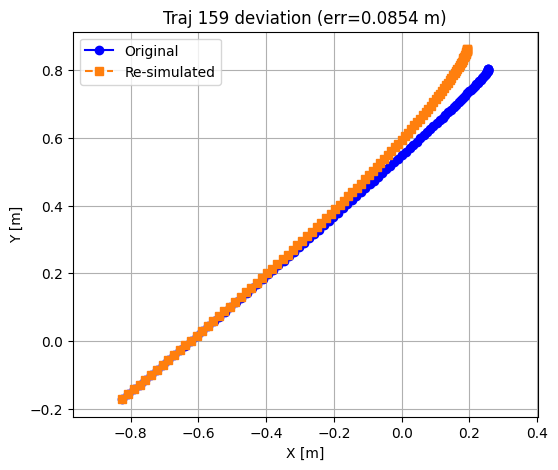

Trajectory 160 removed: max position error = 0.6950 m


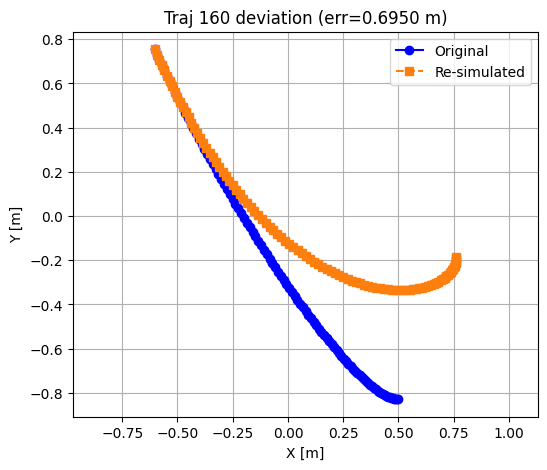

Trajectory 161 removed: max position error = 1.8074 m


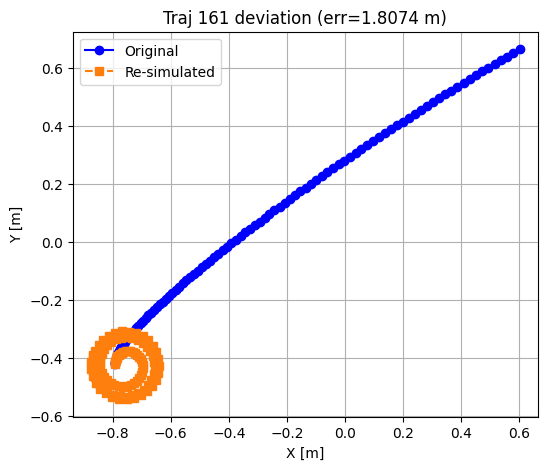

Trajectory 162 removed: max position error = 1.8398 m


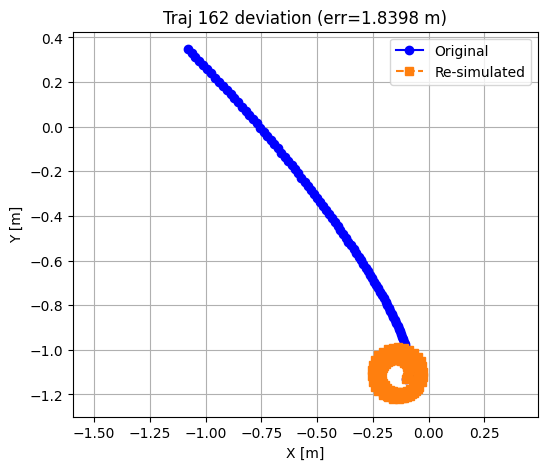

Trajectory 163 removed: max position error = 2.4756 m


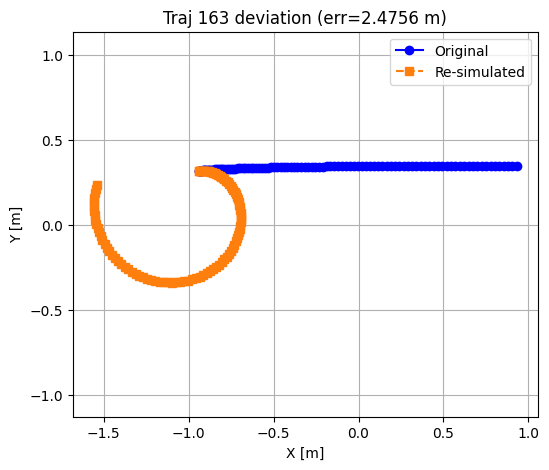

Trajectory 164 removed: max position error = 1.8897 m


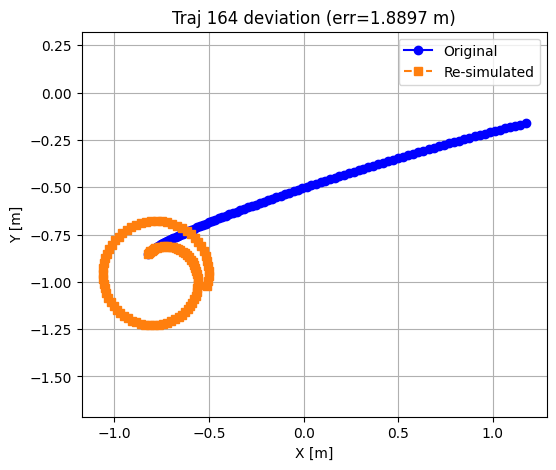

Trajectory 165 removed: max position error = 0.3569 m


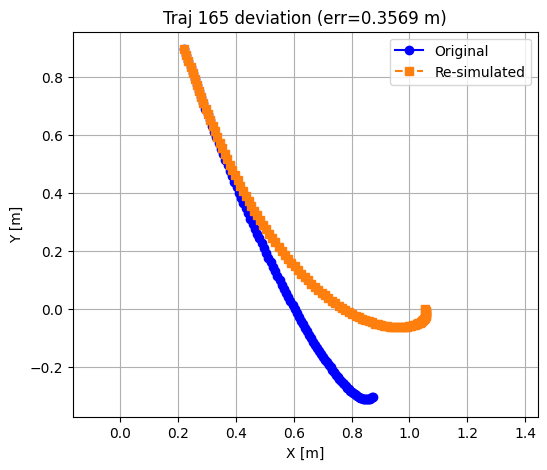

Trajectory 166 removed: max position error = 1.5675 m


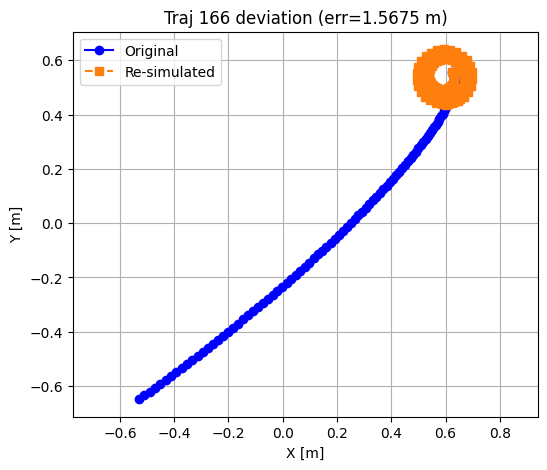

Trajectory 167 removed: max position error = 0.1858 m


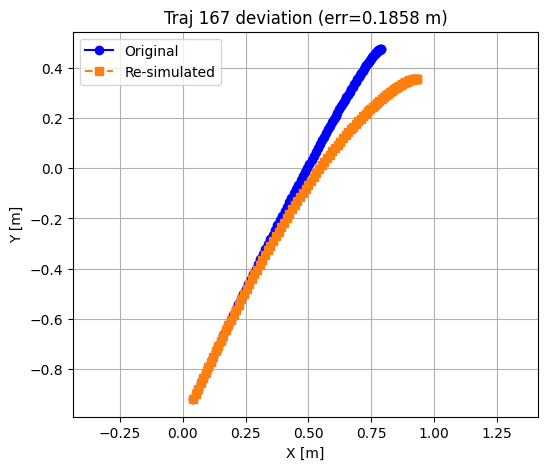

Trajectory 168 removed: max position error = 0.0836 m


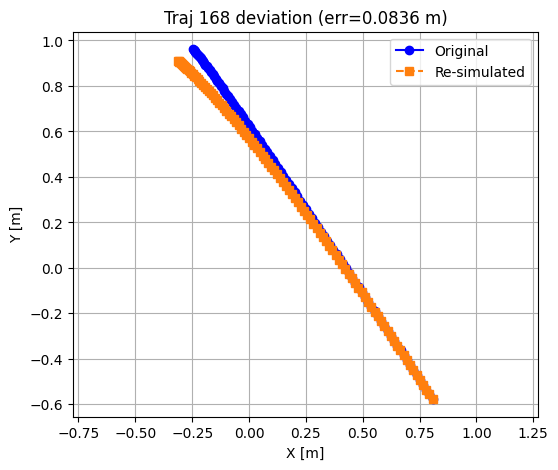

Trajectory 169 removed: max position error = 0.0926 m


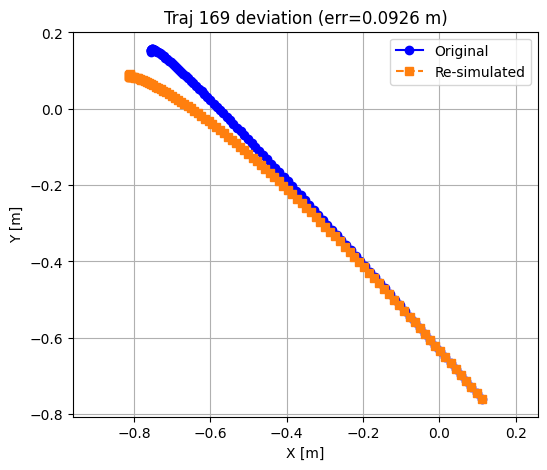

Trajectory 170 removed: max position error = 0.2896 m


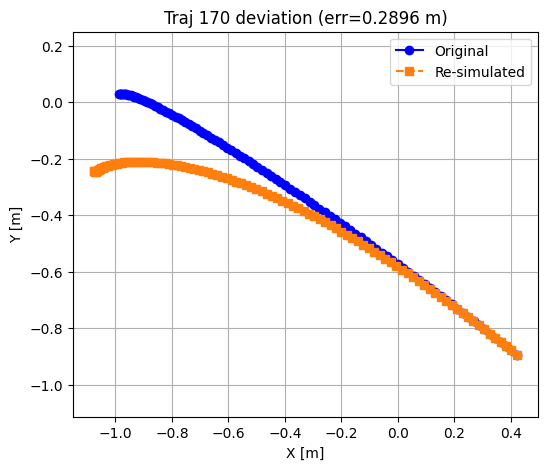

Trajectory 171 removed: max position error = 1.8181 m


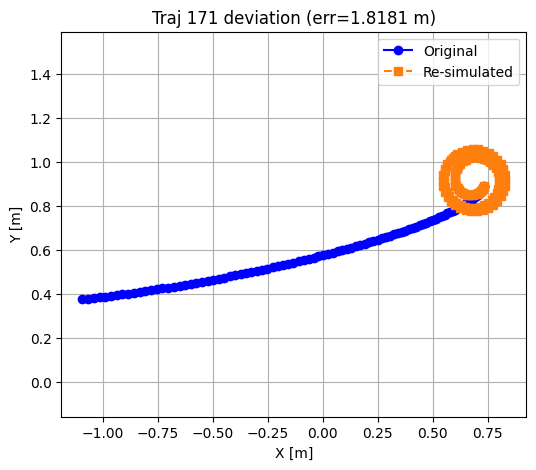

Trajectory 172 removed: max position error = 1.6918 m


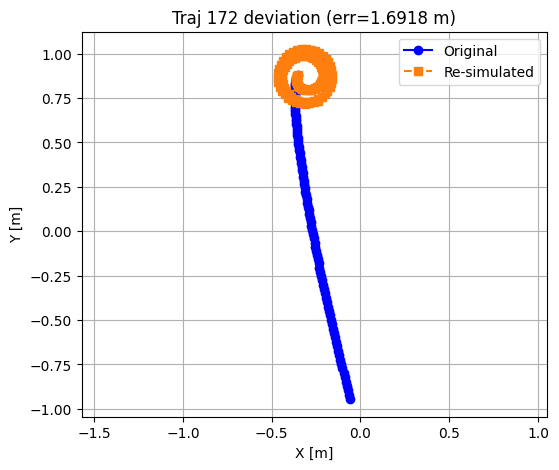

Trajectory 173 removed: max position error = 0.9428 m


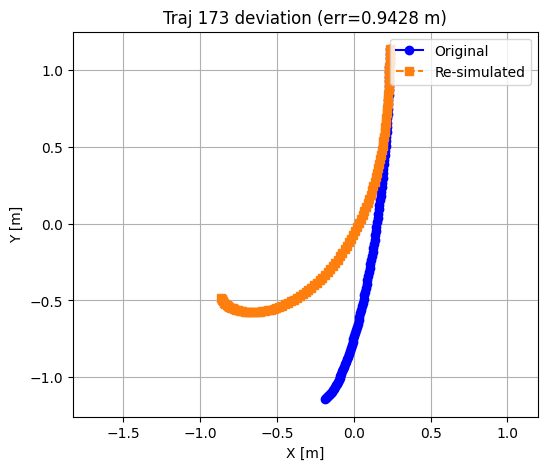

Trajectory 174 removed: max position error = 0.0767 m


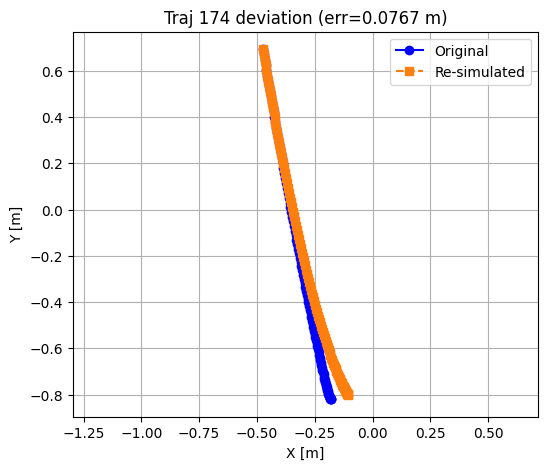

Trajectory 175 removed: max position error = 0.0786 m


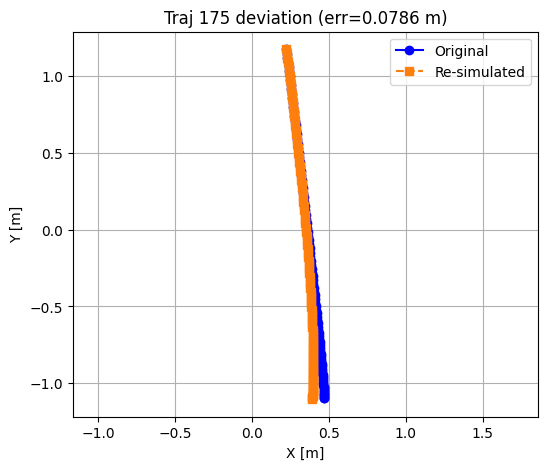

Trajectory 176 removed: max position error = 2.3758 m


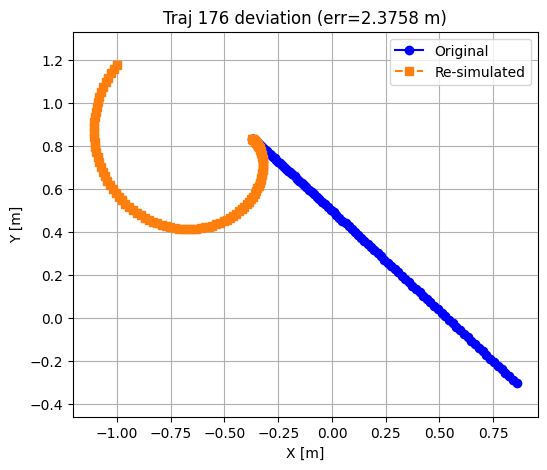

Trajectory 177 removed: max position error = 0.7320 m


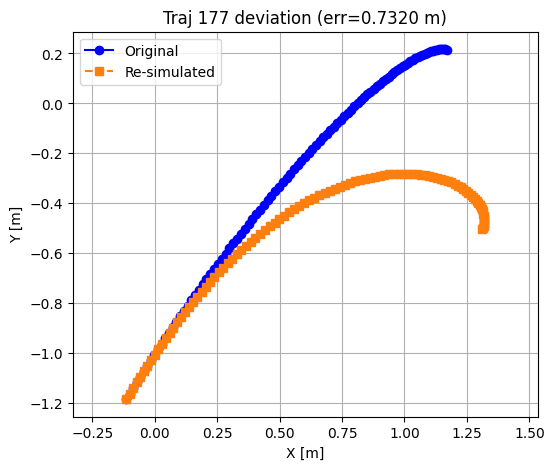

Trajectory 178 removed: max position error = 0.2172 m


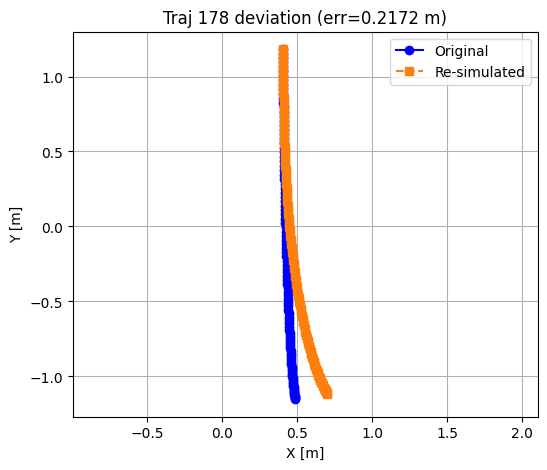

Trajectory 179 removed: max position error = 0.5541 m


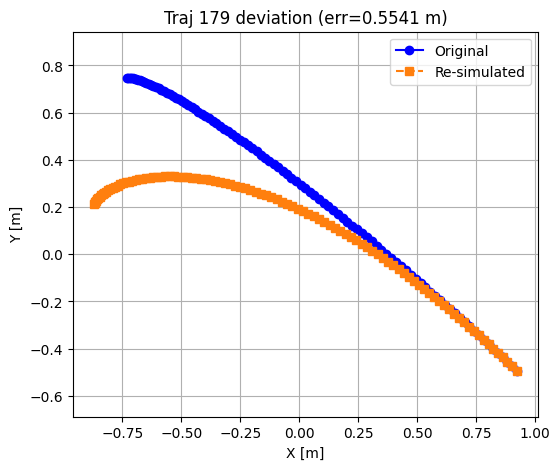

Trajectory 180 removed: max position error = 2.0725 m


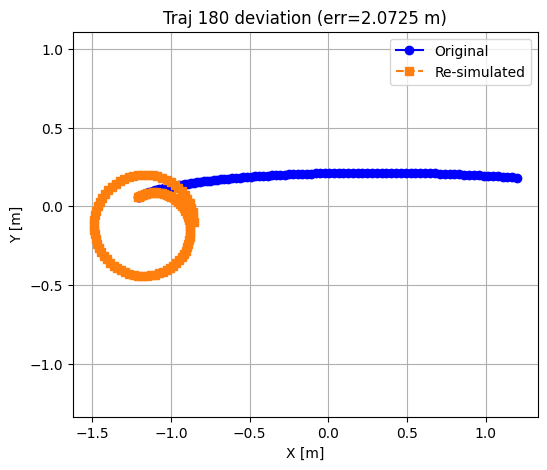

Trajectory 181 removed: max position error = 1.9213 m


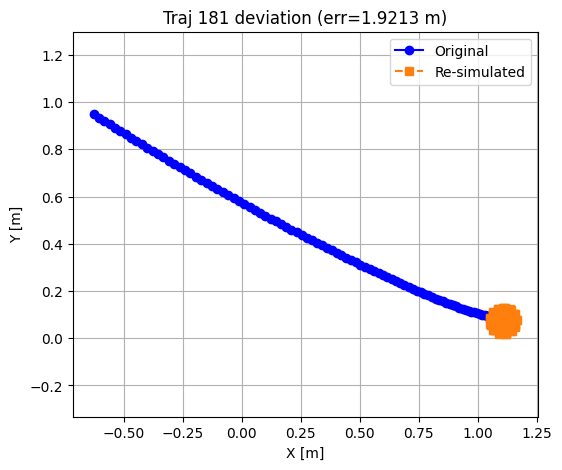

Trajectory 182 removed: max position error = 0.1107 m


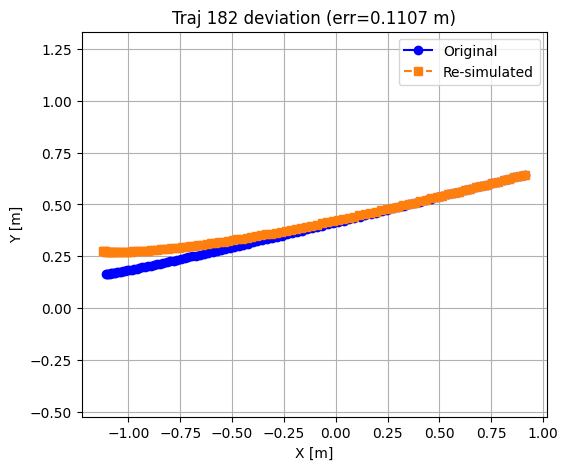

Trajectory 183 removed: max position error = 1.3997 m


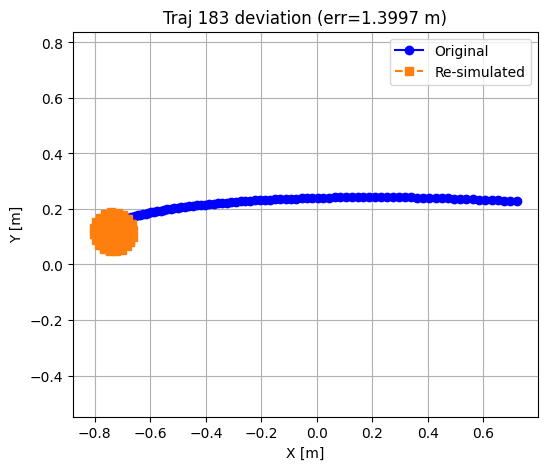

Trajectory 184 removed: max position error = 0.2531 m


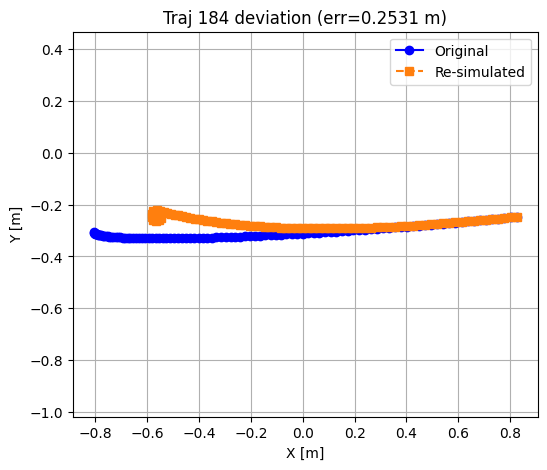

Trajectory 185 removed: max position error = 0.1352 m


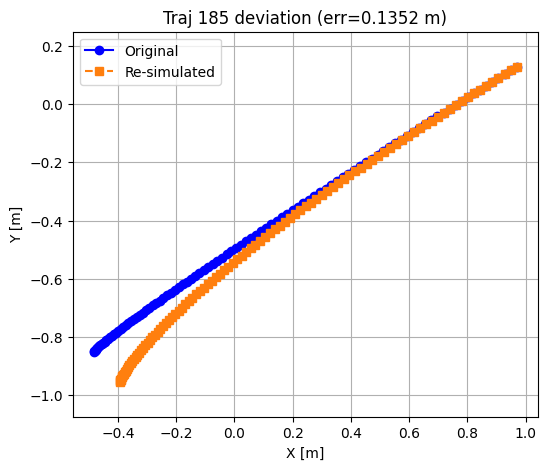

Trajectory 186 removed: max position error = 0.4431 m


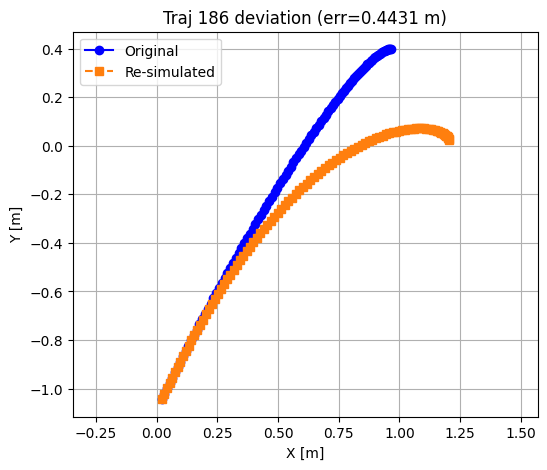

Trajectory 187 removed: max position error = 0.6929 m


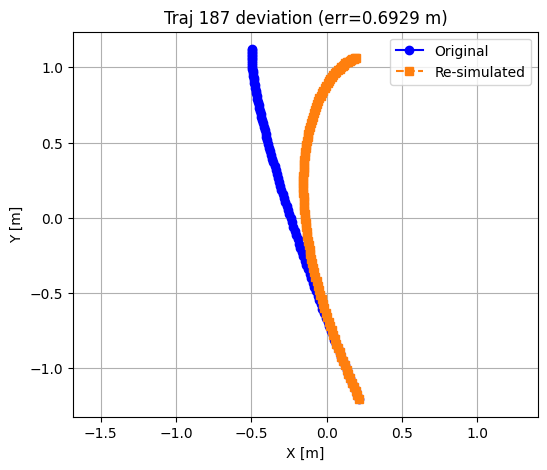

Trajectory 188 removed: max position error = 0.3773 m


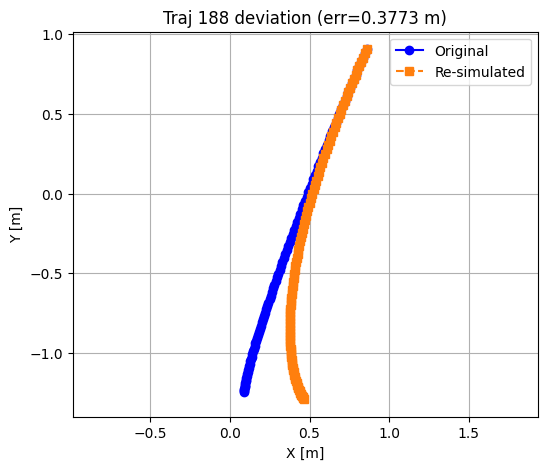

Trajectory 189 removed: max position error = 0.1091 m


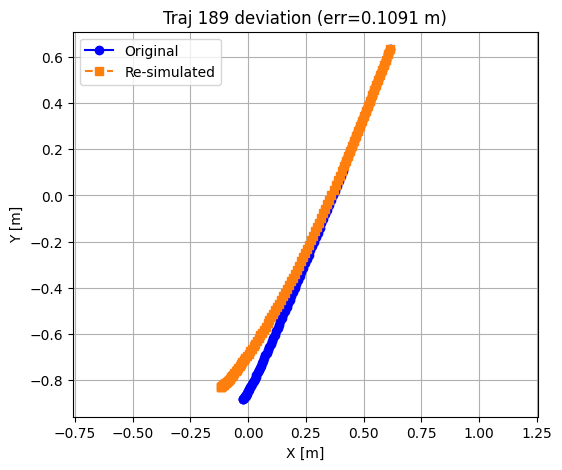

Trajectory 190 removed: max position error = 1.4041 m


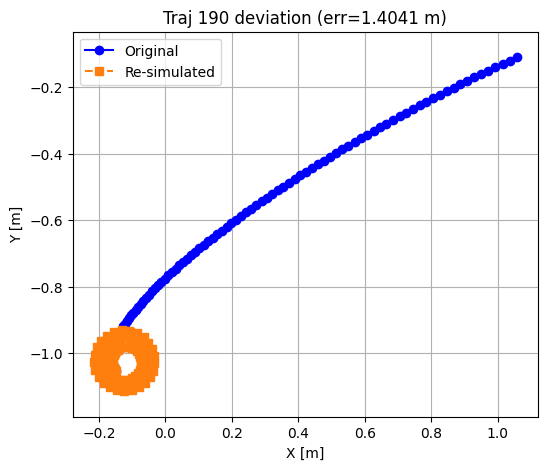

Trajectory 191 removed: max position error = 0.9495 m


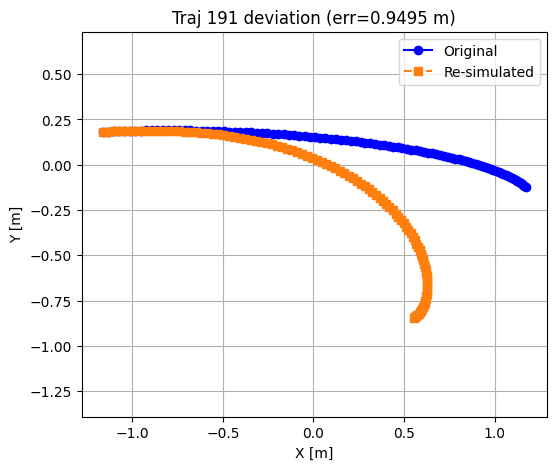

Trajectory 192 removed: max position error = 0.5490 m


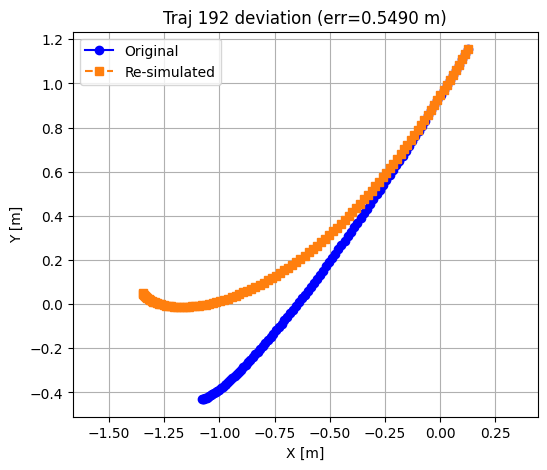

Trajectory 193 removed: max position error = 1.7991 m


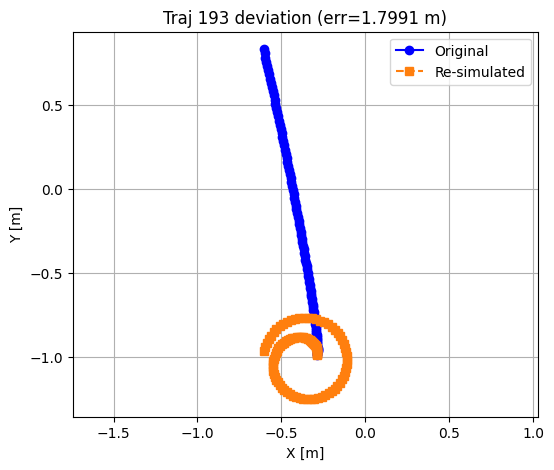

Trajectory 194 removed: max position error = 1.6076 m


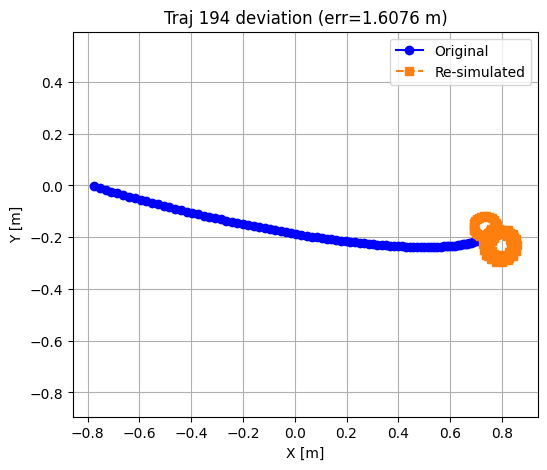

Trajectory 195 removed: max position error = 0.2313 m


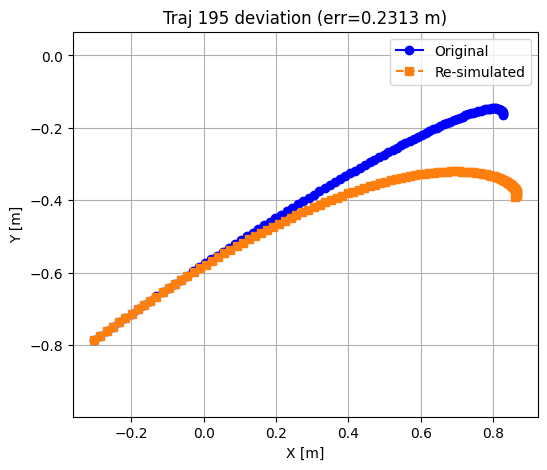

Trajectory 196 removed: max position error = 1.4021 m


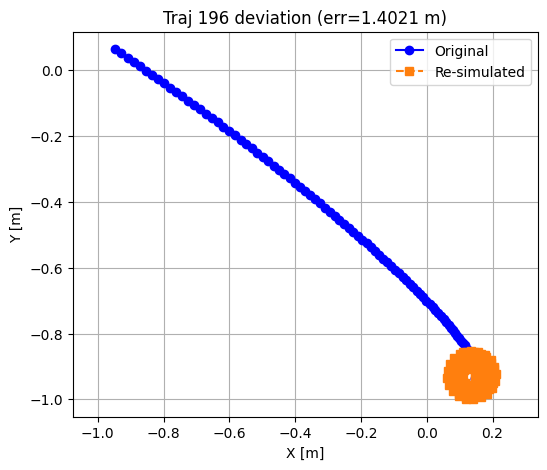

Trajectory 197 removed: max position error = 0.0706 m


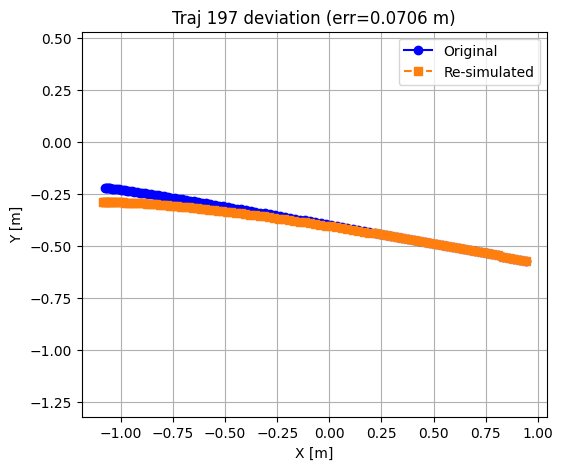

Trajectory 198 removed: max position error = 0.6570 m


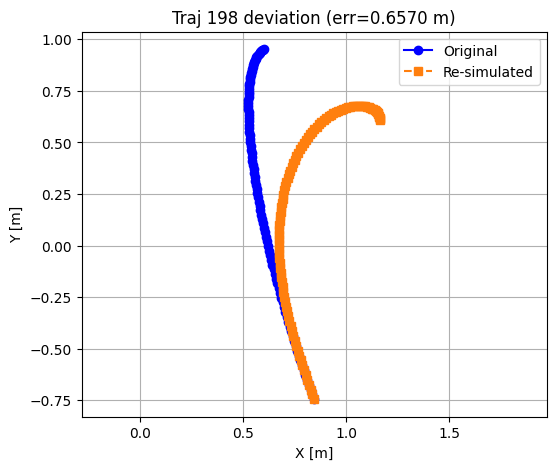

Trajectory 199 removed: max position error = 1.9009 m


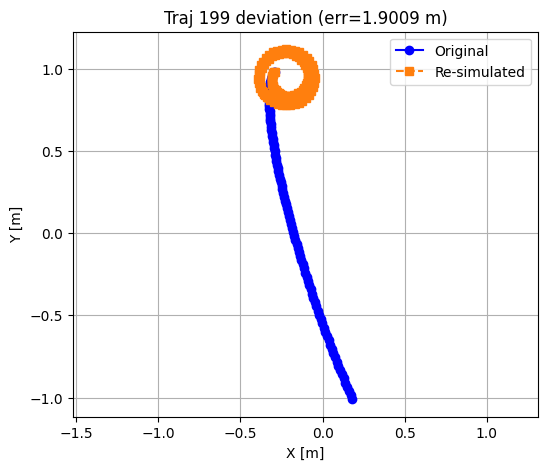

Trajectory 200 removed: max position error = 0.2502 m


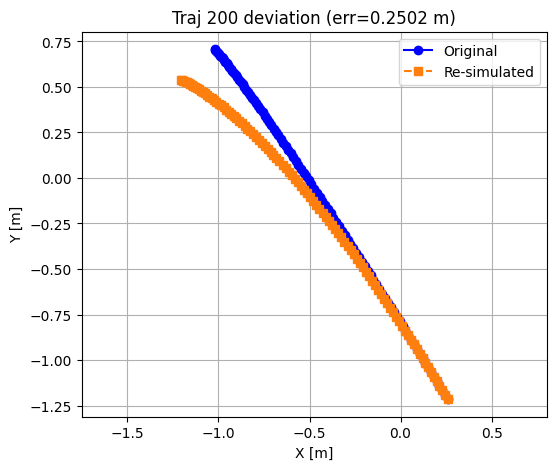

Trajectory 201 removed: max position error = 0.1075 m


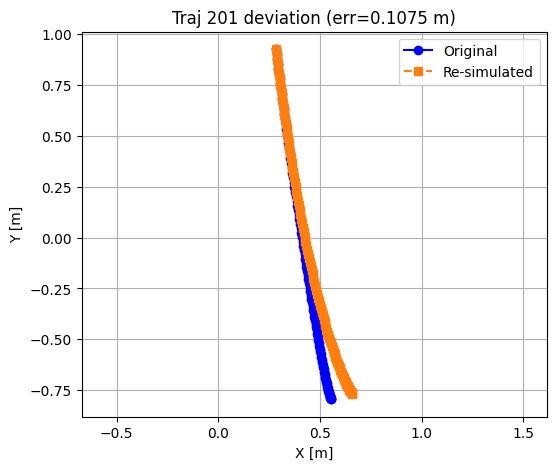

Trajectory 202 removed: max position error = 0.0441 m


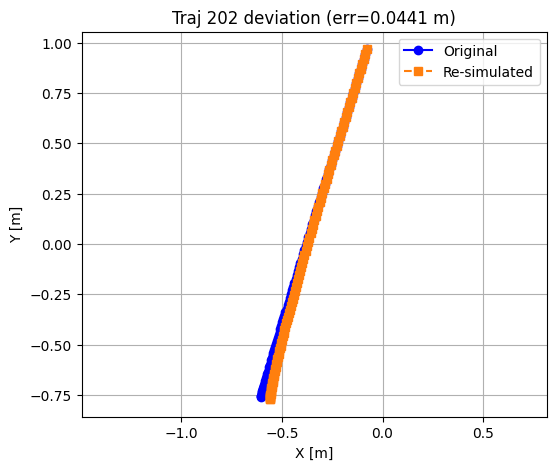

Trajectory 203 removed: max position error = 0.7339 m


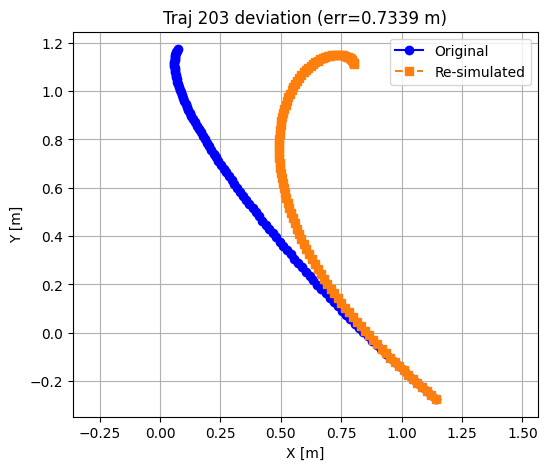

Trajectory 204 removed: max position error = 1.1518 m


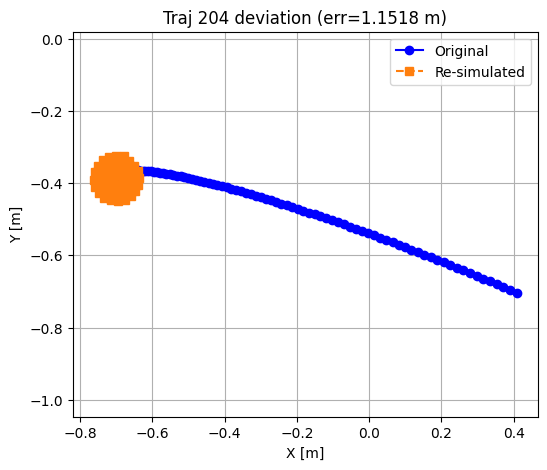

Trajectory 205 removed: max position error = 1.7285 m


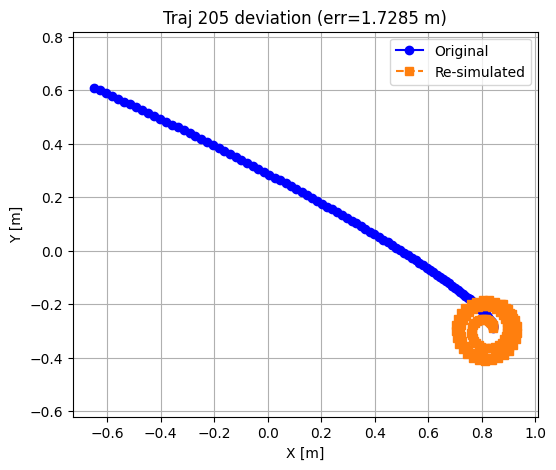

Trajectory 206 removed: max position error = 1.2675 m


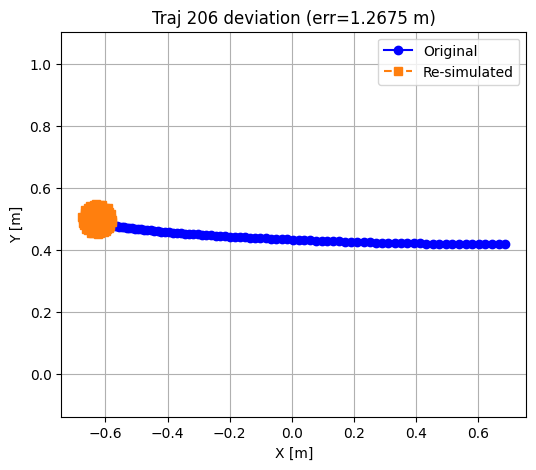

Trajectory 207 removed: max position error = 2.3793 m


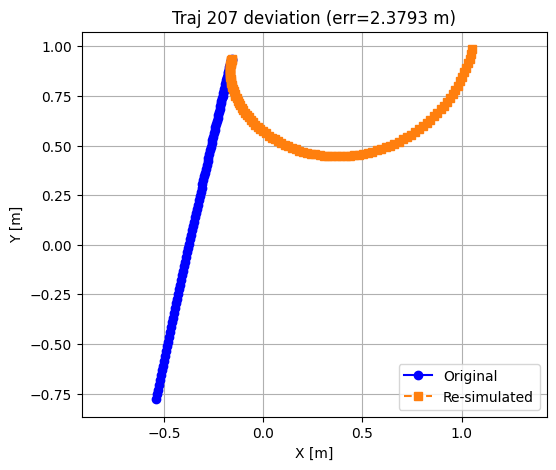

Trajectory 208 removed: max position error = 1.2174 m


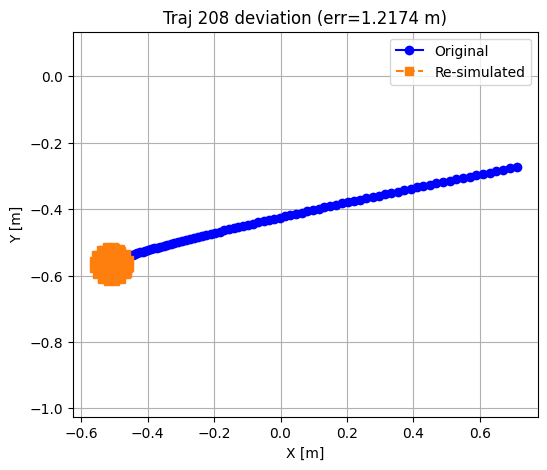

Trajectory 209 removed: max position error = 2.3365 m


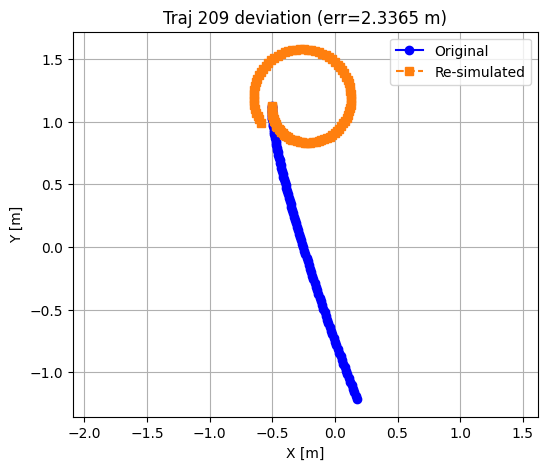

Trajectory 210 removed: max position error = 1.7541 m


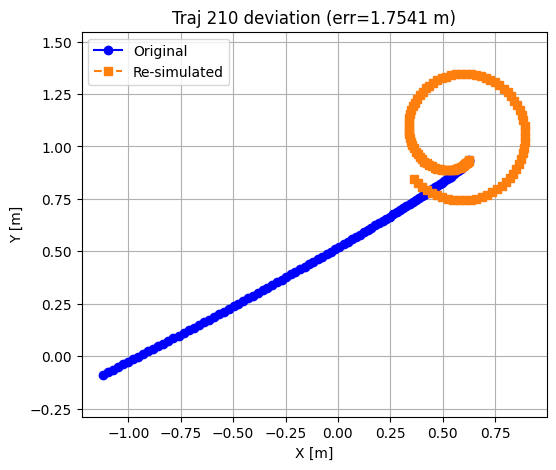

Trajectory 211 removed: max position error = 0.7074 m


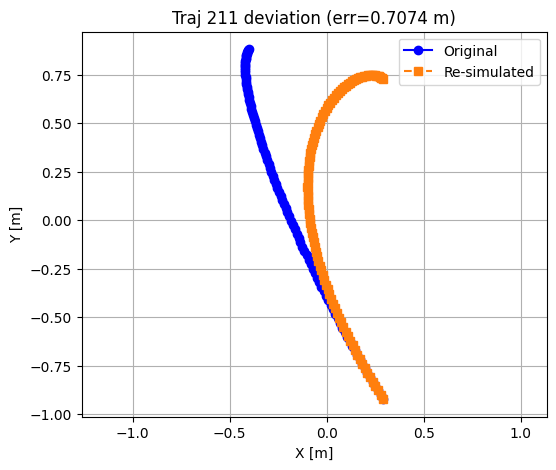

Trajectory 212 removed: max position error = 1.7917 m


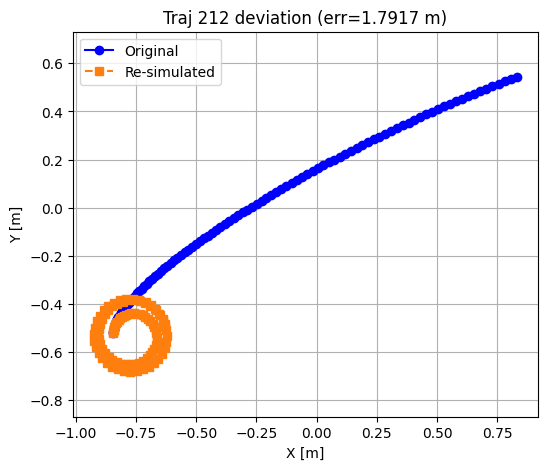

Trajectory 213 removed: max position error = 0.2703 m


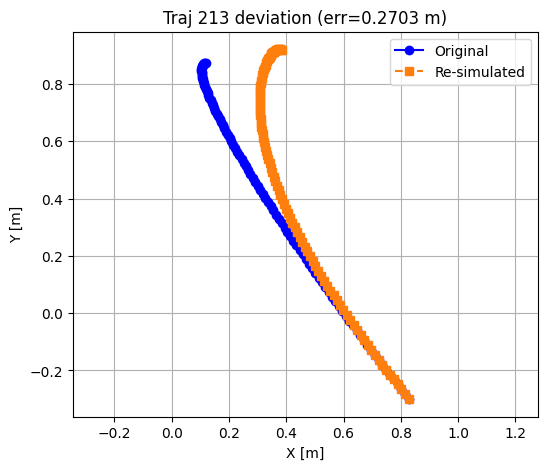

Trajectory 214 removed: max position error = 1.7581 m


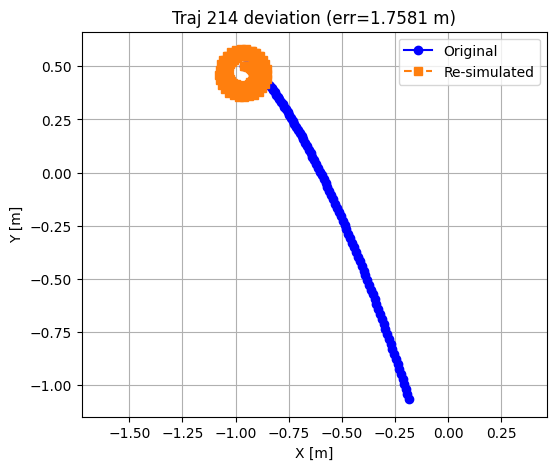

Trajectory 215 removed: max position error = 0.6840 m


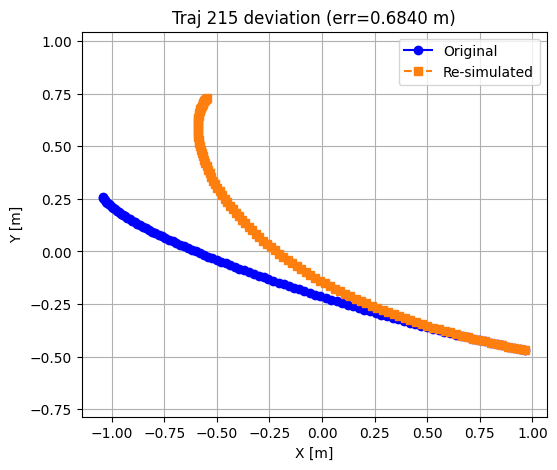

Trajectory 216 removed: max position error = 0.3029 m


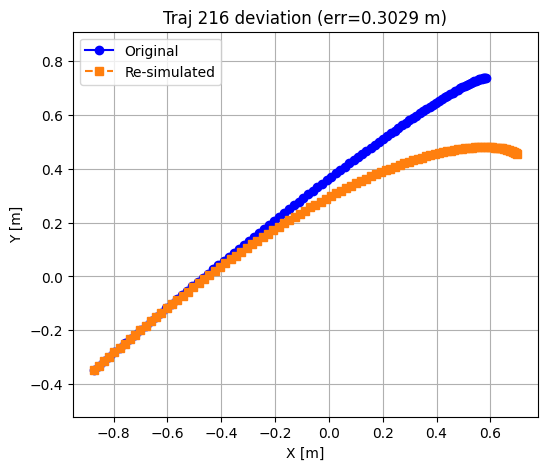

Trajectory 217 removed: max position error = 2.1076 m


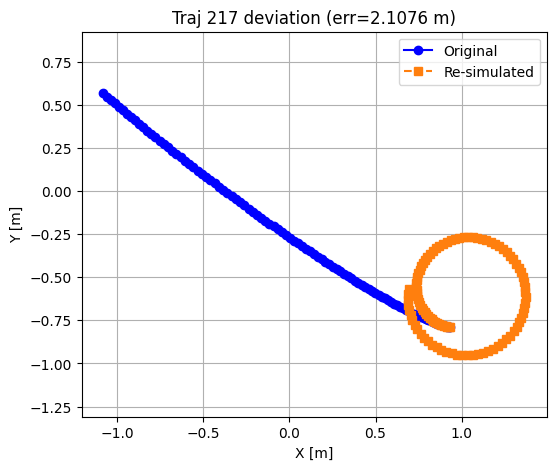

Trajectory 218 removed: max position error = 0.4941 m


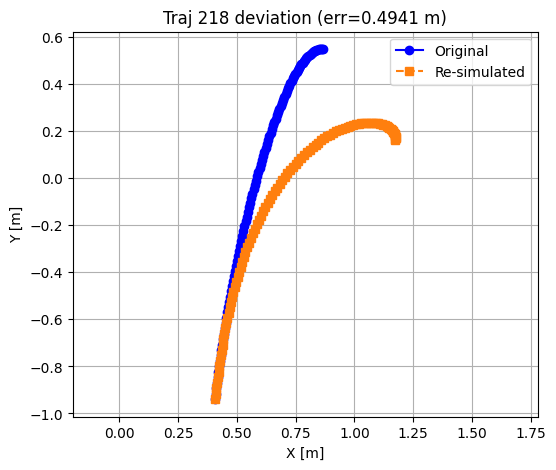

Trajectory 219 removed: max position error = 0.1317 m


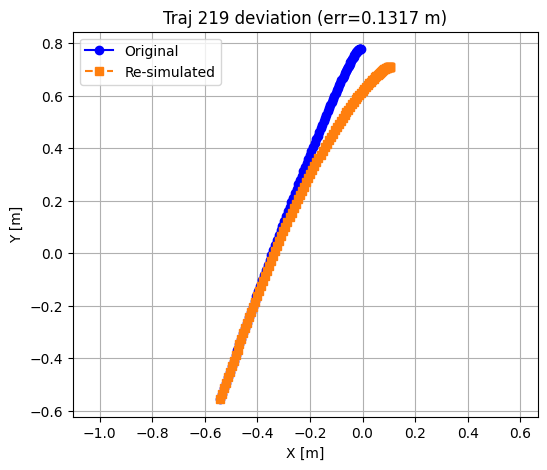

Trajectory 220 removed: max position error = 0.9413 m


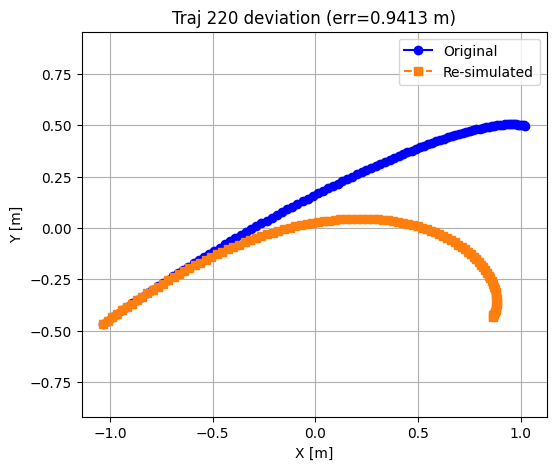

Trajectory 222 removed: max position error = 0.2948 m


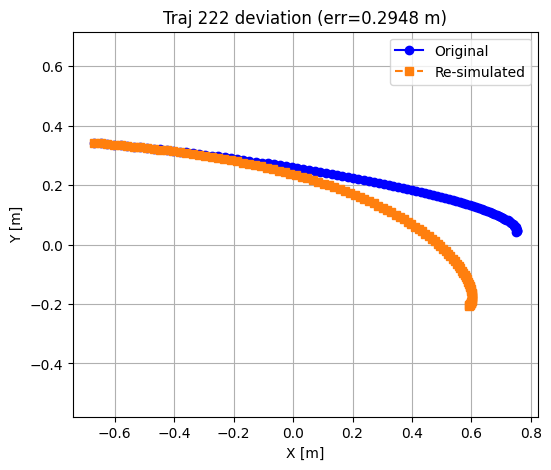

Trajectory 223 removed: max position error = 0.1307 m


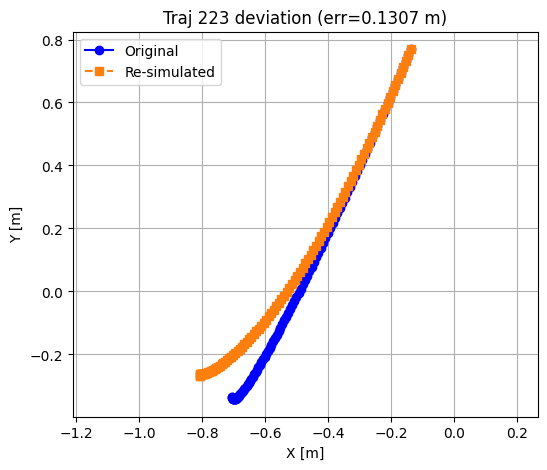

Trajectory 224 removed: max position error = 1.9007 m


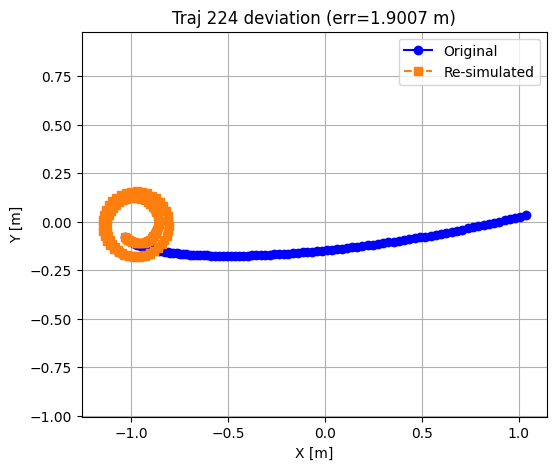

Trajectory 225 removed: max position error = 1.8817 m


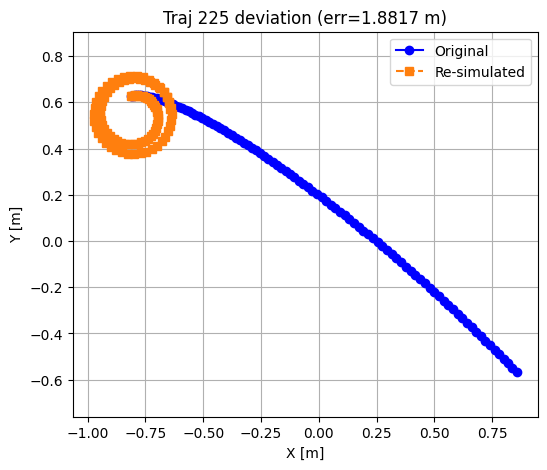

Trajectory 226 removed: max position error = 1.7589 m


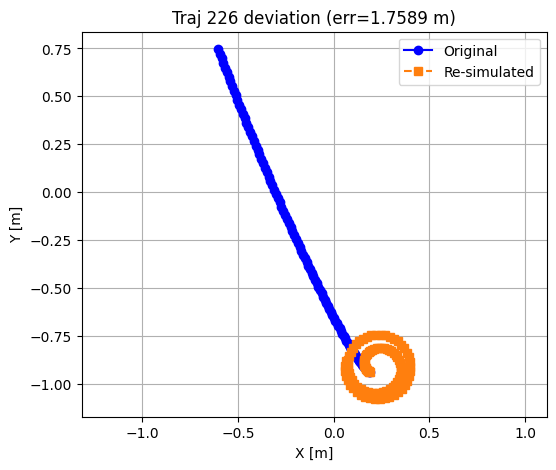

Trajectory 227 removed: max position error = 0.2571 m


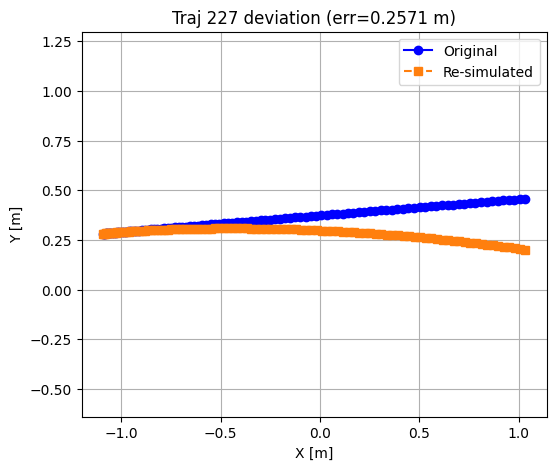

Trajectory 228 removed: max position error = 0.3913 m


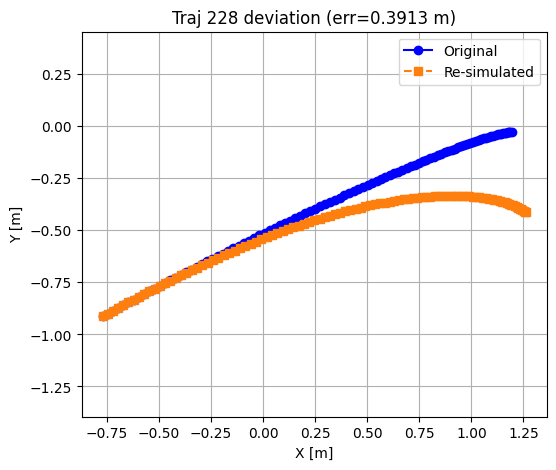

Trajectory 229 removed: max position error = 0.5000 m


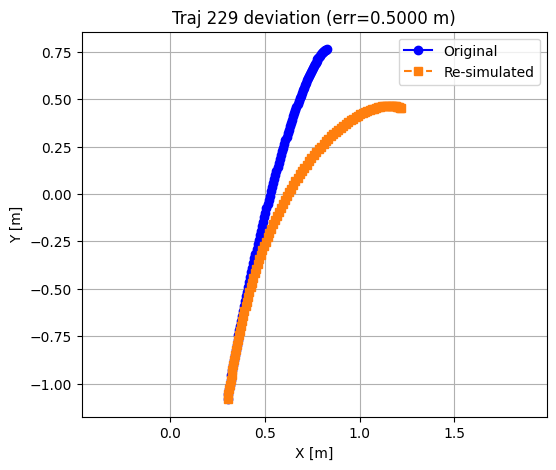

Trajectory 230 removed: max position error = 0.4532 m


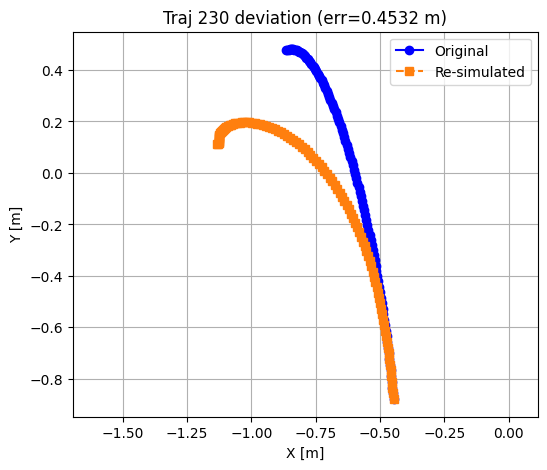

Trajectory 231 removed: max position error = 0.6540 m


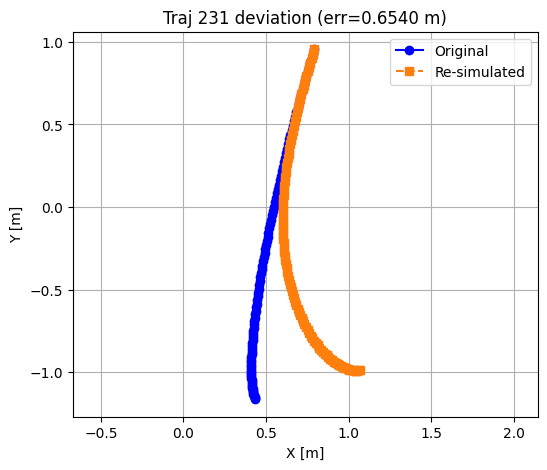

Trajectory 232 removed: max position error = 0.5633 m


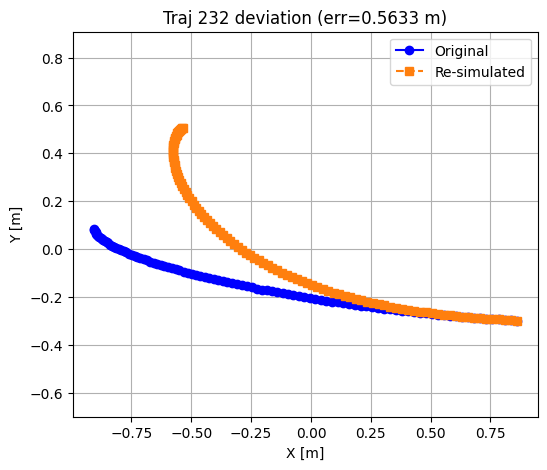

Trajectory 233 removed: max position error = 1.8878 m


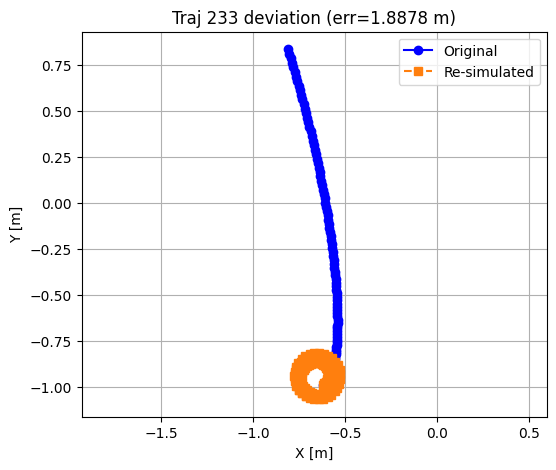

Trajectory 234 removed: max position error = 0.3139 m


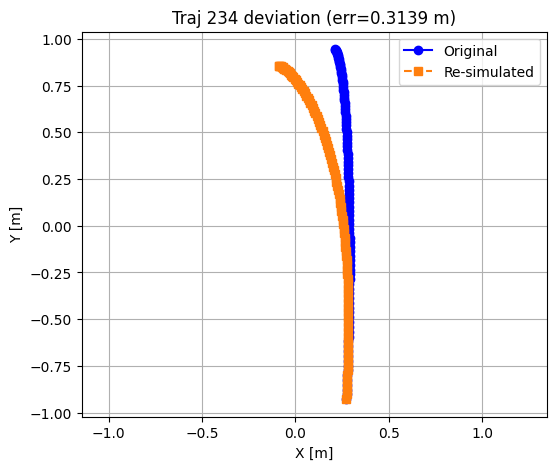

Trajectory 235 removed: max position error = 1.4795 m


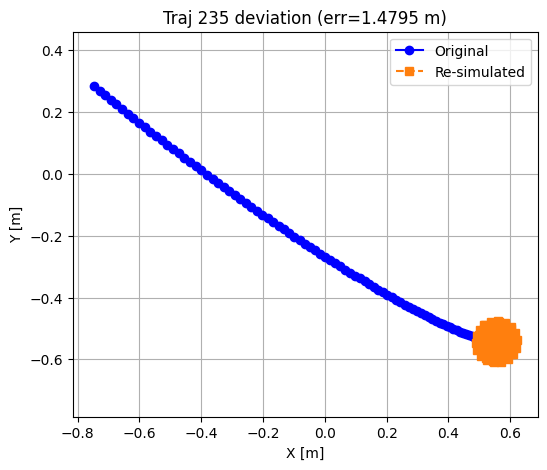

Trajectory 236 removed: max position error = 0.5498 m


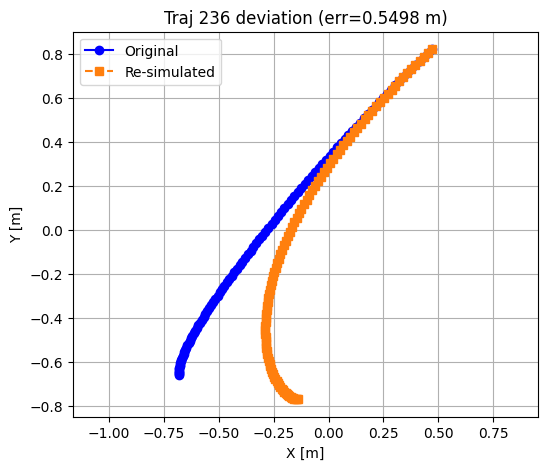

Trajectory 237 removed: max position error = 2.4150 m


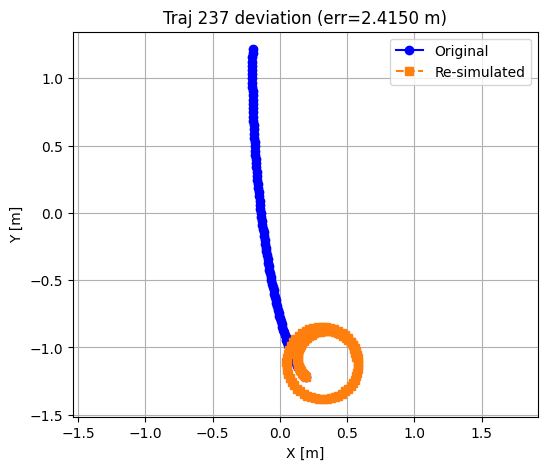

Trajectory 238 removed: max position error = 1.5554 m


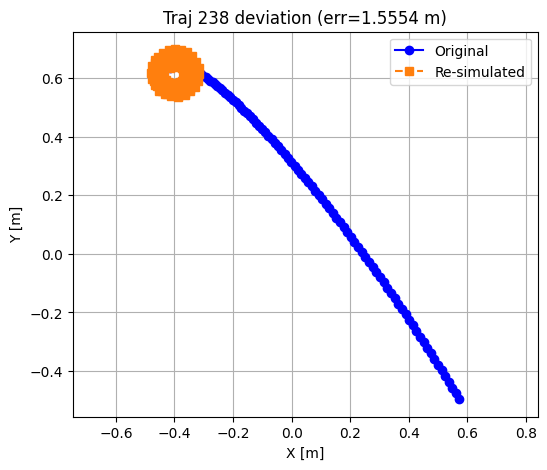

Trajectory 239 removed: max position error = 1.8443 m


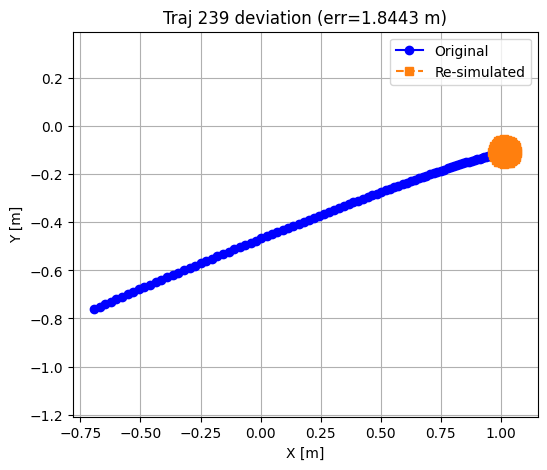

Trajectory 240 removed: max position error = 0.5891 m


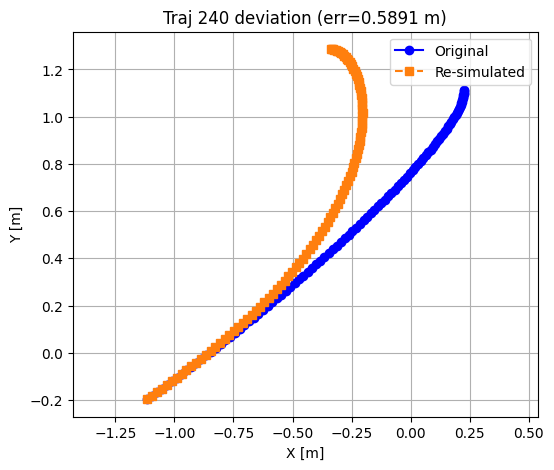

Trajectory 241 removed: max position error = 0.7832 m


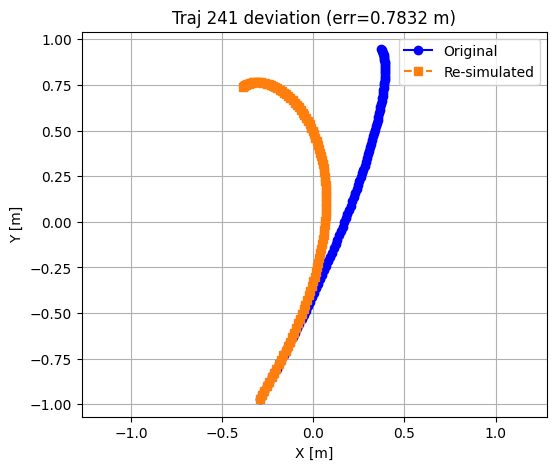

Trajectory 242 removed: max position error = 1.5319 m


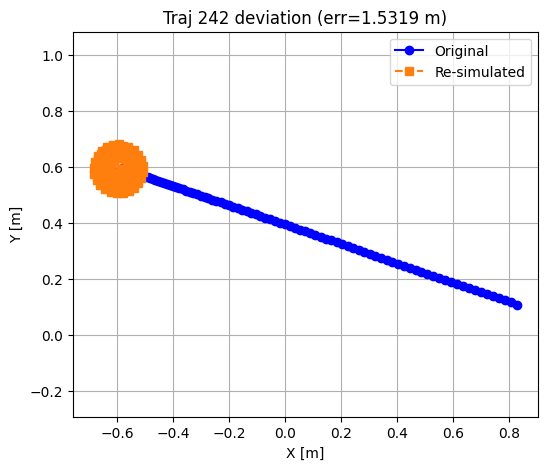

Trajectory 243 removed: max position error = 1.8636 m


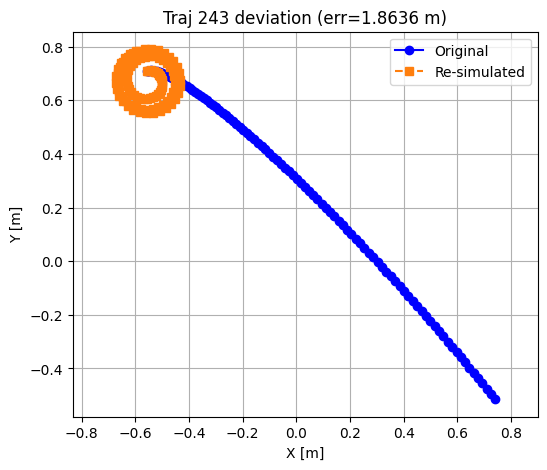

Trajectory 244 removed: max position error = 0.4082 m


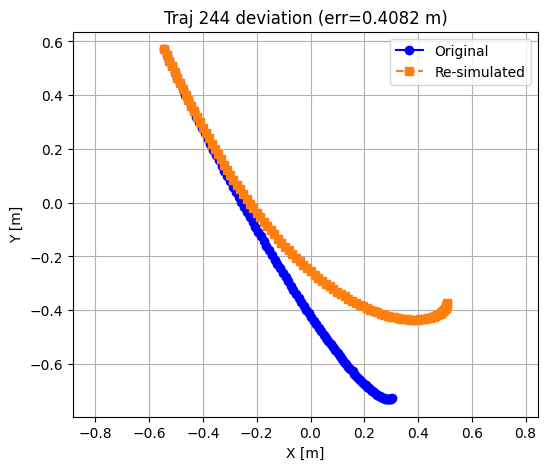

Trajectory 245 removed: max position error = 0.0523 m


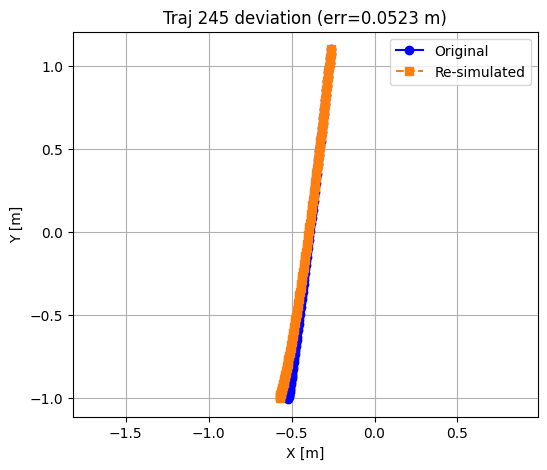

Trajectory 246 removed: max position error = 0.5420 m


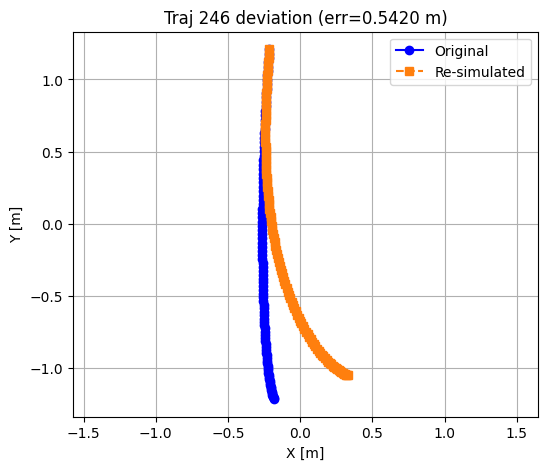

Trajectory 247 removed: max position error = 1.6682 m


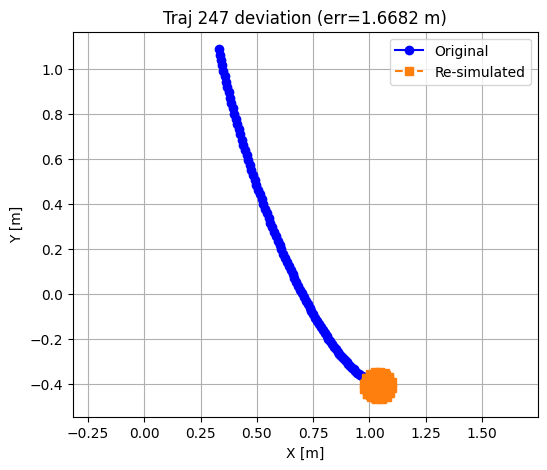

Trajectory 248 removed: max position error = 1.3061 m


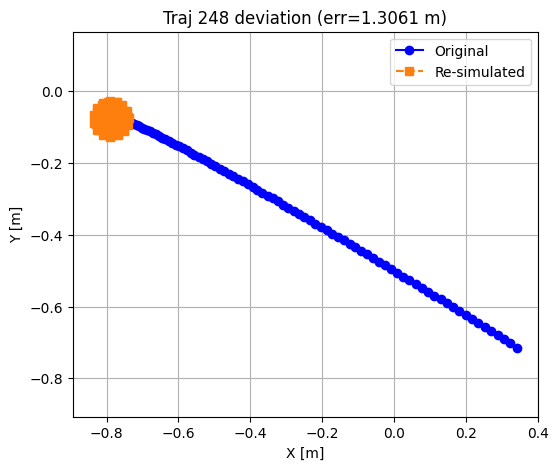

Trajectory 249 removed: max position error = 0.0813 m


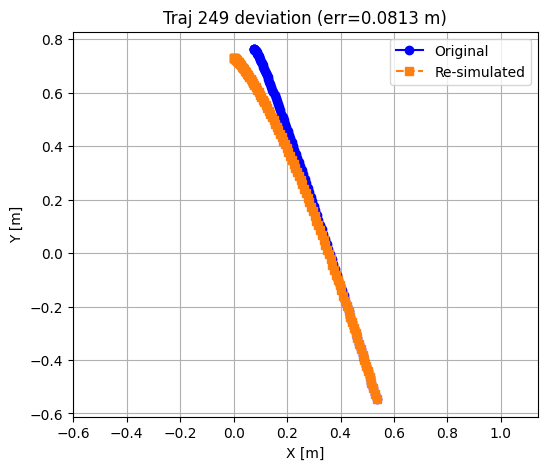

Trajectory 250 removed: max position error = 0.5692 m


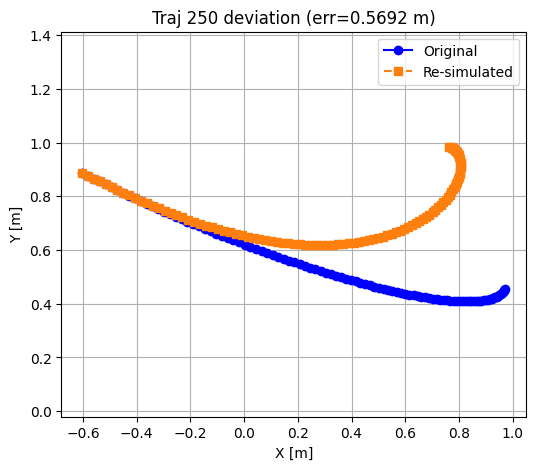

Trajectory 251 removed: max position error = 0.8061 m


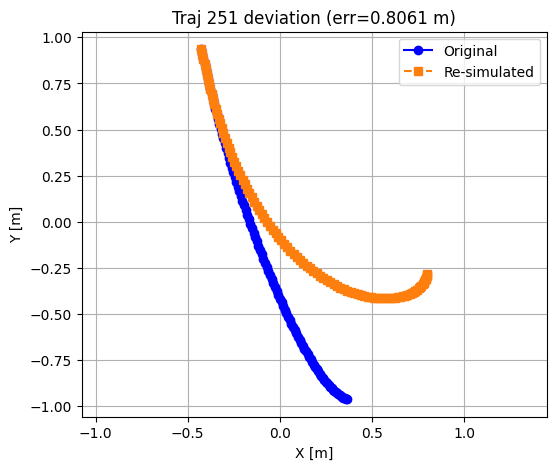

Trajectory 252 removed: max position error = 2.2670 m


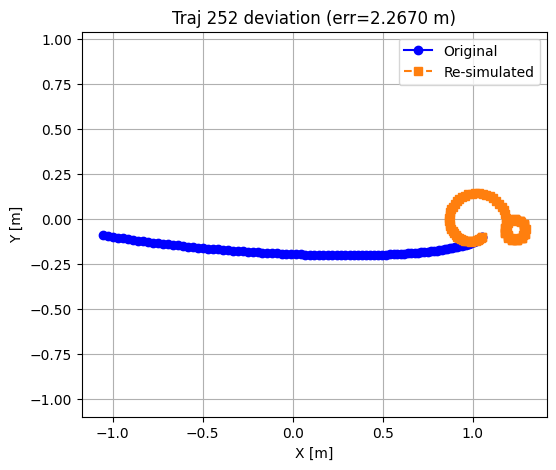

Trajectory 253 removed: max position error = 0.0202 m


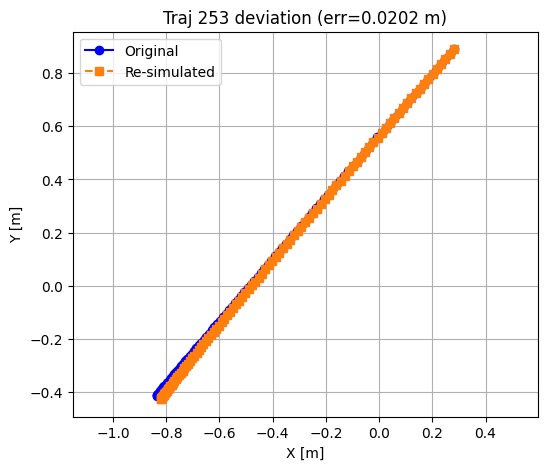

Trajectory 254 removed: max position error = 0.2784 m


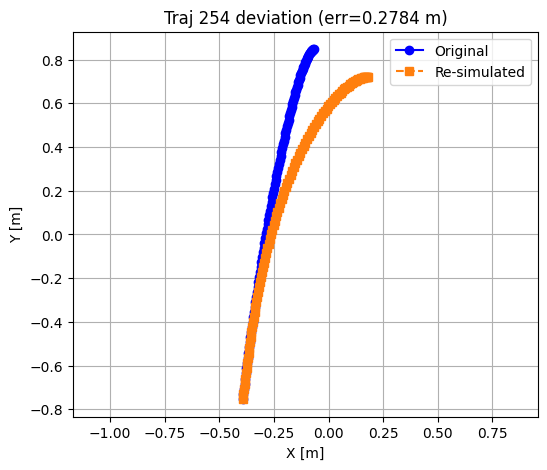

Trajectory 255 removed: max position error = 1.2705 m


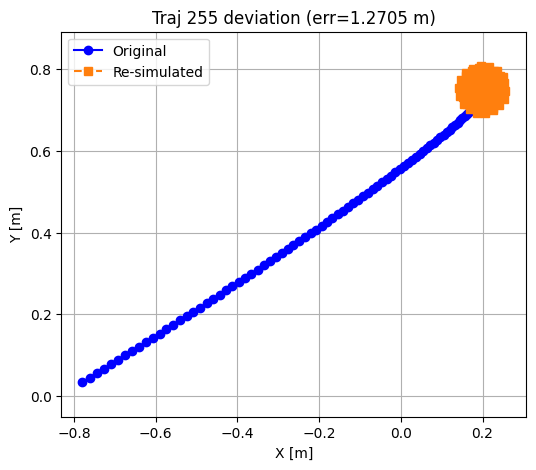

Trajectory 256 removed: max position error = 0.1404 m


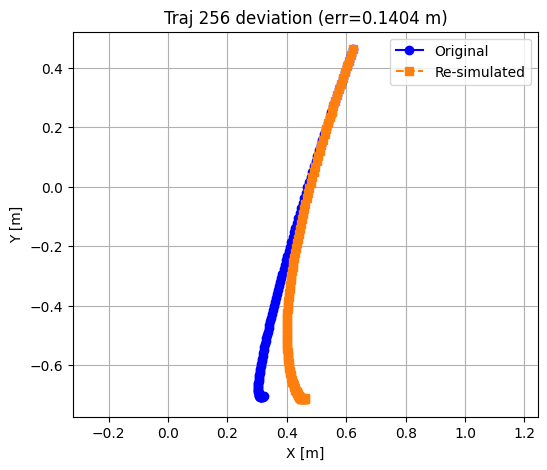

Trajectory 257 removed: max position error = 0.6990 m


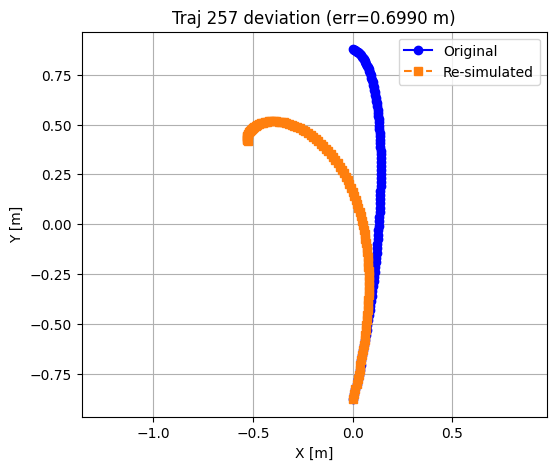

Trajectory 258 removed: max position error = 0.1052 m


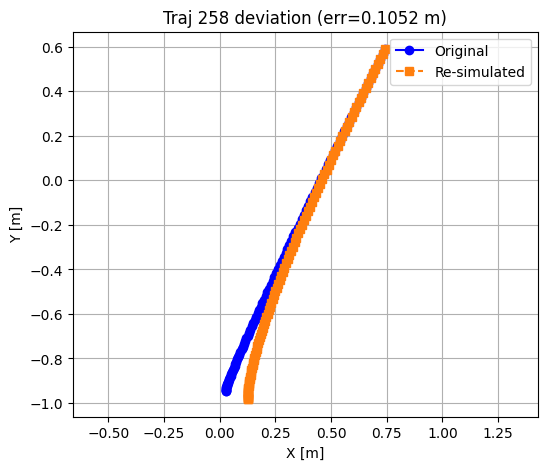

Trajectory 259 removed: max position error = 0.8110 m


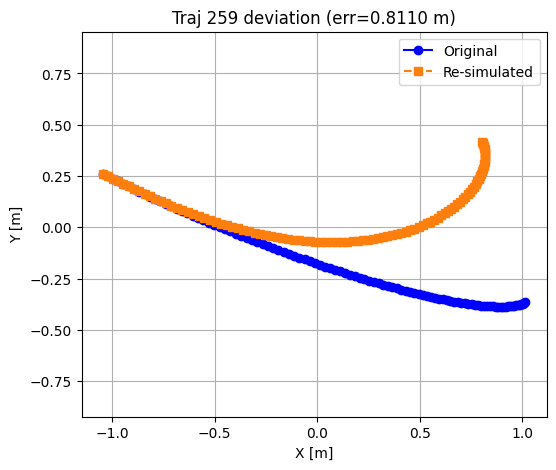

Trajectory 260 removed: max position error = 1.8939 m


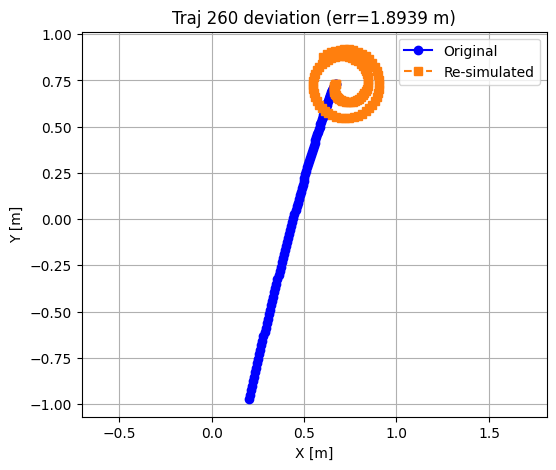

Trajectory 261 removed: max position error = 0.3489 m


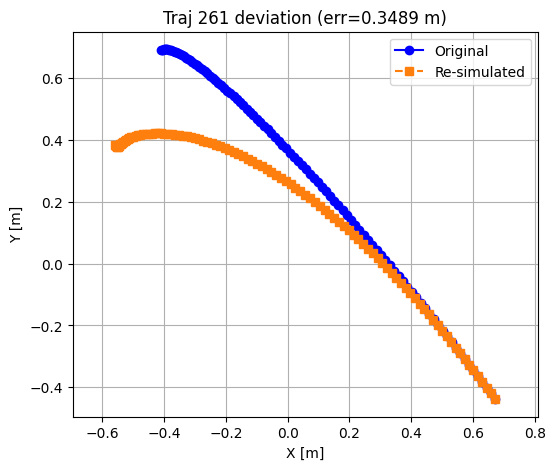

Trajectory 262 removed: max position error = 2.1649 m


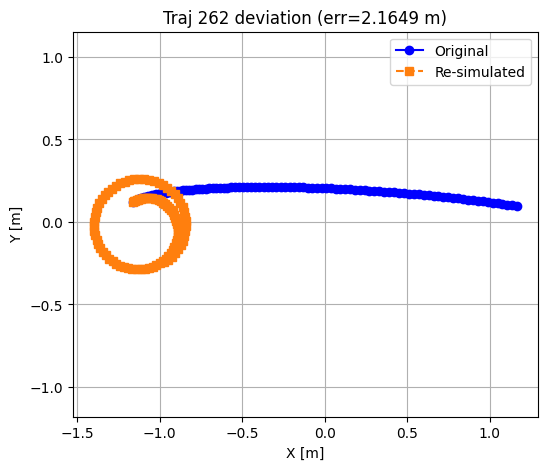

Trajectory 263 removed: max position error = 0.0859 m


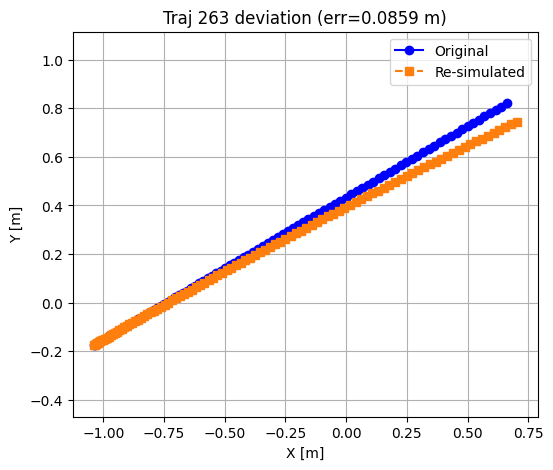

Trajectory 264 removed: max position error = 0.3987 m


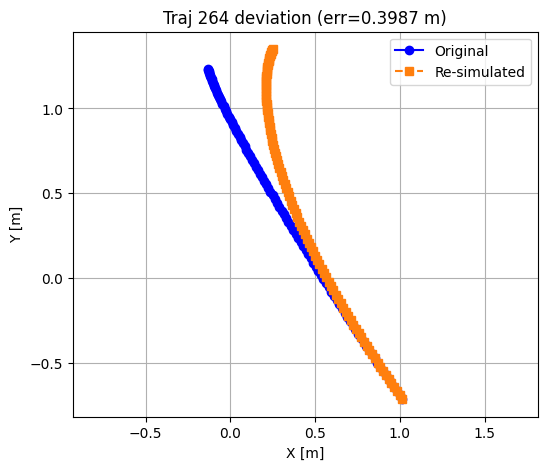

Trajectory 265 removed: max position error = 0.5486 m


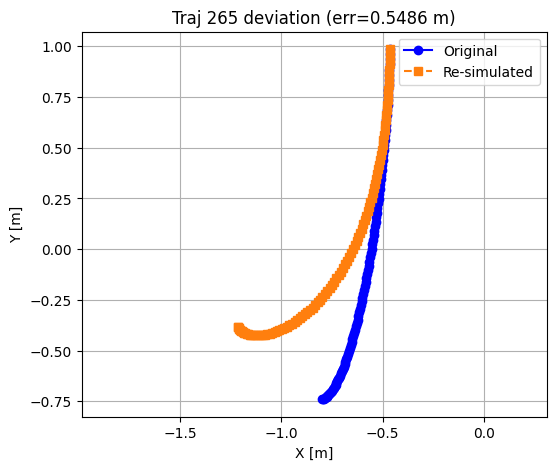

Trajectory 266 removed: max position error = 2.5284 m


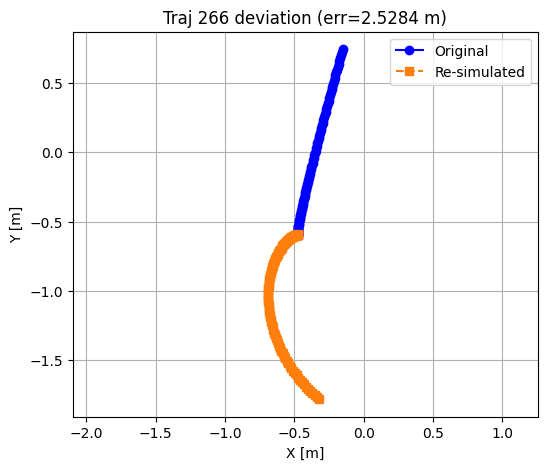

Trajectory 267 removed: max position error = 0.4199 m


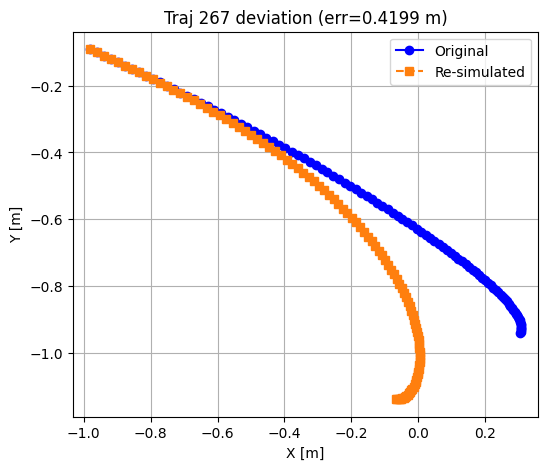

Trajectory 268 removed: max position error = 0.1779 m


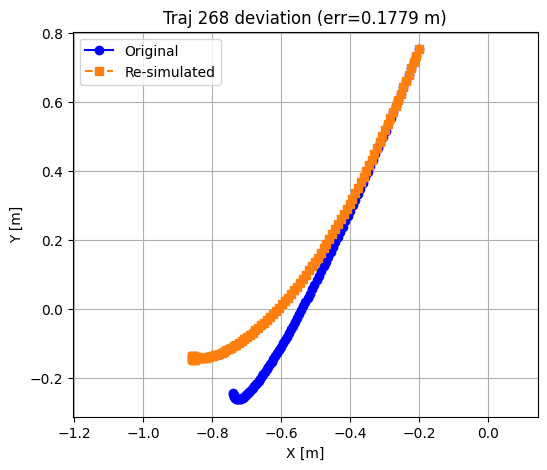

Trajectory 269 removed: max position error = 0.5667 m


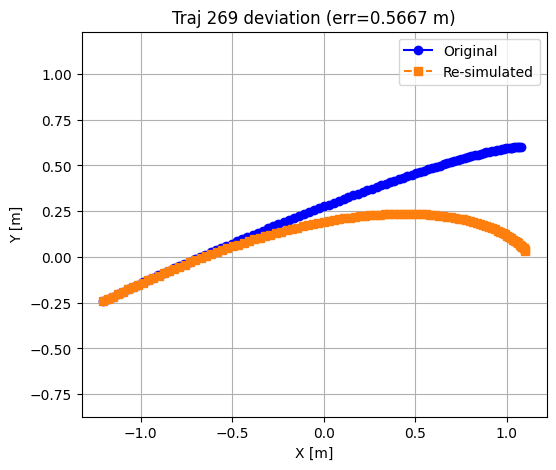

Trajectory 270 removed: max position error = 0.1575 m


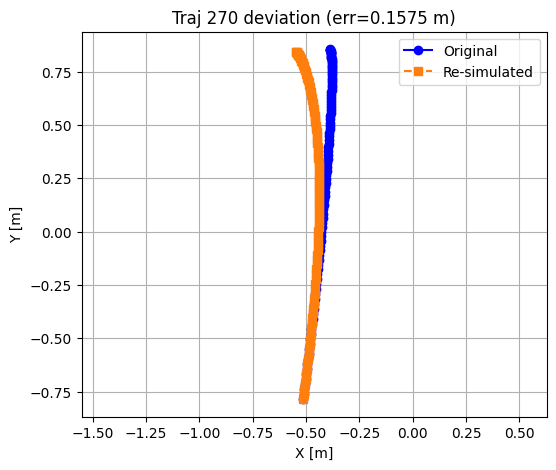

Trajectory 271 removed: max position error = 0.2167 m


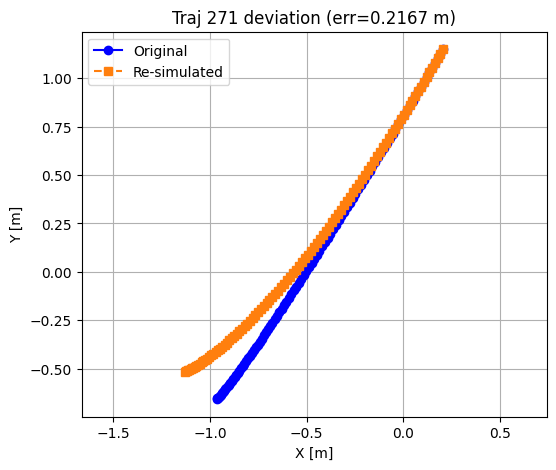

Trajectory 272 removed: max position error = 2.4336 m


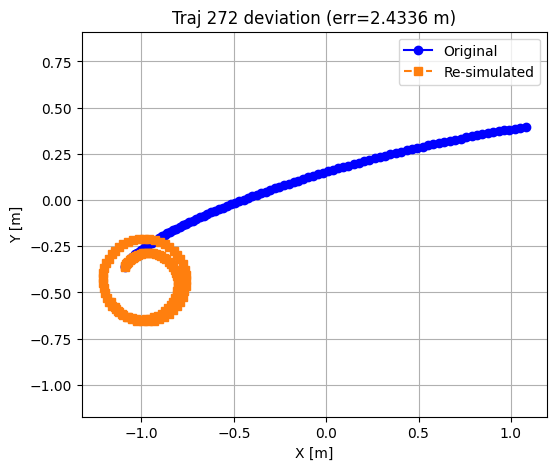

Trajectory 273 removed: max position error = 1.5476 m


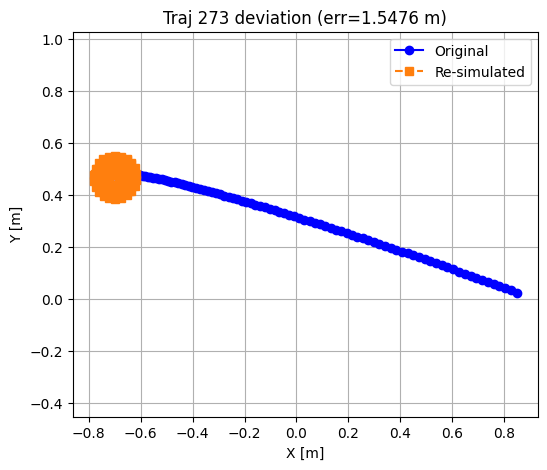

Trajectory 274 removed: max position error = 0.4472 m


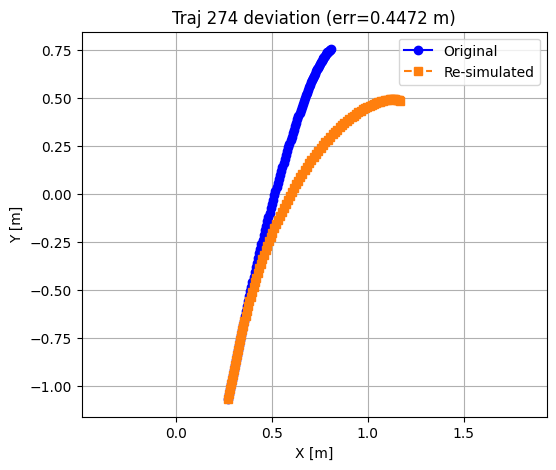

Trajectory 275 removed: max position error = 2.3716 m


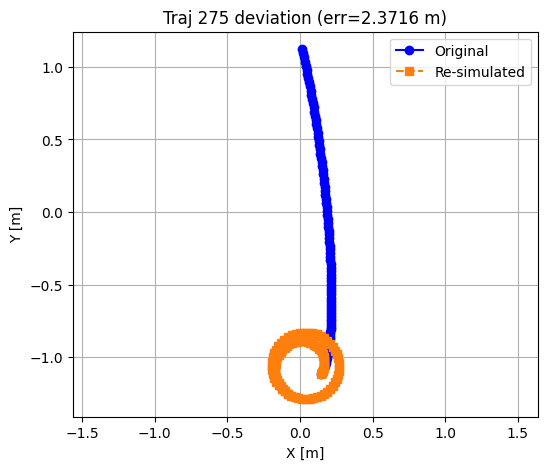

Trajectory 276 removed: max position error = 0.4006 m


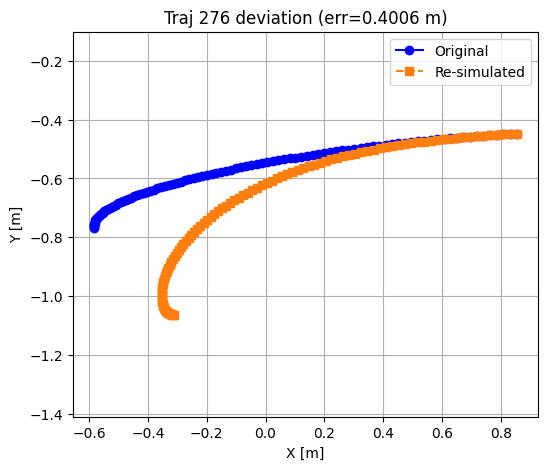

Trajectory 277 removed: max position error = 2.3643 m


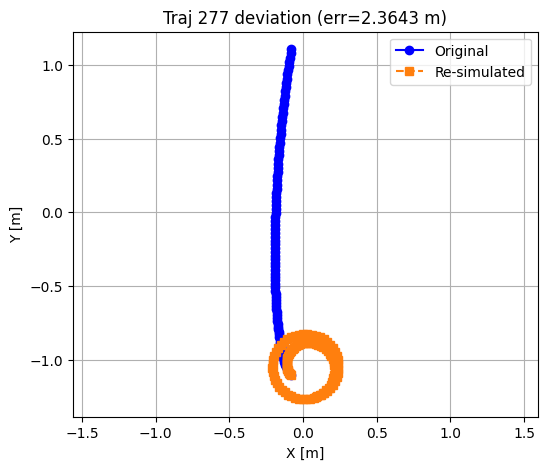

Trajectory 278 removed: max position error = 0.4403 m


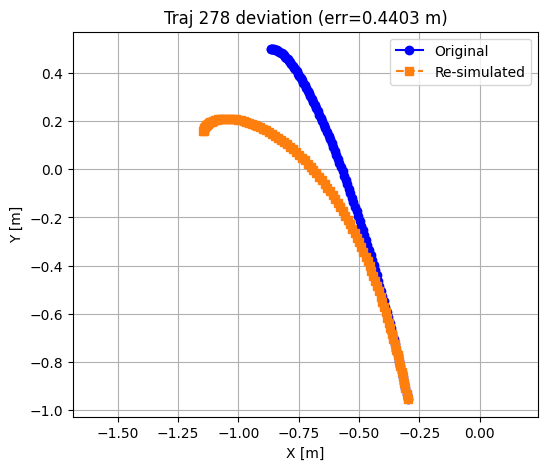

Trajectory 279 removed: max position error = 1.8253 m


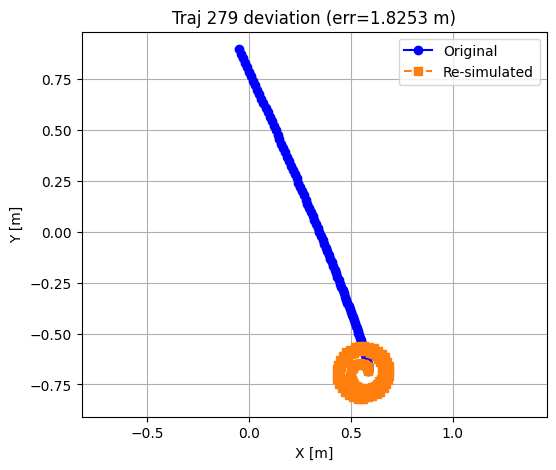

Trajectory 280 removed: max position error = 0.5060 m


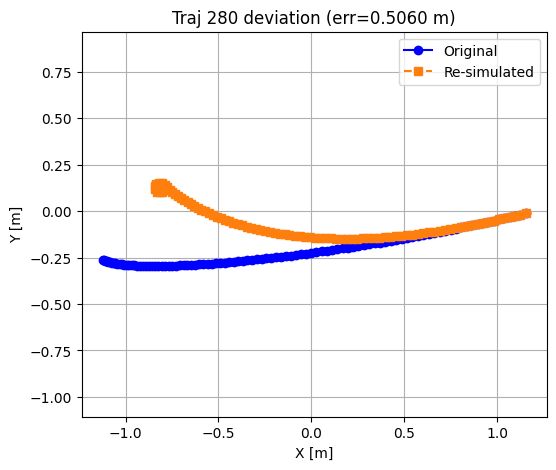

Trajectory 281 removed: max position error = 0.5028 m


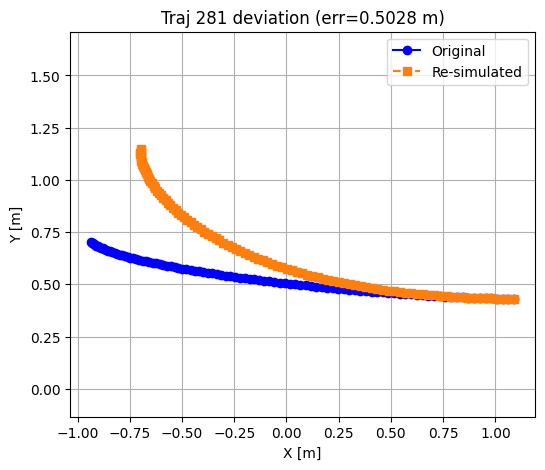

Trajectory 282 removed: max position error = 0.1774 m


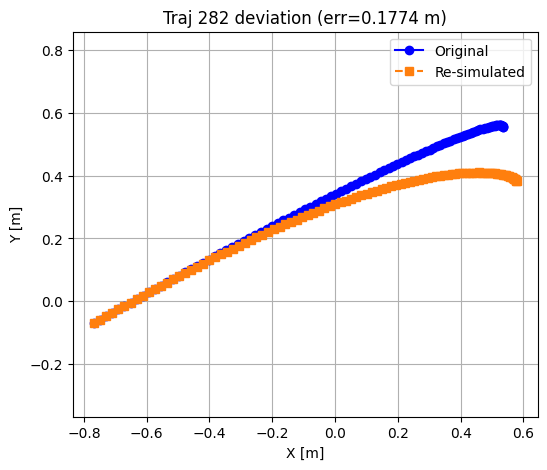

Trajectory 284 removed: max position error = 0.3446 m


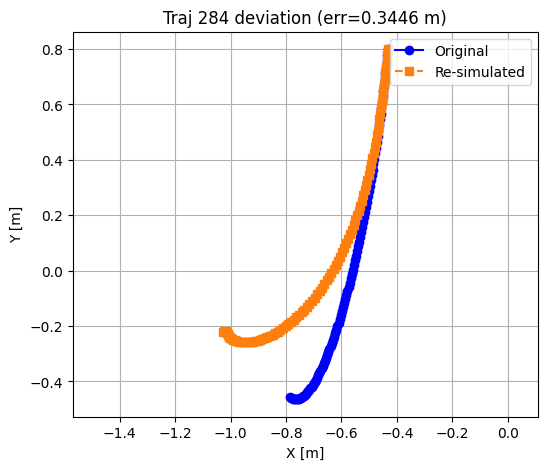

Trajectory 285 removed: max position error = 0.6873 m


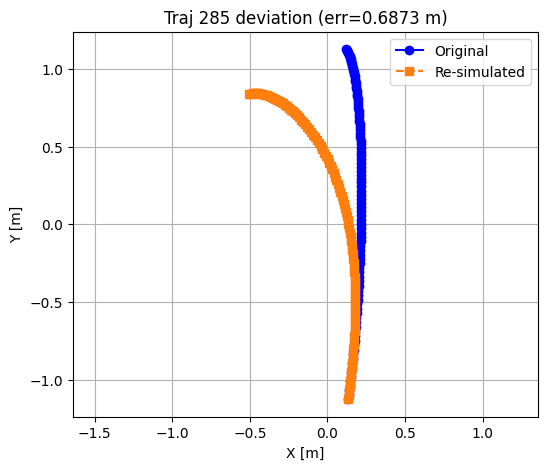

Trajectory 286 removed: max position error = 1.9221 m


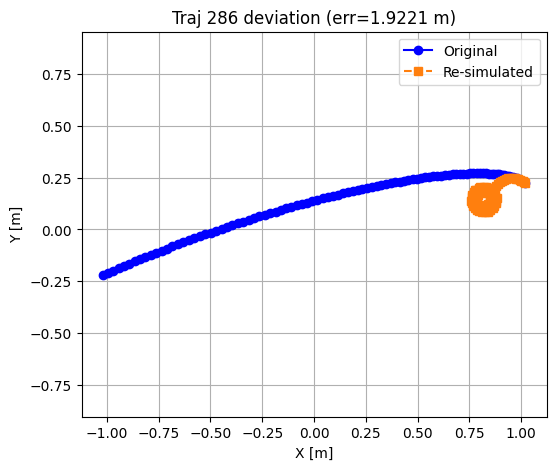

Trajectory 287 removed: max position error = 1.8710 m


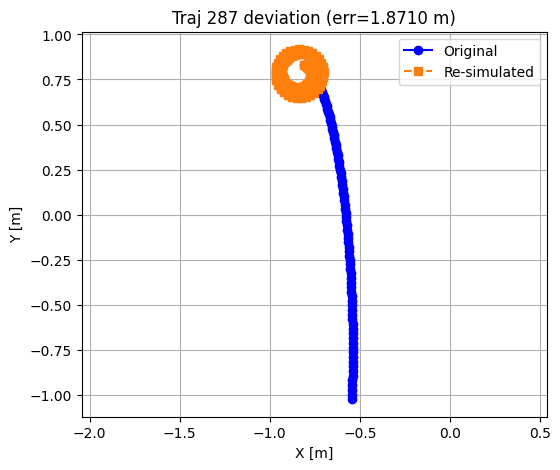

Trajectory 288 removed: max position error = 0.7032 m


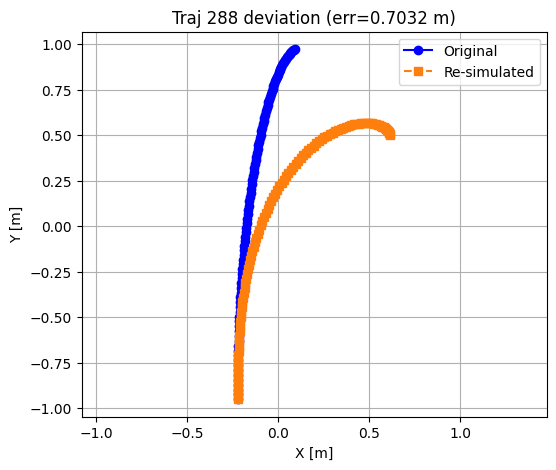

Trajectory 289 removed: max position error = 1.9900 m


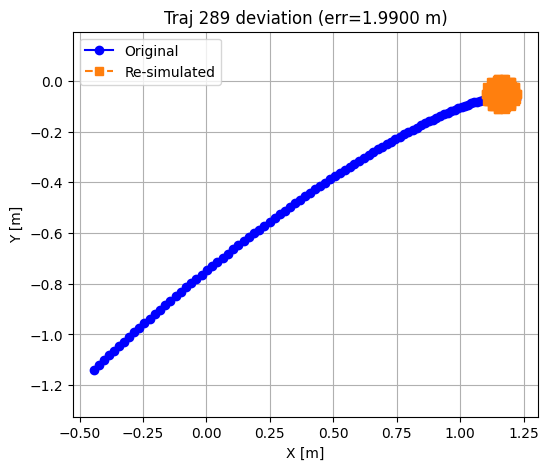

Trajectory 290 removed: max position error = 0.2992 m


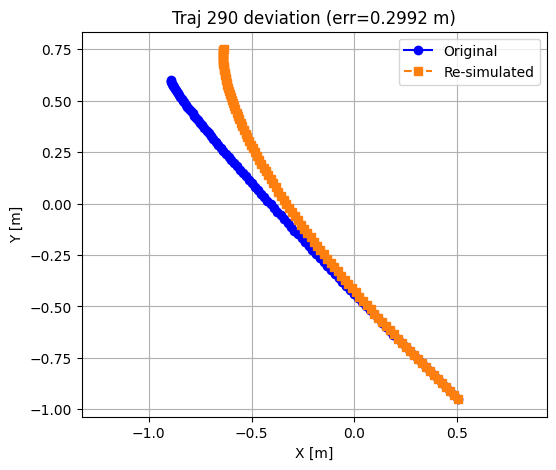

Trajectory 291 removed: max position error = 0.6350 m


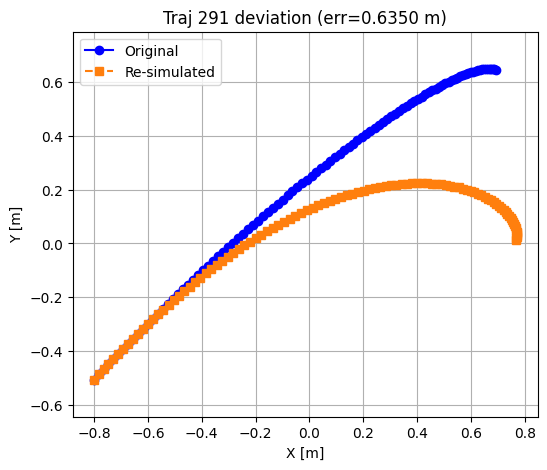

Trajectory 292 removed: max position error = 0.4094 m


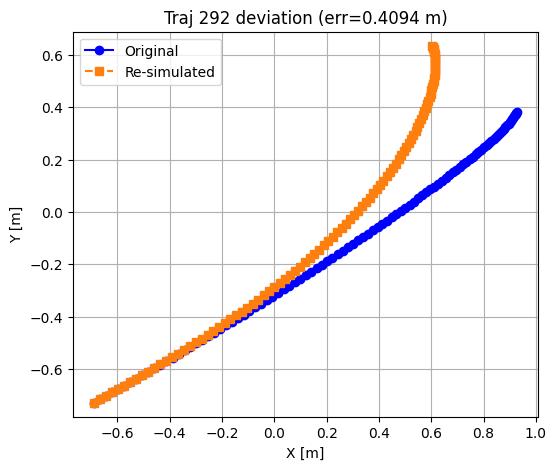

Trajectory 293 removed: max position error = 0.7310 m


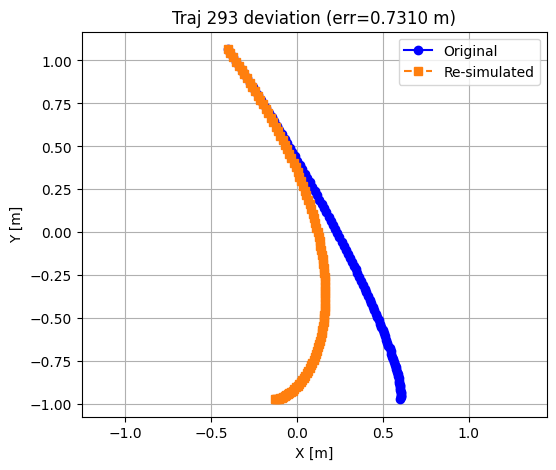

Trajectory 294 removed: max position error = 2.1044 m


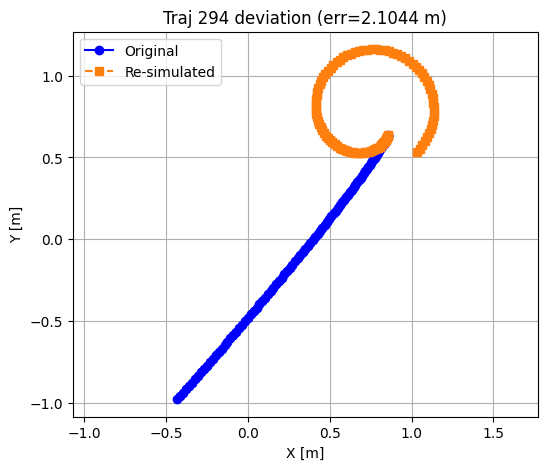

Trajectory 295 removed: max position error = 0.0542 m


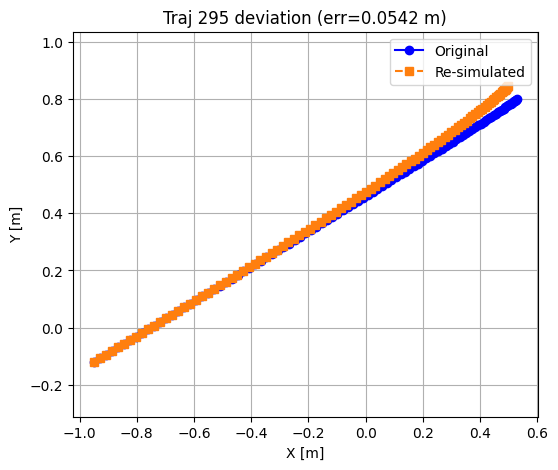

Trajectory 296 removed: max position error = 1.7197 m


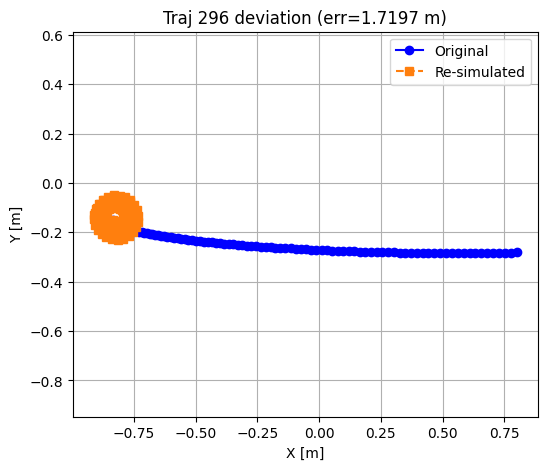

Trajectory 297 removed: max position error = 1.7099 m


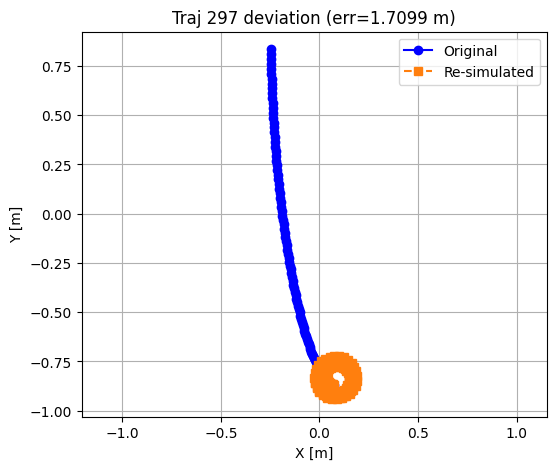

Trajectory 298 removed: max position error = 0.0416 m


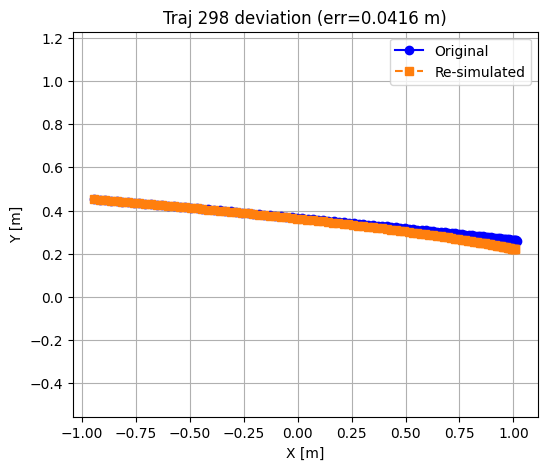

Trajectory 299 removed: max position error = 0.9669 m


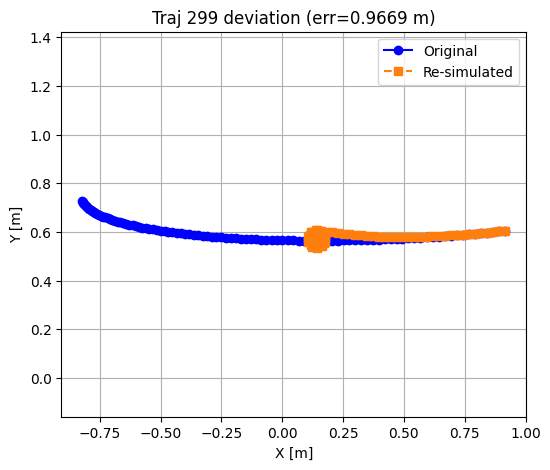


Filtering complete: 297 trajectories removed, 3 remain.
Filtered dataset saved to Car_trajectories_dataset_filtered.npy


In [8]:
# ----------------------------
# Post-processing: filter inconsistent trajectories
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt

pos_error_threshold = 1e-2  

#trajectories = np.load(save_filename, allow_pickle=True)

filtered = []
removed_count = 0

for idx, traj in enumerate(trajectories):
    states_orig = traj['states']      
    controls   = traj['controls'][:-1] 

    states_sim = simulate_vehicle(states_orig[0], controls, dt=dt)
    pos_diff = states_orig[:, :2] - states_sim[:, :2]
    max_pos_err = np.max(np.linalg.norm(pos_diff, axis=1))

    if max_pos_err > pos_error_threshold:
        removed_count += 1
        print(f"Trajectory {idx} removed: max position error = {max_pos_err:.4f} m")

        plt.figure(figsize=(6,5))
        plt.plot(states_orig[:,0], states_orig[:,1], 'b-o', label='Original')
        plt.plot(states_sim[:,0], states_sim[:,1], 'C1--s', label='Re-simulated')
        plt.title(f'Traj {idx} deviation (err={max_pos_err:.4f} m)')
        plt.xlabel('X [m]')
        plt.ylabel('Y [m]')
        plt.legend()
        plt.axis('equal')
        plt.grid(True)
        plt.show()
    else:
        filtered.append(traj)

print(f"\nFiltering complete: {removed_count} trajectories removed, {len(filtered)} remain.")

filtered_filename = 'Car_trajectories_dataset_filtered.npy'
np.save(filtered_filename, filtered, allow_pickle=True)
print("Filtered dataset saved to", filtered_filename)


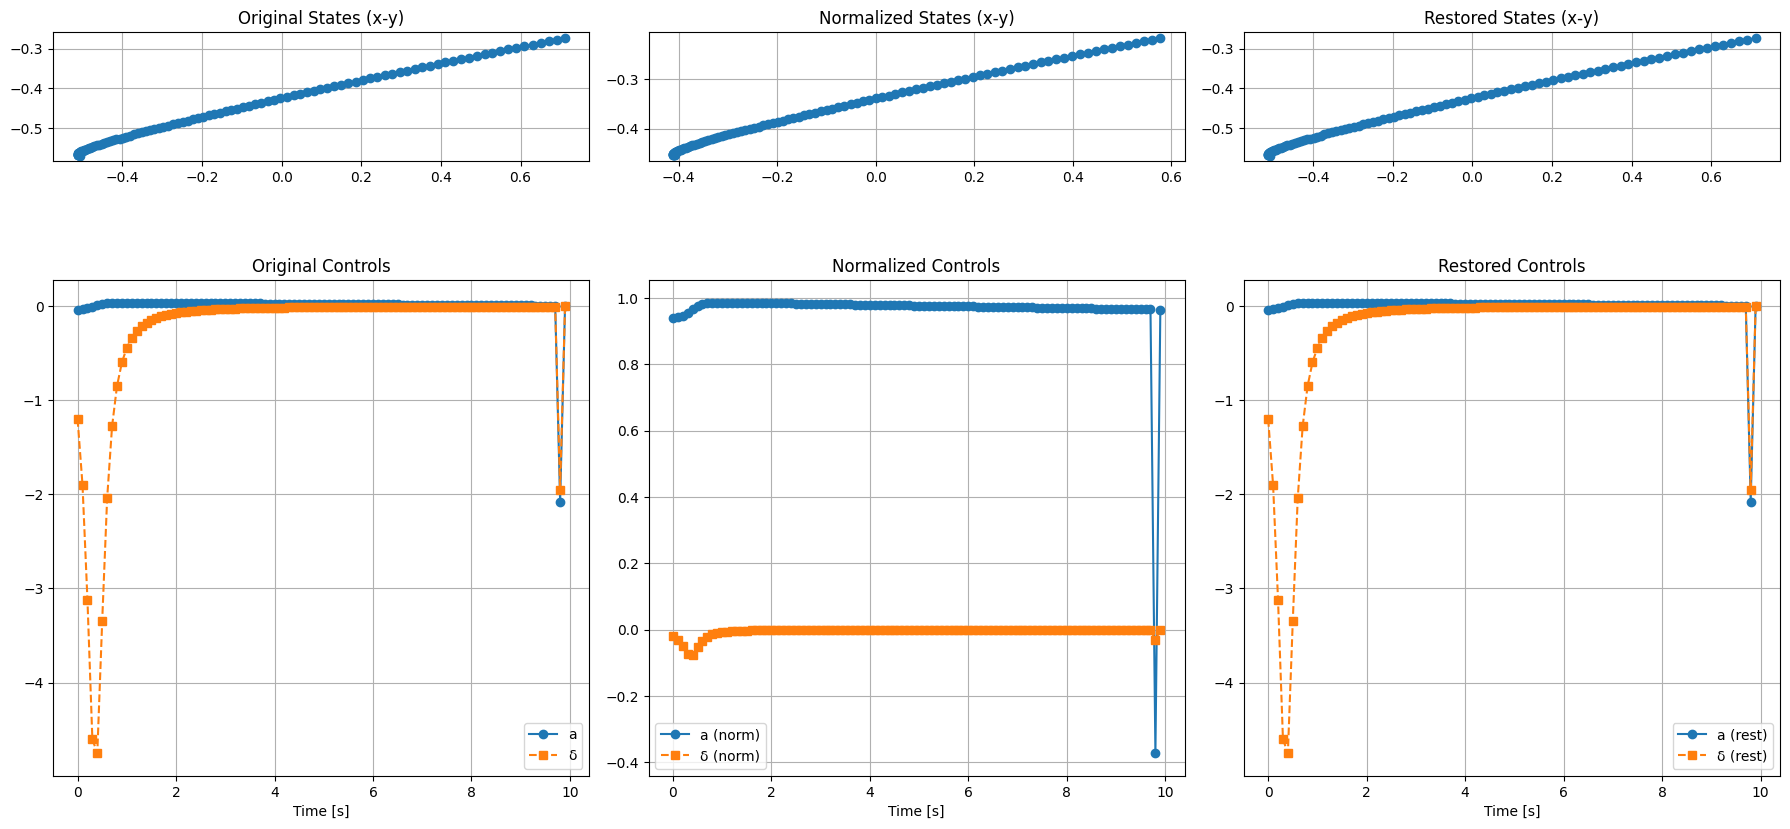

In [9]:
import numpy as np
import matplotlib.pyplot as plt

class Scaler:
    def __init__(self, data_min, data_max):

        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):

        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):

        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

try:
    trajectories
except NameError:
    trajectories = np.load('Car_trajectories_dataset.npy', allow_pickle=True)

all_states   = np.vstack([traj['states']   for traj in trajectories])  # (num_traj*state_steps, 5)
all_controls = np.vstack([traj['controls'] for traj in trajectories])  # (num_traj*state_steps, 2)

state_min,   state_max   = all_states.min(axis=0),   all_states.max(axis=0)
control_min, control_max = all_controls.min(axis=0), all_controls.max(axis=0)

state_scaler   = Scaler(state_min,   state_max)
control_scaler = Scaler(control_min, control_max)

idx = np.random.randint(len(trajectories))
sample = trajectories[idx]
orig_states   = sample['states']    # shape=(state_steps, 5)
orig_controls = sample['controls']  # shape=(state_steps, 2)

norm_states   = state_scaler.normalize(orig_states)
rest_states   = state_scaler.denormalize(norm_states)

norm_controls = control_scaler.normalize(orig_controls)
rest_controls = control_scaler.denormalize(norm_controls)

dt = 0.1
time_ctrl = np.arange(orig_controls.shape[0]) * dt

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

axs[0, 0].plot(orig_states[:,0],   orig_states[:,1],   'o-')
axs[0, 0].set_title('Original States (x-y)')
axs[0, 0].set_aspect('equal', 'box')
axs[0, 0].grid(True)

axs[0, 1].plot(norm_states[:,0],   norm_states[:,1],   'o-')
axs[0, 1].set_title('Normalized States (x-y)')
axs[0, 1].set_aspect('equal', 'box')
axs[0, 1].grid(True)

axs[0, 2].plot(rest_states[:,0],   rest_states[:,1],   'o-')
axs[0, 2].set_title('Restored States (x-y)')
axs[0, 2].set_aspect('equal', 'box')
axs[0, 2].grid(True)

axs[1, 0].plot(time_ctrl, orig_controls[:,0], 'o-', label='a')
axs[1, 0].plot(time_ctrl, orig_controls[:,1], 's--', label='δ')
axs[1, 0].set_title('Original Controls')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].plot(time_ctrl, norm_controls[:,0], 'o-', label='a (norm)')
axs[1, 1].plot(time_ctrl, norm_controls[:,1], 's--', label='δ (norm)')
axs[1, 1].set_title('Normalized Controls')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 1].legend()
axs[1, 1].grid(True)

axs[1, 2].plot(time_ctrl, rest_controls[:,0], 'o-', label='a (rest)')
axs[1, 2].plot(time_ctrl, rest_controls[:,1], 's--', label='δ (rest)')
axs[1, 2].set_title('Restored Controls')
axs[1, 2].set_xlabel('Time [s]')
axs[1, 2].legend()
axs[1, 2].grid(True)

plt.tight_layout()
plt.show()


In [10]:
# ==== 0. Imports & Setup ====
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

# ==== 1. Constants ====
dt = 0.1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 64
#n_epochs = 4500
n_epochs=1
lr = 1e-4
warmup_epochs = int(0.1 * n_epochs)
report_interval = max(1, n_epochs // 10)

# ==== 2. Compute min/max only on used dims & init scalers ====
all_states_s = np.vstack([traj['states'][:, :3]     for traj in trajectories])  # shape (N*100, 3)
all_controls = np.vstack([traj['controls'][:100]    for traj in trajectories])  # shape (N*100, 2)

state_min, state_max   = all_states_s.min(axis=0),   all_states_s.max(axis=0)   # (3,), (3,)
ctrl_min,  ctrl_max    = all_controls.min(axis=0),   all_controls.max(axis=0)    # (2,), (2,)

state_scaler   = Scaler(state_min, state_max)
control_scaler = Scaler(ctrl_min,  ctrl_max)

# ==== 3. Dataset & DataLoader (保持不变) ====
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories, state_scaler, control_scaler):
        self.trajs = trajectories
        self.state_s = state_scaler
        self.ctrl_s = control_scaler

    def __len__(self):
        return len(self.trajs)

    def __getitem__(self, idx):
        traj = self.trajs[idx]
        s = traj['states'][:, :3]     # (100,3)
        c = traj['controls'][:100]    # (100,2)
        s_norm = self.state_s.normalize(s)
        c_norm = self.ctrl_s.normalize(c)
        sample = np.concatenate([s_norm.T, c_norm.T], axis=0).astype(np.float32)  # (5,100)
        return torch.from_numpy(sample)

train_loader = DataLoader(
    TrajectoryDataset(trajectories, state_scaler, control_scaler),
    batch_size=batch_size, shuffle=True, num_workers=0
)



# ==== 4. 可视化 (保持不变) ====
# batch = next(iter(train_loader))    # shape (B,5,100)
# sample = batch[0].numpy()
# x_n, y_n, theta_n, a_n, delta_n = sample
# t_axis = np.linspace(0, (sample.shape[1]-1)*dt, sample.shape[1])

# plt.figure(figsize=(6,4))
# plt.plot(x_n, y_n, '-o')
# plt.title("Normalized Sample Trajectory (x-y)")
# plt.axis('equal'); plt.grid(True)
# plt.show()

# fig, axs = plt.subplots(2,1,figsize=(6,5), sharex=True)
# axs[0].plot(t_axis, a_n, '-o');    axs[0].set_ylabel('a (norm)')
# axs[1].plot(t_axis, delta_n, '-o'); axs[1].set_ylabel('δ (norm)'); axs[1].set_xlabel('t [s]')
# plt.tight_layout(); plt.show()

# ==== 5. 模型组件 (保持不变) ====
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = Mish()
    
    def forward(self, x):
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        return self.act(out + x)

class UpSampler(nn.Module):
    def __init__(self, in_shape=(5,100), out_shape=(1,28,28), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        x = self.norm(x)
        return x.view(x.size(0), *self.out_shape)

class DownSampler(nn.Module):
    def __init__(self, in_shape=(1,28,28), out_shape=(5,100), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        return x.view(x.size(0), *self.out_shape)

class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        hidden = max(channels // ratio, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False), Mish(),
            nn.Conv2d(hidden, channels, 1, bias=False), nn.Sigmoid()
        )
    
    def forward(self, x):
        att = self.fc(self.avg(x) + self.max(x))
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=k, padding=k//2, bias=False)
    
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx, _ = x.max(1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))
        return x * att

class UNetWithAttention(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks, num_classes, class_cond):
        super().__init__(
            image_size=dim[-1],
            in_channels=dim[0],
            model_channels=num_channels,
            out_channels=dim[0],
            num_res_blocks=num_res_blocks,
            attention_resolutions=(16,),
            channel_mult=(1, 2, 2),
            num_classes=num_classes if class_cond else None
        )
        in_ch = dim[0]
        self.ca = ChannelAttention(in_ch)
        self.sa = SpatialAttention()
    
    def forward(self, t, x, y=None):
        feat = super().forward(t, x, y)
        feat = self.ca(feat)
        feat = self.sa(feat)
        return feat

# ==== 6. 创建fmtorch兼容的流模型 ====
class CarTrajectoryFlowModel(ModelWrapper):
    def __init__(self, upsampler, unet_model, downsampler):
        nn.Module.__init__(self)  # 直接初始化nn.Module
        self.upsampler = upsampler
        self.unet = unet_model
        self.downsampler = downsampler
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        # x shape: (batch_size, 5, 100)
        # t shape: (batch_size,)
        
        # 上采样到图像空间
        x_img = self.upsampler(x)  # (batch_size, 1, 28, 28)
        
        # 为UNet准备dummy标签
        batch_size = x.shape[0]
        dummy_label = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        
        # 通过UNet
        v_img = self.unet(t, x_img, dummy_label)
        
        # 下采样回轨迹空间
        v_traj = self.downsampler(v_img)  # (batch_size, 5, 100)
        
        return v_traj

# ==== 7. 初始化模型和优化器 ====
upsampler = UpSampler().to(device)
downsampler = DownSampler().to(device)
unet = UNetWithAttention(
    dim=(1, 28, 28), 
    num_channels=32, 
    num_res_blocks=2,
    num_classes=10, 
    class_cond=True
).to(device)

# 创建fmtorch流模型
flow_model = CarTrajectoryFlowModel(upsampler, unet, downsampler)

# 优化器
optim = torch.optim.Adam(
    list(upsampler.parameters()) +
    list(downsampler.parameters()) +
    list(unet.parameters()), 
    lr=lr
)

# 学习率调度器
scheduler = LambdaLR(
    optim, lr_lambda=lambda epoch: (
        float(epoch) / warmup_epochs if epoch < warmup_epochs else
        0.5*(1.0 + math.cos(math.pi*(epoch - warmup_epochs)/(n_epochs - warmup_epochs)))
    )
)

# ==== 初始化fmtorch组件 ====
path = AffinePath(scheduler=CondOTScheduler())

# # ==== 8. 使用fmtorch的训练循环 ====
# best_loss = float('inf')
# loss_history = []

# for epoch in range(1, n_epochs+1):
#     epoch_loss = 0.0
#     batch_count = 0
#     monitor_grad = (epoch % report_interval == 0)

#     for batch_idx, batch in enumerate(train_loader):
#         x1 = batch.to(device)  # 目标轨迹
#         x0 = torch.randn_like(x1)  # 噪声初始化
        
#         # 使用fmtorch的路径采样
#         t = torch.rand(x1.shape[0]).to(device)
#         path_sample = path.sample(t=t, x_0=x0, x_1=x1)
        
#         # 通过流模型预测速度
#         vt_pred = flow_model(path_sample.x_t, path_sample.t)
        
#         # 计算损失
#         # 1. Flow matching损失
#         flow_loss = F.mse_loss(vt_pred, path_sample.dx_t)
        
#         # 2. 重建损失
#         x1_recon = flow_model.downsampler(flow_model.upsampler(x1))
#         recon_loss = F.mse_loss(x1_recon, x1)
        
#         # 总损失
#         loss = flow_loss + recon_loss

#         optim.zero_grad()
#         loss.backward()

#         # 梯度监控
#         if monitor_grad and batch_idx == 0:
#             max_grad = max(
#                 p.grad.abs().max().item()
#                 for g in optim.param_groups for p in g['params']
#                 if p.grad is not None
#             )
#             print(f"[Grad Monitor] Epoch {epoch}/{n_epochs}, Max Grad = {max_grad:.6f}")

#         # 梯度裁剪
#         torch.nn.utils.clip_grad_norm_(
#             list(upsampler.parameters()) +
#             list(downsampler.parameters()) +
#             list(unet.parameters()), 
#             max_norm=1.0
#         )
#         optim.step()

#         loss_history.append(loss.item())
#         epoch_loss += loss.item()
#         batch_count += 1

#     # 更新学习率
#     scheduler.step()

#     # 计算平均损失
#     epoch_loss /= batch_count

#     # 常规日志
#     if epoch % report_interval == 0:
#         print(f"Epoch {epoch}/{n_epochs}  |  avg loss = {epoch_loss:.6f}")
#     if epoch % 500 == 0:
#         print(f"[Checkpoint] Epoch {epoch}/{n_epochs}  |  avg loss = {epoch_loss:.6f}")

#     # 从epoch 3500开始，每200个epoch保存最佳模型
#     if epoch >= 3500 and epoch % 200 == 0:
#         if epoch_loss < best_loss:
#             best_loss = epoch_loss
#             ckpt = {
#                 'epoch': epoch,
#                 'upsampler': upsampler.state_dict(),
#                 'downsampler': downsampler.state_dict(),
#                 'unet': unet.state_dict(),
#                 'optimizer': optim.state_dict(),
#                 'loss': best_loss
#             }
#             torch.save(ckpt, f'fmtorch_best_ckpt_epoch{epoch:04d}.pt')
#             print(f"→ Saved new best checkpoint at epoch {epoch}, loss {best_loss:.6f}")
#         else:
#             print(f"→ Epoch {epoch}, loss {epoch_loss:.6f} did not improve (best {best_loss:.6f})")

# # ==== 9. 绘制损失曲线 ====
# plt.figure(figsize=(6,4))
# plt.plot(loss_history)
# plt.yscale('log')
# plt.grid(True)
# plt.title("Training Loss")
# plt.xlabel("Iteration")
# plt.ylabel("Loss")
# plt.show()

# print("Training completed!")

In [11]:
# ==== Cell: Load checkpoint, ODE inference, denormalize & compare ====

import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load('fmtorch_best_ckpt_epoch4400.pt', map_location=device)
upsampler.load_state_dict(ckpt['upsampler'])
downsampler.load_state_dict(ckpt['downsampler'])
unet.load_state_dict(ckpt['unet'])
upsampler.eval()
downsampler.eval()
unet.eval()

# 2. Perform ODE-based flow-matching inference (in normalized space)
with torch.no_grad():
    x0_noise = torch.randn((1, 5, state_steps), device=device)
    t_span = torch.linspace(0., 1., 2, device=device)

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 5, state_steps)
        img = upsampler(x)
        labels = torch.zeros((1,), dtype=torch.long, device=device)
        v_img = unet(t, img, labels)
        v_traj = downsampler(v_img)
        return v_traj.view(-1)

    traj_t = torchdiffeq.odeint(
        fm_ode_func,
        x0_noise.view(-1),
        t_span,
        atol=1e-5,
        rtol=1e-5,
        method='dopri5'
    )
    x_fm_norm = traj_t[-1].view(5, state_steps).cpu().numpy()  # shape: (5, 100)

# 3. Split into states and controls, then denormalize
states_norm   = x_fm_norm[:3, :].T   # (100, 3): [x, y, theta]
controls_norm = x_fm_norm[3:5, :].T  # (100, 2): [accel, steer]

states   = state_scaler.denormalize(states_norm)      # (100, 3)
controls = control_scaler.denormalize(controls_norm)  # (100, 2)

# 4. Visualize the inferred state trajectory and control sequence
time = np.linspace(0, (state_steps-1)*dt, state_steps)

plt.figure(figsize=(6,6))
plt.plot(states[:,0], states[:,1], '-o', label='ODE-inferred path')
plt.scatter(states[0,0], states[0,1], c='g', label='Start')
plt.scatter(states[-1,0], states[-1,1], c='r', label='End (ODE)')
plt.title('Denormalized ODE-inferred State Trajectory')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True)
ax1.plot(time, controls[:,0], '-o')
ax1.set_ylabel('Acceleration a [m/s²]')
ax1.set_title('Denormalized ODE-inferred Acceleration')
ax1.grid(True)

ax2.plot(time, controls[:,1], '-s')
ax2.set_ylabel('Steering δ [rad]')
ax2.set_xlabel('Time [s]')
ax2.set_title('Denormalized ODE-inferred Steering Angle')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Simulate vehicle dynamics with the inferred controls and compare
x0_state = np.concatenate([states[0], [0.0, 0.0]])  # [x0, y0, theta0, v0=0, r0=0]
sim_states = simulate_vehicle(x0=x0_state, u_seq=controls[:control_steps], dt=dt)

plt.figure(figsize=(6,6))
plt.plot(states[:,0],     states[:,1],     '-o', label='ODE-inferred path')
plt.plot(sim_states[:,0], sim_states[:,1], '-x', label='Simulated path')
plt.scatter(states[0,0], states[0,1], c='g', label='Start')
plt.scatter(states[-1,0], states[-1,1], c='r', label='End (ODE)')
plt.scatter(sim_states[-1,0], sim_states[-1,1], c='m', label='End (Sim)')
plt.title('Comparison: ODE Inference vs. Dynamics Simulation')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'fmtorch_best_ckpt_epoch4400.pt'

In [10]:
# === Cell: FM Sampling with and without CLF Correction (RK4 固定步长) ===

import torch
import torchdiffeq
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# --- 1. QP-based CLF 校正 ---

# clf_params = {
#     'a_max':   0.25,
#     'delta_max': 0.2,
#     'beta':    10.0,    # 状态一致性惩罚权重，可调
#     'lambda_reg':10,
#     'mask':1.1,
#     'cap':1e3,
#     'dt':0.1,
#     't_frac':0

# }
clf_params = {
    'a_max': 0.9,        # 控制输入的上界
    'delta_max': 0.9,     # 转向角的上界
    'beta': 1e-1,         # 状态一致性权重（非常小）
    'lambda_reg': 1e5,   # 控制调整正则化权重（非常大）
    'mask': 0.9,          # 取消掩码，确保校正应用于整个轨迹
    'cap': 1e3,           # 其他参数保持不变
    'dt': 0.1,            # 时间步长
    't_frac': 0           # 时间分段参数
}

all_data_5d = np.vstack([
    np.hstack([traj['states'][:, :3], traj['controls'][:100]])
    for traj in trajectories
])  # shape = (num_traj*100, 5)
data_min_5d, data_max_5d = all_data_5d.min(axis=0), all_data_5d.max(axis=0)
state_scaler = Scaler(data_min_5d, data_max_5d)


def time_blow_up_function(t, T=1.0, cap=1e3):
    """
    当 t→T 时，phi → ∞，但上限 cap。
    """
    phi = 1.0 / (T - t + 1e-8)
    return min(phi, cap)


def correct_with_clf(states_phys, controls_phys, clf_params):
    """
    states_phys: (100,3)
    controls_phys: (100,2)
    clf_params 包含:
      'a_max','delta_max','lambda_reg','beta',
      'mask' ∈ [0,1], 't_frac' ∈ [0,1], 'cap'
    """
    N = states_phys.shape[0]
    a_max = clf_params['a_max']
    d_max = clf_params['delta_max']
    λ_reg = clf_params['lambda_reg']
    β     = clf_params['beta']
    mask  = clf_params.get('mask', 0.0)
    t     = clf_params.get('t_frac', 1.0)
    cap   = clf_params.get('cap', 1e3)
    dt    = clf_params.get('dt', 0.1)

    # 如果 t_frac < mask，则跳过校正
    if t < mask:
        return controls_phys.copy()

    # 计算 blow_up 权重
    phi = time_blow_up_function(t, T=1.0, cap=cap)
    w_state = phi / (1.0 + phi)  # ∈ (0,1)

    # 初始物理状态
    x0 = np.array([states_phys[0,0],
                   states_phys[0,1],
                   states_phys[0,2],
                   0.0, 0.0])

    # 决策变量：delta_u_flat
    u0 = np.zeros(N*2, dtype=np.float32)

    def objective(delta_u_flat):
        delta_u = delta_u_flat.reshape((N,2))
        U       = controls_phys + delta_u
        # 仿真前 N-1 步
        states_pred = simulate_vehicle(x0, U[:-1], dt=dt)  # (N,5)
        pos_pred    = states_pred[:, :3]
        # 状态误差
        err = pos_pred - states_phys     # (N,3)
        J_state = β * w_state * np.sum(err**2)
        J_ctrl  = λ_reg * np.sum(delta_u**2)
        return J_state + J_ctrl

    # bounds 保证 phys+delta ∈ [−amax,amax]×[−dmax,dmax]
    bnds = []
    for k in range(N):
        a_phys, d_phys = controls_phys[k]
        bnds += [(-a_max - a_phys, a_max - a_phys),
                 (-d_max - d_phys, d_max - d_phys)]

    res = minimize(objective, u0, method='SLSQP', bounds=bnds,
                   options={'ftol':1e-6, 'maxiter':200})
    delta_u = res.x.reshape((N,2)).astype(np.float32)
    return controls_phys + delta_u
    #return controls_phys.copy()

# --- 2. 纯 FM 分段采样 ---
def piecewise_fm(x0_norm, upsampler, unet, downsampler, num_segments):
    device = x0_norm.device
    times = np.linspace(0.0, 1.0, num_segments+1, dtype=np.float32)
    state = x0_norm.clone()
    #CFM = ConditionalFlowMatcher(sigma=0.0)

    def ode_func(t, x_flat):
        x = x_flat.view(1,5,100)
        with torch.no_grad():
            img   = upsampler(x)
            vimg  = unet(t, img, torch.zeros(1, dtype=torch.long, device=device))
            vtraj = downsampler(vimg)
        return vtraj.view(-1)

    for i in range(num_segments):
        t0, t1 = float(times[i]), float(times[i+1])
        t_span = torch.tensor([t0, t1], device=device, dtype=state.dtype)
        dt_seg = t1 - t0
        with torch.no_grad():
            traj = torchdiffeq.odeint(
                ode_func,
                state.view(-1),
                t_span,
                method='rk4',
                options={'step_size': dt_seg}
            )
        state = traj[-1].view(1,5,100)
    return state

# --- 3. 分段采样＋CLF 干预 ---
def piecewise_fm_with_clf(x0_norm,
                          upsampler, unet, downsampler,
                          state_scaler,
                          num_segments,
                          clf_params):
    device = x0_norm.device
    times = np.linspace(0.0, 1.0, num_segments+1, dtype=np.float32)
    state = x0_norm.clone()
    #CFM = ConditionalFlowMatcher(sigma=0.0)

    def ode_func(t, x_flat):
        x = x_flat.view(1,5,100)
        with torch.no_grad():
            img   = upsampler(x)
            vimg  = unet(t, img, torch.zeros(1, dtype=torch.long, device=device))
            vtraj = downsampler(vimg)
        return vtraj.view(-1)

    for i in range(num_segments):
        # 1) RK4 一步积分
        t0, t1 = float(times[i]), float(times[i+1])
        t_span = torch.tensor([t0, t1], device=device, dtype=state.dtype)
        dt_seg = t1 - t0
        with torch.no_grad():
            traj = torchdiffeq.odeint(
                ode_func,
                state.view(-1),
                t_span,
                method='rk4',
                options={'step_size': dt_seg}
            )
        seg_end = traj[-1].view(1,5,100)  # 归一化

        # 2) 整条 5×100 反归一化
        arr_norm = seg_end.cpu().numpy()[0].T       # (100,5), fdtloat32
        arr_phys = state_scaler.denormalize(arr_norm)  # (100,5), float32
        
        clf_params['t_frac'] = float(i+1) / float(num_segments)
        
        # 3) 拆出状态与控制，CLF 校正
        states_phys   = arr_phys[:, :3]
        controls_phys = arr_phys[:, 3:]
        controls_corr = correct_with_clf(states_phys, controls_phys, clf_params)  # (100,2)

        # 4) 拼回去 & 重新归一化
        arr_phys[:, 3:] = controls_corr
        arr_norm_corr  = state_scaler.normalize(arr_phys)   # (100,5)
        seg_end_corr   = torch.from_numpy(arr_norm_corr.T).to(device).type(state.dtype)

        state = seg_end_corr.unsqueeze(0).detach()

    return state  # (1,5,100) 归一化

# --- 4. 运行 & 对比可视化 ---
num_segments = 100
dt = 0.1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 生成同一条归一化噪声
x0_noise = torch.randn((1,5,100), device=device, dtype=torch.float32)

# ① 纯 FM
state_pure = piecewise_fm(x0_noise, upsampler, unet, downsampler, num_segments)
# ② FM + CLF
state_clf  = piecewise_fm_with_clf(
    x0_noise, upsampler, unet, downsampler,
    state_scaler,
    num_segments, clf_params
)

# 提取并反归一化控制
def extract_controls(state_norm):
    """
    state_norm: Tensor (1,5,100) 归一化后的
    返回 (100,2) 的物理控制量 [a, delta]
    """
    arr_norm = state_norm.cpu().numpy()[0].T   # (100,5)
    c_norm   = arr_norm[:, 3:]                # (100,2) 只取控制部分
    ctrl_phys = control_scaler.denormalize(c_norm)  # 用 control_scaler 反归一化
    return ctrl_phys

ctrl_pure = extract_controls(state_pure)
ctrl_clf  = extract_controls(state_clf)

# 时间轴
t_axis = np.arange(100) * dt




# 可视化
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True)
ax1.plot(t_axis, ctrl_pure[:,0], label='Pure FM')
ax1.plot(t_axis, ctrl_clf[:,0],  label='FM + CLF')
ax1.set_ylabel('a')
ax1.legend(); ax1.grid(True)

ax2.plot(t_axis, ctrl_pure[:,1], label='Pure FM')
ax2.plot(t_axis, ctrl_clf[:,1],  label='FM + CLF')
ax2.set_ylabel(r'$\delta$ [rad]')
ax2.set_xlabel('t [s]')
ax2.legend(); ax2.grid(True)

plt.suptitle('compare')
plt.tight_layout()
plt.show()




# --- 5. 用 simulate_vehicle 生成三条轨迹并可视化 + RMSE ---
# 假设 state_pure, state_clf, state_scaler, dt 已经准备好

# 1) 先反归一化纯 FM 输出的全 5 维数据
arr_norm_pure = state_pure.cpu().numpy()[0].T       # (100,5)
arr_phys_pure = state_scaler.denormalize(arr_norm_pure)  # (100,5)
states_fm     = arr_phys_pure[:, :3]                # (100,3)

# 2) 同理，也可以拿 state_clf 的
arr_norm_clf  = state_clf.cpu().numpy()[0].T
arr_phys_clf  = state_scaler.denormalize(arr_norm_clf)
# 但这里只要控制就行

# 3) 仿真
x0_phys = np.array([states_fm[0,0], states_fm[0,1], states_fm[0,2], 0.0, 0.0])

# 纯 FM 控制
traj_sim_pure = simulate_vehicle(x0_phys, ctrl_pure[:-1], dt=dt)  # (100,5)
states_sim_pure = traj_sim_pure[:, :3]

# FM+CLF 控制
traj_sim_clf = simulate_vehicle(x0_phys, ctrl_clf[:-1], dt=dt)
states_sim_clf = traj_sim_clf[:, :3]

# 4) 计算 RMSE（只比位置）
def rmse(a, b):
    return np.sqrt(np.mean(np.sum((a - b)**2, axis=1)))

rmse_fm_vs_phys  = rmse(states_fm[:, :2], states_sim_pure[:, :2])
rmse_clf_vs_phys = rmse(states_fm[:, :2], states_sim_clf[:, :2])

print(f"RMSE (Pure FM sim vs FM states):  {rmse_fm_vs_phys:.4f} m")
print(f"RMSE (FM+CLF sim vs FM states): {rmse_clf_vs_phys:.4f} m")

# 5) 绘图比较
plt.figure(figsize=(6,6))
plt.plot(states_fm[:,0], states_fm[:,1],  'k-',  label='FM states')
plt.plot(states_sim_pure[:,0], states_sim_pure[:,1], 'C0--', label='Pure FM Ctrl')
plt.plot(states_sim_clf[:,0], states_sim_clf[:,1],   'C1-.', label='FM+CLF Ctrl')
plt.scatter(states_fm[0,0], states_fm[0,1], c='g', s=50, label='Starting')
plt.scatter(states_fm[-1,0], states_fm[-1,1], c='r', s=50, label='Target')
plt.axis('equal')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.title('Camparision')
plt.legend(); plt.grid(True)
plt.show()


KeyboardInterrupt: 

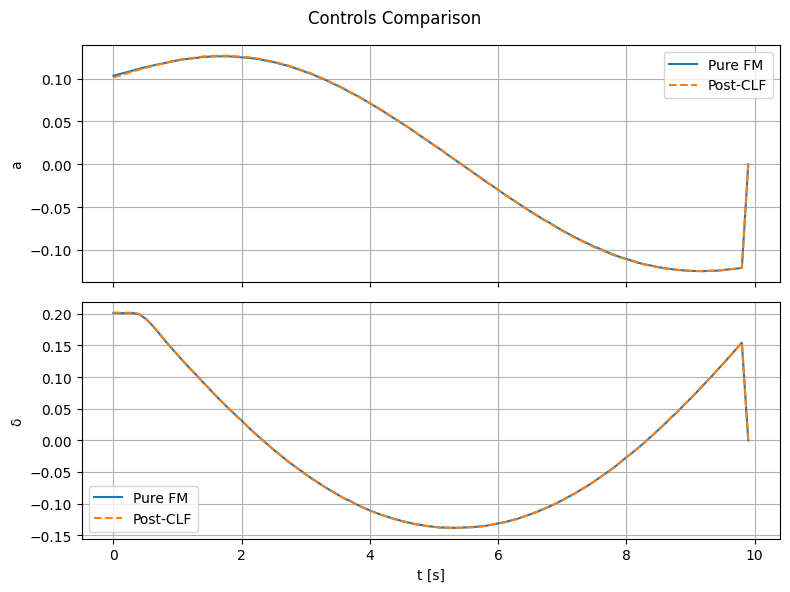

RMSE Pure FM:  0.0054 m
RMSE Post-CLF: 0.0019 m


In [ ]:
# === Cell: FM Sampling + Post‐CLF Correction (自适应 Dormand–Prince 5) ===

import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- 1. QP‐based CLF 校正 & 参数 ---
clf_params = {
    'a_max':      0.9,
    'delta_max':  0.9,
    'beta':     1e2,
    'lambda_reg':1e2,
    'mask':       0.0,
    'cap':      1e3,
    'dt':         0.1,
    't_frac':     1.0
}

def time_blow_up_function(t, T=1.0, cap=1e3):
    phi = 1.0 / (T - t + 1e-8)
    return min(phi, cap)

def correct_with_clf(states_phys, controls_phys, clf_params):
    N = states_phys.shape[0]
    a_max, d_max = clf_params['a_max'], clf_params['delta_max']
    λ_reg, β     = clf_params['lambda_reg'], clf_params['beta']
    cap, dt      = clf_params['cap'], clf_params['dt']
    phi  = time_blow_up_function(clf_params['t_frac'], cap=cap)
    w_s  = phi / (1.0 + phi)

    x0 = np.array([*states_phys[0], 0.0, 0.0], dtype=np.float32)
    u0 = np.zeros(N*2, dtype=np.float32)

    def obj(du_flat):
        du = du_flat.reshape(N,2)
        U  = controls_phys + du
        from __main__ import simulate_vehicle
        pred = simulate_vehicle(x0, U[:-1], dt=dt)[:,:3]
        err  = pred - states_phys
        return β*w_s*np.sum(err**2) + λ_reg*np.sum(du**2)

    bnds = []
    for k in range(N):
        a0,d0 = controls_phys[k]
        bnds += [(-a_max - a0, a_max - a0),
                 (-d_max - d0, d_max - d0)]

    res = minimize(obj, u0, method='SLSQP', bounds=bnds,
                   options={'ftol':1e-6, 'maxiter':200})
    du_opt = res.x.reshape(N,2).astype(np.float32)
    return controls_phys + du_opt

# --- 2. Scaler & 全轨迹 Min/Max ---
class Scaler:
    def __init__(self, data_min, data_max):
        self.min, self.max = data_min, data_max
    def normalize(self, x):
        return 2*(x - self.min)/(self.max - self.min) - 1
    def denormalize(self, x):
        return (x + 1)/2*(self.max - self.min) + self.min

all_data_5d = np.vstack([
    np.hstack([traj['states'][:, :3], traj['controls'][:100]])
    for traj in trajectories
])
dmin, dmax = all_data_5d.min(0), all_data_5d.max(0)
state_scaler = Scaler(dmin, dmax)

# --- 3. 纯 FM 分段采样（dopri5 自适应步长） ---
def piecewise_fm(x0_norm, upsampler, unet, downsampler, num_segments):
    device = x0_norm.device
    times  = torch.linspace(0,1,num_segments+1, device=device)
    state  = x0_norm.clone()

    def ode_func(t, x_flat):
        x   = x_flat.view(1,5,100)
        with torch.no_grad():
            img   = upsampler(x)
            vimg  = unet(t, img, torch.zeros(1, dtype=torch.long, device=device))
            vtraj = downsampler(vimg)
        return vtraj.view(-1)

    for i in range(num_segments):
        tspan = times[i:i+2]
        traj  = torchdiffeq.odeint(ode_func,
                                   state.view(-1),
                                   tspan,
                                   method='dopri5',
                                   atol=1e-5,
                                   rtol=1e-5)
        state = traj[-1].view(1,5,100)
    return state

# --- 4. 后校正（Post‐CLF）：一次性对整条轨迹做 CLF 校正 ---
def post_clf_correction(x_norm, state_scaler, clf_params):
    arr_norm = x_norm.cpu().numpy()[0].T        # (100,5)
    arr_phys = state_scaler.denormalize(arr_norm)  # (100,5)
    S = arr_phys[:,:3]; U = arr_phys[:,3:]
    U_corr = correct_with_clf(S, U, clf_params)     # (100,2)
    arr_phys[:,3:] = U_corr
    arr_norm_corr   = state_scaler.normalize(arr_phys)
    return arr_norm_corr[:,:3], arr_norm_corr[:,3:]

# --- 5. 运行 & 可视化 + RMSE 评估 ---
num_segments = 100
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x0_noise     = torch.randn(1,5,100, device=device)

# ① 纯 FM 采样
state_pure = piecewise_fm(x0_noise, upsampler, unet, downsampler, num_segments)

# ② 后校正
states_norm_corr, controls_norm_corr = post_clf_correction(
    state_pure, state_scaler, clf_params
)

# ③ 提取并反归一化控制
ctrl_pure = control_scaler.denormalize(state_pure.cpu().numpy()[0].T[:,3:])
ctrl_corr = control_scaler.denormalize(controls_norm_corr)

# ④ 绘图比较
t_axis = np.arange(100) * clf_params['dt']
fig,(ax1,ax2)=plt.subplots(2,1,sharex=True,figsize=(8,6))
ax1.plot(t_axis, ctrl_pure[:,0], label='Pure FM')
ax1.plot(t_axis, ctrl_corr[:,0],'--',label='Post-CLF')
ax1.set_ylabel('a'); ax1.legend(); ax1.grid()
ax2.plot(t_axis, ctrl_pure[:,1], label='Pure FM')
ax2.plot(t_axis, ctrl_corr[:,1],'--',label='Post-CLF')
ax2.set_ylabel('δ'); ax2.set_xlabel('t [s]'); ax2.legend(); ax2.grid()
plt.suptitle('Controls Comparison'); plt.tight_layout(); plt.show()

# ⑤ RMSE 计算
arr_phys_fm = state_scaler.denormalize(state_pure.cpu().numpy()[0].T)[:,:3]
sim_fm  = simulate_vehicle(np.concatenate([arr_phys_fm[0],[0,0]]),
                           ctrl_pure[:-1], dt=clf_params['dt'])
sim_corr= simulate_vehicle(np.concatenate([arr_phys_fm[0],[0,0]]),
                           ctrl_corr[:-1], dt=clf_params['dt'])
rmse = lambda A,B: np.sqrt(np.mean(np.sum((A[:,:2]-B[:,:2])**2,axis=1)))
print(f"RMSE Pure FM:  {rmse(arr_phys_fm, sim_fm):.4f} m")
print(f"RMSE Post-CLF: {rmse(arr_phys_fm, sim_corr):.4f} m")


In [59]:
# === Cell: Batch FM & Post‐CLF with Progress Print ===

import torch
import numpy as np

n_runs = 1000
results = {
    'states_fm': [],
    'states_sim_fm': [],
    'states_sim_post': [],
    'ctrl_fm': [],
    'ctrl_post': [],
    'rmse_fm': [],
    'rmse_post': []
}

for i in range(n_runs):
    # 1) 生成归一化噪声并做纯 FM 采样
    x0_noise = torch.randn(1,5,100, device=device)
    state_fm = piecewise_fm(x0_noise, upsampler, unet, downsampler, num_segments)
    arr_norm = state_fm.cpu().numpy()[0].T
    arr_phys = state_scaler.denormalize(arr_norm)
    states_fm = arr_phys[:,:3]
    ctrl_fm   = arr_phys[:,3:]

    # 2) 后校正
    _, controls_norm_corr = post_clf_correction(state_fm, state_scaler, clf_params)
    ctrl_post = control_scaler.denormalize(controls_norm_corr)

    # 3) 重模拟
    x0_phys = np.concatenate([states_fm[0], [0.0, 0.0]])
    sim_fm   = simulate_vehicle(x0_phys, ctrl_fm[:-1], dt)
    sim_post = simulate_vehicle(x0_phys, ctrl_post[:-1], dt)

    # 4) 计算 RMSE（位置误差）
    rmse = lambda A,B: np.sqrt(np.mean(np.sum((A[:,:2] - B[:,:2])**2, axis=1)))
    rmse_fm   = rmse(states_fm, sim_fm[:,:3])
    rmse_post = rmse(states_fm, sim_post[:,:3])

    # 5) 存储
    results['states_fm'].append(states_fm)
    results['states_sim_fm'].append(sim_fm[:,:3])
    results['states_sim_post'].append(sim_post[:,:3])
    results['ctrl_fm'].append(ctrl_fm)
    results['ctrl_post'].append(ctrl_post)
    results['rmse_fm'].append(rmse_fm)
    results['rmse_post'].append(rmse_post)

    # 每20条打印一次进度
    if (i+1) % 20 == 0:
        print(f"Processed {i+1}/{n_runs} trajectories")

# 转为 numpy 并保存
for k in results:
    results[k] = np.stack(results[k])
np.savez('fm_clf_batch_results.npz', **results)
print("All runs complete. Results saved to 'fm_clf_batch_results.npz'")


Processed 20/1000 trajectories
Processed 40/1000 trajectories
Processed 60/1000 trajectories
Processed 80/1000 trajectories
Processed 100/1000 trajectories
Processed 120/1000 trajectories
Processed 140/1000 trajectories
Processed 160/1000 trajectories
Processed 180/1000 trajectories
Processed 200/1000 trajectories
Processed 220/1000 trajectories
Processed 240/1000 trajectories
Processed 260/1000 trajectories
Processed 280/1000 trajectories
Processed 300/1000 trajectories
Processed 320/1000 trajectories
Processed 340/1000 trajectories
Processed 360/1000 trajectories
Processed 380/1000 trajectories
Processed 400/1000 trajectories
Processed 420/1000 trajectories
Processed 440/1000 trajectories
Processed 460/1000 trajectories
Processed 480/1000 trajectories
Processed 500/1000 trajectories
Processed 520/1000 trajectories
Processed 540/1000 trajectories
Processed 560/1000 trajectories
Processed 580/1000 trajectories
Processed 600/1000 trajectories
Processed 620/1000 trajectories
Processed 64

Pure FM RMSE statistics:
  Mean   : 0.0593
  Std    : 0.0607
  Median : 0.0414
  Q1 (25%): 0.0056
  Q3 (75%): 0.0956
  Min    : 0.0013
  Max    : 0.2964

CLF-FM RMSE statistics:
  Mean   : 0.0421
  Std    : 0.0421
  Median : 0.0307
  Q1 (25%): 0.0028
  Q3 (75%): 0.0706
  Min    : 0.0010
  Max    : 0.1906



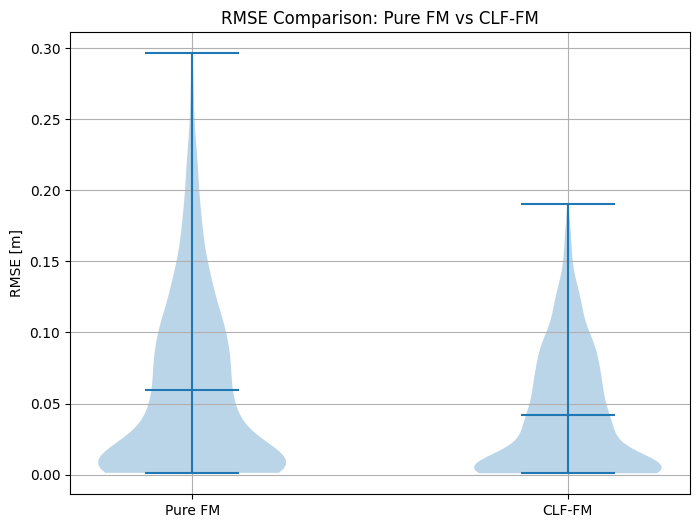

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 载入批量结果
data = np.load('fm_clf_batch_results.npz')
rmse_fm = data['rmse_fm']       # shape (n_runs,)
rmse_post = data['rmse_post']   # shape (n_runs,)

for label, arr in zip(['Pure FM', 'CLF-FM'], [rmse_fm, rmse_post]):
    print(f"{label} RMSE statistics:")
    print(f"  Mean   : {arr.mean():.4f}")
    print(f"  Std    : {arr.std():.4f}")                # <-- new line
    print(f"  Median : {np.median(arr):.4f}")
    print(f"  Q1 (25%): {np.percentile(arr, 25):.4f}")
    print(f"  Q3 (75%): {np.percentile(arr, 75):.4f}")
    print(f"  Min    : {arr.min():.4f}")
    print(f"  Max    : {arr.max():.4f}")
    print()

# 绘制小提琴图
plt.figure(figsize=(8, 6))
plt.violinplot([rmse_fm, rmse_post], showmeans=True)
plt.xticks([1, 2], ['Pure FM', 'CLF-FM'])
plt.ylabel('RMSE [m]')
plt.title('RMSE Comparison: Pure FM vs CLF-FM')
plt.grid(True)
plt.show()


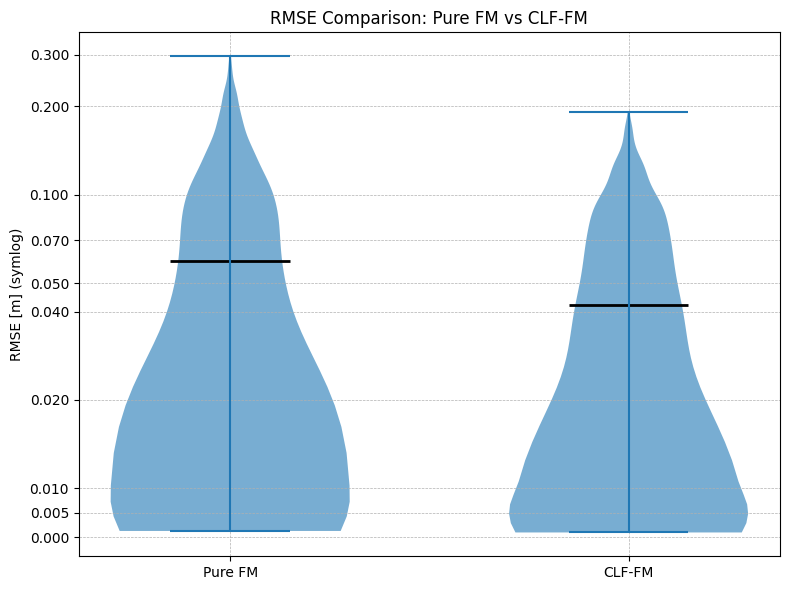

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Load results
data = np.load('fm_clf_batch_results.npz')
rmse_fm   = data['rmse_fm']
rmse_post = data['rmse_post']

fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot([rmse_fm, rmse_post], showmeans=True, widths=0.6)
for pc in parts['bodies']:
    pc.set_alpha(0.6)
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2)

# 对称对数刻度：压扁下半部分
# linthresh 控制线性区域大小，linscale<1 会把线性区域压扁
ax.set_yscale('symlog', linthresh=0.01, linscale=0.15)

# 只留关键刻度
ticks = [0.0, 0.005, 0.01, 0.02, 0.04, 0.05,0.07,0.1, 0.2, 0.3]
ax.set_yticks(ticks)
ax.set_yticklabels([f'{t:.3f}' for t in ticks])

ax.set_xticks([1, 2])
ax.set_xticklabels(['Pure FM', 'CLF-FM'])
ax.set_ylabel('RMSE [m] (symlog)')
ax.set_title('RMSE Comparison: Pure FM vs CLF-FM')
ax.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.show()



RMSE(Pure FM vs CBF-sim)     = 0.1173 m
RMSE(Pure FM vs CBF+CLF-theory) = 0.1360 m


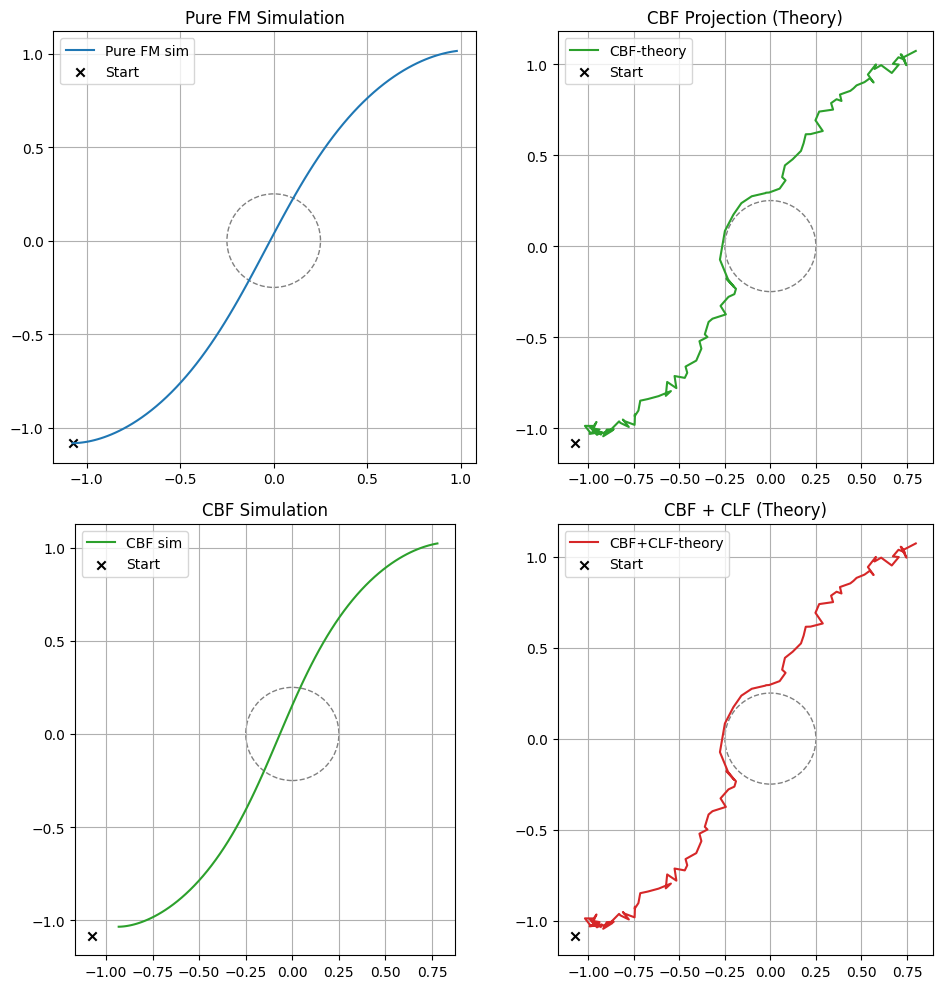

In [ ]:
# === Cell: 动态 CBF + 分段 CLF 联合投影（完整版） ===

import torch
import torchdiffeq
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. 超参 & 可调参数 ---
num_segments     = 20        # 分段数
mask_start_frac  = 0.9        # 从 t/T ≥ 0.8 开始才应用 CBF+CLF
cap_clf          = 1e-3       # CLF cap：设置为 0 则完全跳过 CLF

# --- 2. CLF 相关函数 & 参数 ---
clf_params = {
    'a_max':      0.9,
    'delta_max':  0.9,
    'beta':       1e2,
    'lambda_reg': 1e2,
    'cap':        cap_clf,
    'dt':         0.1,
    't_frac':     0.0  # 会在循环里更新
}

def time_blow_up_function(t, T=1.0, cap=1e5):
    return min(1.0/(T - t + 1e-8), cap)

def correct_with_clf(states_phys, controls_phys, clf_params):
    # 如果 cap=0，直接跳过
    if clf_params['cap'] <= 0:
        return controls_phys
    N = states_phys.shape[0]
    a_max, d_max = clf_params['a_max'], clf_params['delta_max']
    λ_reg, β     = clf_params['lambda_reg'], clf_params['beta']
    cap, dt      = clf_params['cap'], clf_params['dt']
    phi = time_blow_up_function(clf_params['t_frac'], cap=cap)
    w_s = phi / (1 + phi)

    # 初始物理状态（假设 v0=r0=0）
    x0 = np.array([*states_phys[0], 0.0, 0.0], dtype=np.float32)
    u0 = np.zeros(N*2, dtype=np.float32)

    def obj(du_flat):
        du = du_flat.reshape(N,2)
        U  = controls_phys + du
        pred = simulate_vehicle(x0, U[:-1], dt=dt)[:,:3]
        err  = pred - states_phys
        return β*w_s*np.sum(err**2) + λ_reg*np.sum(du**2)

    # bounds
    bnds = []
    for i in range(N):
        a0, d0 = controls_phys[i]
        bnds += [(-a_max - a0, a_max - a0),
                 (-d_max - d0, d_max - d0)]

    res = minimize(obj, u0, method='SLSQP', bounds=bnds,
                   options={'ftol':1e-6,'maxiter':200})
    du = res.x.reshape(N,2).astype(np.float32)
    return controls_phys + du

# --- 3. CBF 投影（保持不变） ---
# （请保证下面三个函数已经在命名空间里）
#     prescribed_time_cbf_projection_torch(...)
#     neighbor_distance_cbf_projection_torch(...)
#     apply_composite_cbf_projection_torch(...)

def apply_composite_cbf_projection_torch(
    state, t, T=1.0, r=0.25, cap=1e5,
    neighbor_cbf_ratio=0.05,
    neighbor_factor=1.5
):

    x_corrected = prescribed_time_cbf_projection_torch(state, t, T, r, cap)

    if t >= (1.0 - neighbor_cbf_ratio) * T:
        x_corrected = neighbor_distance_cbf_projection_torch(
            x_corrected, t, T, neighbor_factor, cap
        )
    return x_corrected

def neighbor_distance_cbf_projection_torch(x, t, T=1.0, neighbor_factor=1.5, cap=1e5):

    if x.size(1) < 2:
        return x
    
    phi = time_blow_up_function(t, T, cap)
    w = phi / (1 + phi)

    x_corrected = x.clone()
    distances = []
    for i in range(x_corrected.size(1) - 1):
        dist_i = torch.norm(x_corrected[:, i] - x_corrected[:, i+1])
        distances.append(dist_i.item())
    if len(distances) == 0:
        return x_corrected
    
    avg_dist = np.mean(distances)
    threshold = neighbor_factor * avg_dist 
    for i in range(x_corrected.size(1) - 1):
        xi = x_corrected[:, i]
        xip1 = x_corrected[:, i+1]
        dist_i = torch.norm(xi - xip1)
        if dist_i <= threshold:
            continue 
        H2_val = threshold - dist_i
        grad_dist_xi = (xi - xip1) / (dist_i + 1e-8)
        grad_norm_sq = torch.sum(grad_dist_xi ** 2) + 1e-8
        correction_xi = (H2_val / grad_norm_sq) * grad_dist_xi
        correction_xip1 = -correction_xi

        x_i_proj = xi + 0.5 * correction_xi
        x_ip1_proj = xip1 + 0.5 * correction_xip1

        x_corrected[:, i]   = (1 - w) * xi   + w * x_i_proj
        x_corrected[:, i+1] = (1 - w) * xip1 + w * x_ip1_proj
    
    return x_corrected

def prescribed_time_cbf_projection_torch(x, t, T=1.0, r=0.25, cap=1e5):

    phi = time_blow_up_function(t, T, cap)
    w = phi / (1 + phi)
    
    x_corrected = x.clone()
    for i in range(x_corrected.size(1)):
        xi = x_corrected[:, i]
        norm_xi = torch.norm(xi)
        if norm_xi >= r:
            continue 
        xi_var = xi.clone().detach().requires_grad_(True)
        H_val = torch.norm(xi_var) - r  
        grad_H = torch.autograd.grad(H_val, xi_var, create_graph=False)[0]
        grad_norm_sq = torch.sum(grad_H ** 2) + 1e-8 
        x_proj = xi_var - (H_val / grad_norm_sq) * grad_H
        xi_new = (1 - w) * xi + w * x_proj
        x_corrected[:, i] = xi_new.detach()
    return x_corrected
# --- 4. Scaler 定义 & 初始化（与你训练时保持一致） ---
class Scaler:
    def __init__(self, data_min, data_max):
        self.min, self.max = data_min, data_max
    def normalize(self, x):
        return 2*(x - self.min)/(self.max - self.min) - 1
    def denormalize(self, x):
        return (x + 1)/2*(self.max - self.min) + self.min

# 假设 trajectories 已经加载
all5 = np.vstack([
    np.hstack([traj['states'][:,:3], traj['controls'][:100]])
    for traj in trajectories
])
dmin, dmax = all5.min(0), all5.max(0)
state_scaler = Scaler(dmin, dmax)
control_scaler = Scaler(dmin[3:], dmax[3:])

# --- 5. 分段 CBF+CLF 联合采样函数 ---
def piecewise_cbf_clf(x0_norm, total_time=1.0):
    times = np.linspace(0, total_time, num_segments+1, dtype=np.float32)
    state = x0_norm.clone().to(device)  # (1,5,100)
    # 用于记录：每段的 CBF 投影后 state、每段的 CLF 校正后 controls
    cbf_states = []
    clf_controls = []

    for i in range(num_segments):
        t0, t1 = times[i], times[i+1]
        tfrac  = t1/total_time
        # 1) 一步 ODE 推进
        with torch.no_grad():
            traj = torchdiffeq.odeint(
                lambda t, x_flat: fm_ode_func(t, x_flat),
                state.view(-1),
                torch.tensor([t0, t1], device=device),
                method='dopri5'
            )
        seg = traj[-1].view(1,5,100)  # 归一化

        # 2) CBF 只作用于位置 (前 2 个通道)，且只在 tfrac>=mask_start_frac 时才开启
        if tfrac >= mask_start_frac:
            pos = seg[0,:2,:]  # (2,100)
            pos_corr = apply_composite_cbf_projection_torch(
                pos, t1, T=total_time, r=0.25, cap=1e5
            )
            seg = torch.cat([pos_corr.unsqueeze(0), seg[:,2:,:]], dim=1)
        cbf_states.append(seg.clone())  # 保存 CBF 投影后的归一化状态

        # 3) CLF 后处理：先取出位置+控制，反归一化
        arr = seg.cpu().numpy()[0].T   # (100,5)
        phys5 = state_scaler.denormalize(arr)
        S_phys, U_phys = phys5[:,:3], phys5[:,3:]
        # 更新 t_frac
        clf_params['t_frac'] = tfrac
        U_corr = correct_with_clf(S_phys, U_phys, clf_params)
        clf_controls.append(U_corr.copy())

        # 拼回 controls，重新归一化
        phys5[:,3:] = U_corr
        norm5 = state_scaler.normalize(phys5).astype(np.float32)
        state = torch.from_numpy(norm5.T).to(device).unsqueeze(0)

    return state, cbf_states, clf_controls

# ------------- 运行 -------------
# ① 纯 FM 采样
x0n = torch.randn((1,5,100), device=device)
with torch.no_grad():
    pure = torchdiffeq.odeint(
        lambda t,x: fm_ode_func(t,x),
        x0n.view(-1),
        torch.tensor([0.0,1.0], device=device),
        method='dopri5'
    )[-1].view(1,5,100)

# ② CBF+CLF 采样
state_f, cbf_states, clf_ctrls = piecewise_cbf_clf(x0n)

old_cap = clf_params['cap']
clf_params['cap'] = 10      
clf_params['t_frac'] = 1.0 
arr_norm = state_f.cpu().numpy()[0].T        # (100,5) 归一化后的 [x,y,θ,a,δ]
arr_phys = state_scaler.denormalize(arr_norm)  # (100,5) → 物理量
S_phys, U_phys = arr_phys[:,:3], arr_phys[:,3:]
# 把 t_frac 设为 1.0（轨迹结束）
U_corr_post = correct_with_clf(S_phys, U_phys, clf_params)  # (100,2)
arr_phys[:,3:] = U_corr_post
arr_norm_post = state_scaler.normalize(arr_phys).astype(np.float32)
state_f_postclf = torch.from_numpy(arr_norm_post.T).to(device).unsqueeze(0)

clf_params['cap'] = old_cap

state_f = state_f_postclf


# ------------- 提取三种轨迹的最终位置（更新）-------------
# 纯 FM
phys5_pure = state_scaler.denormalize(pure[0].cpu().numpy().T)  # (100,5)
ctrl_pure  = phys5_pure[:,3:]
traj_sim_pure = simulate_vehicle(
    np.hstack([phys5_pure[0,:3],[0,0]]),
    ctrl_pure[:-1], dt=0.1
)[:,:2]

# 只做 CBF 投影后理论位置：先反归一化
arr_norm_cbf = cbf_states[-1][0].cpu().numpy().T  # (100,5) 归一化状态
phys5_cbf_theory = state_scaler.denormalize(arr_norm_cbf)  # (100,5)
xy_cbf = phys5_cbf_theory[:,:2].T                    # (2,100)

# CBF-sim：在物理空间用 CBF-theory 的控制量重仿真
ctrl_cbf_theory = phys5_cbf_theory[:,3:]
traj_sim_cbf = simulate_vehicle(
    np.hstack([phys5_cbf_theory[0,:3],[0,0]]),
    ctrl_cbf_theory[:-1], dt=0.1
)[:,:2]

# CBF+CLF-theory：用联合投影最后一段直接给出的物理状态序列
# phys5_cbf_theory 已经拿到 CBF 投影后的物理位置和控制
#xy_cbfclf = phys5_cbf_theory[:,:2].T               # (2,100)
arr_norm_final = state_f.cpu().numpy()[0].T     # (100,5)
phys5_final    = state_scaler.denormalize(arr_norm_final)
xy_cbfclf      = phys5_final[:,:2].T            # (2,100)

def rmse(a, b):
    return np.sqrt(np.mean(np.sum((a - b)**2, axis=1)))

# 拿上面两条仿真轨迹和理论轨迹
# traj_sim_pure: (100,2) 纯 FM 仿真
# traj_sim_cbf : (100,2) 只 CBF 仿真
# xy_cbfclf.T  : (100,2) CBF+CLF 理论

rmse_pure_vs_cbf_sim = rmse(traj_sim_pure, traj_sim_cbf)
rmse_pure_vs_cbfclf = rmse(traj_sim_pure, xy_cbfclf.T)

print(f"RMSE(Pure FM vs CBF-sim)     = {rmse_pure_vs_cbf_sim:.4f} m")
print(f"RMSE(Pure FM vs CBF+CLF-theory) = {rmse_pure_vs_cbfclf:.4f} m")





# ------------- 绘图（4 张子图）-------------
r = 0.25  # 障碍物半径

fig, axs = plt.subplots(2, 2, figsize=(10,10))

# 1. Pure FM sim
ax = axs[0,0]
ax.plot(traj_sim_pure[:,0], traj_sim_pure[:,1], 'C0-', label='Pure FM sim')
ax.scatter(*phys5_pure[0,:2], c='k', marker='x', label='Start')
ax.add_patch(plt.Circle((0,0), r, fill=False, linestyle='--', color='gray'))
ax.set_title("Pure FM Simulation")
ax.set_aspect('equal'); ax.grid(True); ax.legend()

# 2. CBF Projection (Theory)
ax = axs[0,1]
ax.plot(xy_cbf[0], xy_cbf[1], 'C2-', label='CBF-theory')
ax.scatter(*phys5_pure[0,:2], c='k', marker='x', label='Start')
ax.add_patch(plt.Circle((0,0), r, fill=False, linestyle='--', color='gray'))
ax.set_title("CBF Projection (Theory)")
ax.set_aspect('equal'); ax.grid(True); ax.legend()

# 3. CBF Simulation
ax = axs[1,0]
ax.plot(traj_sim_cbf[:,0], traj_sim_cbf[:,1], 'C2-', label='CBF sim')
ax.scatter(*phys5_pure[0,:2], c='k', marker='x', label='Start')
ax.add_patch(plt.Circle((0,0), r, fill=False, linestyle='--', color='gray'))
ax.set_title("CBF Simulation")
ax.set_aspect('equal'); ax.grid(True); ax.legend()

# 4. CBF + CLF (Theory)
ax = axs[1,1]
ax.plot(xy_cbfclf[0], xy_cbfclf[1], 'C3-', label='CBF+CLF-theory')
ax.scatter(*phys5_pure[0,:2], c='k', marker='x', label='Start')
ax.add_patch(plt.Circle((0,0), r, fill=False, linestyle='--', color='gray'))
ax.set_title("CBF + CLF (Theory)")
ax.set_aspect('equal'); ax.grid(True); ax.legend()

plt.tight_layout()
plt.show()

